<div dir="rtl" lang="he" style="text-align: right;">

# האם מרחב לטנטי גנרטיבי או קונטרסטיבי מפיץ תוויות טוב יותר?

**סיווג חצי-מונחה על STL-10.**  
תומר קרמזין וליאור רזניק — מכללת אפקה, *שיטות מתקדמות בלמידת מכונה*.

---

## שאלת המחקר

STL-10 מספק לנו 100,000 תמונות ללא תוויות ורק 1,000 תמונות מתויגות בכל fold. מטרתנו היא לבדוק איזה סוג של ייצוג הנלמד באופן עצמי מאפשר להפיק את המרב ממספר התוויות המצומצם. לכן קיבענו את כל שאר התנאים ושינינו רק את מטרת קדם-האימון:

| | הזרוע הגנרטיבית | הזרוע הקונטרסטיבית |
|---|---|---|
| מטרה | β-VAE ‏(evidence lower bound) | SimCLR ‏(NT-Xent) |
| מקודד | SE-ResNet, ‏13.4 מיליון פרמטרים | אותו SE-ResNet |
| ייצוג | `mu`, ממד 512 | מאפיינים לאחר pooling, ממד 512 |
| שלב המשך | גרף KNN → העברת תוויות → CNN, **ובנוסף probe לינארי** | probe לינארי |

שורות ה-probe הלינארי הן ההשוואה המרכזית. שורת ה-CNN עונה על שאלה צרה יותר ומדווחת לצדן, ולא במקומן.

## שני כללים שעיצבו את כל מה שמופיע בהמשך

**מימוש מאפס — עבור השיטה הנחקרת.** לא השתמשנו ב-SciPy, ב-FAISS, ב-NetworkX, ב-`torchvision.models` או ב-`torchvision.transforms`. גרף ה-KNN, העברת התוויות, union-find, כל המדדים, ה-SE-ResNet ושני צינורות האוגמנטציה ממומשים במחברת זו ב-PyTorch וב-NumPy. סעיף 14 מאמת כל אחד מהם מול מימוש הייחוס שאותו הוא מחליף.

ה-**probe להערכה** הוא החריג המכוון היחיד. גם הוא ממומש כאן מאפס, אך אנו מריצים בנוסף את `LogisticRegression` של scikit-learn על שתי הזרועות, ובסעיף 12 מציגים את שתי התוצאות זו לצד זו. אומד המשמש בשלב ההמשך אינו חלק מהשיטה הנחקרת, ולכן חשוב יותר להראות שהמסקנה אינה תלויה במימוש הרגרסיה הלוגיסטית מאשר להימנע מהספרייה.

**את חלוקת ה-test פותחים פעם אחת בלבד.** כל hyperparameter נבחר על חלוקת development מוחזקת בצד, לרבות ה-checkpoint שנשמר בכל זרוע. שתי הזרועות נבדקות באותם שישה epochs, באמצעות אותו probe, וכל אחת שומרת את ה-checkpoint שה-probe העדיף. הבחירה נשמרת בדיסק ונחתמת ב-hash לפני שסעיף 12 קורא את חלוקת ה-test בפעם הראשונה והיחידה.

## כיצד מריצים את המחברת

התאים מסודרים מלמעלה למטה, וכל שלב כבד שומר את הפלט שלו תחת `runs/`. לכן הרצה נוספת טוענת את התוצאות בתוך דקות. כדי להתעלם מה-cache יש להגדיר `FORCE_RETRAIN = True` בסעיף 0.

הרצה קרה מאמנת שנים-עשר מקודדים — ארבע מדיניות SimCLR ושמונה ערכי β — במשך 100 epochs כל אחד. בכל אימון עוצרים שש פעמים, ב-epochs ‏50 עד 100, כדי להתאים את ה-probe על חלוקת ה-development. שנים-עשר אימוני הקדם נמשכים בערך יומיים על RTX 5090 יחיד, ונוספות להם שבעים ושתיים הרצות probe.

יחידת ה-cache היא מקודד יחיד. לכן אם ההרצה נקטעת, היא מתחדשת מהמקודד שבו נעצרה ולא מאמצע האימון שלו.

</div>

<div dir="rtl" lang="he" style="text-align: right;">

## תוכן העניינים

| § | שלב | עלות בהרצה קרה |
|---|---|---|
| 0 | הגדרות, seed, בדיקות דיסק והתקן | שניות |
| 1 | STL-10 ללא torchvision: קריאה, folds, חלוקות ונרמול | כ-2 דקות |
| 2 | גזע ה-SE-ResNet המשותף | שניות |
| 3 | אוגמנטציה במימוש עצמי: מדיניות VAE מתונה וארבע מדיניות SimCLR | שניות |
| 4 | optimizer ולוח קצב הלמידה | שניות |
| 5 | הזרוע הקונטרסטיבית: projection head, ‏NT-Xent וארבעה אימוני קדם של 100 epochs | 20–30 שעות |
| 6 | הזרוע הגנרטיבית: decoder, ‏β-VAE ושמונה אימוני קדם של 100 epochs | 12–16 שעות |
| 7 | ייצוגים מוקפאים | כ-20 דקות |
| 8 | גרף KNN בחלוקה ל-chunks | כ-30 דקות |
| 9 | העברת תוויות: קיבוע קשיח, label spreading ומדוע הראשון נכשל | כשעה |
| 10 | ה-probe הלינארי | כ-15 דקות |
| 11 | בחירת K, ‏α, ‏β, ‏C ומדיניות האוגמנטציה | כ-3 שעות |
| 12 | benchmark על ה-test — החלוקה נקראת כאן פעם אחת | כ-30 דקות |
| 13 | תוצאות, תרשימים ובדיקת הוגנות | כ-5 דקות |
| 14 | אימות הרכיבים שמומשו מאפס | כ-2 דקות |

</div>


<div dir="rtl" lang="he" style="text-align: right;">

---

# 0. הגדרות

כל מה ששתי הזרועות חייבות לחלוק מוגדר פעם אחת כאן ומשמש את כל השלבים בהמשך. הגדרה חוזרת של קבוע בכל שלב היא דרך קלה לגרום לשתי הזרועות להפסיק להיות בנות-השוואה בלי לשים לב.

הערכים המסומנים כ-*reference* נלקחו ממחברת ה-SimCLR המקורית (`reference/simclr_stl10_abilation_f.ipynb`), ואין לשנות אותם רק בצד אחד.

</div>


In [1]:
import hashlib
import json
import math
import os
import random
import shutil
import time
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

SEED = 42

IMAGE_SIZE = 96
NUM_CLASSES = 10
NUM_UNLABELED_IMAGES = 100_000
NUM_TRAIN_IMAGES = 5_000
NUM_TEST_IMAGES = 8_000

NUM_GRAPH_NODES = NUM_UNLABELED_IMAGES + NUM_TRAIN_IMAGES

BATCH_SIZE = 256
FEATURE_BATCH_SIZE = 512
EPOCHS = 100
WARMUP_EPOCHS = 10
MAX_LEARNING_RATE = 5e-4
MIN_LEARNING_RATE = 1e-5
WEIGHT_DECAY = 1e-4

STEM_WIDTH = 48
STAGE_DEPTHS = (2, 3, 4, 3)
STAGE_WIDTHS = (64, 128, 256, 384)
ENCODER_DIM = 512
SE_REDUCTION = 16

PROJECTOR_HIDDEN_DIM = 512
PROJECTOR_OUTPUT_DIM = 128
TEMPERATURE = 0.20

LATENT_DIM = ENCODER_DIM
BETA_WARMUP_EPOCHS = 10

BETA_GRID = (0.0, 0.001, 0.003, 0.01, 0.03, 0.1, 0.3, 1.0)

K_GRID = (5, 10, 15, 20, 30, 50)
LP_ALPHA_GRID = (0.50, 0.80, 0.90, 0.95, 0.99)
LP_MAX_ITERATIONS = 3000
LP_TOLERANCE = 1e-6

SIMILARITY_CHUNK_ROWS = 1024

LINEAR_C_GRID = (0.1, 1.0, 10.0, 100.0)
CROSS_VALIDATION_SPLITS = 5
LINEAR_MAX_ITERATIONS = 5000
LINEAR_TOLERANCE = 1e-4

NUM_FOLDS = 10
FOLD_SIZE = 1000
VALIDATION_FRACTION = 0.20

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "data").exists() and (PROJECT_ROOT.parent / "data").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_ROOT = PROJECT_ROOT / "data"
RUNS_ROOT = PROJECT_ROOT / "runs"
RESULTS_ROOT = PROJECT_ROOT / "results"
FIGURES_ROOT = RESULTS_ROOT / "figures"

for folder in (RUNS_ROOT, RESULTS_ROOT, FIGURES_ROOT):
    folder.mkdir(parents=True, exist_ok=True)

FORCE_RETRAIN = False

print("project root :", PROJECT_ROOT)
print("data         :", DATA_ROOT)
print("runs         :", RUNS_ROOT)
print("seed         :", SEED)
print("beta grid    :", BETA_GRID)
print("K grid       :", K_GRID)
print("alpha grid   :", LP_ALPHA_GRID)

project root : /home/labadmin/lab/Tomer_Karmazin/stl10-ssl-comparison
data         : /home/labadmin/lab/Tomer_Karmazin/stl10-ssl-comparison/data
runs         : /home/labadmin/lab/Tomer_Karmazin/stl10-ssl-comparison/runs
seed         : 42
beta grid    : (0.0, 0.001, 0.003, 0.01, 0.03, 0.1, 0.3, 1.0)
K grid       : (5, 10, 15, 20, 30, 50)
alpha grid   : (0.5, 0.8, 0.9, 0.95, 0.99)


<div dir="rtl" lang="he" style="text-align: right;">

## 0.1 קביעת seed

שתי הזרועות מקבלות seed זהה ושתיהן משתמשות בגרעיני CUDA דטרמיניסטיים. אילו רק זרוע אחת הייתה דטרמיניסטית, חלק מהפער ביניהן היה עשוי לנבוע מאי-דטרמיניזם של הגרעינים ולא מפונקציית המטרה, ולא ניתן היה להפריך את ההשוואה.

`use_deterministic_algorithms(True)` גורם ל-PyTorch להעלות שגיאה במקום להחליף בשקט לגרעין לא דטרמיניסטי. כך רגרסיה נכשלת באופן גלוי במקום לזהם את התוצאות בלי שנבחין בכך. יש להגדיר את `CUBLAS_WORKSPACE_CONFIG` לפני יצירת הקשר CUDA, ולכן הוא מופיע כאן ולא בהמשך.

</div>


In [2]:
def reset_seed(seed=SEED):
    """Reseed every random source the pipeline touches."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


def seeded_generator(seed=SEED):
    """A CPU generator for anything that accepts one explicitly."""
    generator = torch.Generator()
    generator.manual_seed(seed)
    return generator


def enable_deterministic():
    os.environ.setdefault("CUBLAS_WORKSPACE_CONFIG", ":4096:8")
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True
    torch.use_deterministic_algorithms(True)
    torch.backends.cuda.matmul.allow_tf32 = False
    torch.backends.cudnn.allow_tf32 = False


enable_deterministic()
reset_seed()

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device       :", DEVICE)
if DEVICE.type == "cuda":
    print("gpu          :", torch.cuda.get_device_name(0))
    print("vram         : %.1f GB" % (torch.cuda.get_device_properties(0).total_memory / 1e9))
print("torch        :", torch.__version__)
print("deterministic: on")

device       : cuda
gpu          : NVIDIA GeForce RTX 5090
vram         : 33.7 GB
torch        : 2.11.0+cu128
deterministic: on


<div dir="rtl" lang="he" style="text-align: right;">

## 0.2 שמירה ב-cache והגנת הדיסק

כל שלב כבד שומר את התוצר שלו תחת `runs/` וטוען אותו בהרצה מאוחרת יותר. יש לכך שתי סיבות מעשיות:

1. הרצה קרה של המחברת נמשכת בערך יומיים. ללא checkpoints, ניתוק kernel בשעה השלושים מבטל את כל העבודה שנעשתה.
2. סריקות ה-hyperparameters בסעיף 11 קוראות מערך ייצוגים שמור במקום לקודד מחדש 105,000 תמונות בכל תא — הבדל של דקות לעומת שעות.

מפתח cache מתאר את הקוד שיצר את התוצר. כאשר השתנו המעבר הקדמי הקונטרסטיבי, האוגמנטציות ודיוק הייצוגים, השתנו גם המפתחות. לכן המחברת אינה יכולה לטעון בשקט מערך שנוצר בידי הקוד שהוחלף.

לאחר ההרצה נשארים בדיסק שנים-עשר מערכי ייצוגים בגודל 105,000 × 512 ובדיוק float32, כ-215 MB לכל אחד, ושני מצבי מקודד לכל קדם-אימון: ה-checkpoint שנבחר והמצב הסופי. הגנת הדיסק אינה קישוט. לשרת המעבדה יש אמצעי אחסון יחיד המשותף לפרויקטים נוספים וללא מכסות; הרצה שממלאת את מערכת הקבצים הראשית משביתה את השרת לכולם. לכן כל שלב שכותב לדיסק קורא תחילה ל-`require_disk`.

</div>


In [3]:
MINIMUM_FREE_GIGABYTES = 12.0


def free_gigabytes(path=None):
    """Free space on the volume holding `path`, in GB."""
    target = Path(path) if path is not None else PROJECT_ROOT
    while not target.exists():
        target = target.parent
    return shutil.disk_usage(target).free / (1024 ** 3)


def require_disk(minimum=MINIMUM_FREE_GIGABYTES, what="this stage"):
    """Abort before writing if the volume is close to full."""
    available = free_gigabytes()
    if available < minimum:
        raise RuntimeError(
            "Only %.1f GB free; %s needs at least %.1f GB. Free space before continuing -- "
            "a run that fills the root filesystem takes down the whole machine."
            % (available, what, minimum)
        )
    return available


def cached(path, build, description=None, force=None):
    """Return the artifact at `path`, building and saving it when it is missing."""
    path = Path(path)
    should_force = FORCE_RETRAIN if force is None else force
    label = description or path.name

    if path.exists() and not should_force:
        print("[cache hit ] %s" % label)
        return torch.load(path, map_location="cpu", weights_only=False)

    require_disk(what=label)
    print("[building  ] %s" % label)
    started = time.time()
    artifact = build()
    path.parent.mkdir(parents=True, exist_ok=True)
    torch.save(artifact, path)
    print("[done      ] %s in %s" % (label, format_duration(time.time() - started)))
    return artifact


def format_duration(seconds):
    seconds = int(seconds)
    if seconds < 60:
        return "%ds" % seconds
    if seconds < 3600:
        return "%dm %02ds" % (seconds // 60, seconds % 60)
    return "%dh %02dm" % (seconds // 3600, (seconds % 3600) // 60)


print("free disk    : %.1f GB" % free_gigabytes())
require_disk(what="the full notebook")
print("disk guard   : ok")

free disk    : 36.6 GB
disk guard   : ok


<div dir="rtl" lang="he" style="text-align: right;">

---

# 1. STL-10 ללא torchvision

השימוש ב-`torchvision.datasets.STL10` אינו מותר, ולכן אנו קוראים ישירות את `stl10_binary/` באמצעות `numpy.fromfile`. זו גם האפשרות הזולה יותר בשרת שבו נפח הדיסק הוא המגבלה: קריאה של שבעה קבצים אינה מצדיקה התקנה של כל חבילת torchvision.

מערך הנתונים כולל שלוש חלוקות וקובץ נוסף שחשיבותו גדולה מכפי שנראה בתחילה:

| קובץ | תוכן |
|---|---|
| `unlabeled_X.bin` | 100,000 תמונות, 2.76 GB כ-uint8. **החלוקה רחבה בכוונה מעשר המחלקות המתויגות** |
| `train_X.bin` / `train_y.bin` | 5,000 תמונות מתויגות |
| `test_X.bin` / `test_y.bin` | 8,000 תמונות מתויגות |
| `fold_indices.txt` | **10 folds רשמיים**, בכל אחד 1,000 אינדקסים מתוך חלוקת ה-train המתויגת |

ה-folds הם פרוטוקול ההערכה. השימוש בהם, במקום בתתי-קבוצות אקראיות משלנו, מאפשר להשוות את המספרים זה לזה ולתוצאות שפורסמו בספרות על STL-10.

</div>


<div dir="rtl" lang="he" style="text-align: right;">

### פעולת ה-transpose אינה אופציונלית

STL-10 שומר כל תמונה בסדר **column-major** בתוך זרם בתים בסדר row-major. לכן שינוי הצורה ל-`[N, 3, 96, 96]` מציב את הפיקסלים בסדר `[N, C, W, H]`, ולא בסדר `[N, C, H, W]`.

אם משמיטים את החלפת הצירים, כל תמונה מתקבלת משוחלפת. לא מתקבלת שגיאה: ה-VAE מתאמן, הגרף נבנה, ההעברה מתכנסת וכל מספר בדוח שגוי בשקט. סעיף 1.5 מציג רשת תמונות לדוגמה במיוחד כדי שניתן יהיה לראות זאת ולא רק להניח שהקריאה נכונה.

</div>


In [4]:
NUMBER_OF_CHANNELS = 3
EXPECTED_SPLIT_SIZES = {"train": 5000, "test": 8000, "unlabeled": 100000}
SPLIT_FILE_NAMES = {
    "train": ("train_X.bin", "train_y.bin"),
    "test": ("test_X.bin", "test_y.bin"),
    "unlabeled": ("unlabeled_X.bin", None),
}


def resolve_binary_directory(data_root):
    """Accept either the parent directory or the extracted archive itself."""
    nested = Path(data_root) / "stl10_binary"
    return nested if nested.is_dir() else Path(data_root)


def load_images(path):
    """Read one image binary into uint8 [N, 3, 96, 96]."""
    raw = np.fromfile(path, dtype=np.uint8)
    images = raw.reshape(-1, NUMBER_OF_CHANNELS, IMAGE_SIZE, IMAGE_SIZE)
    return np.transpose(images, (0, 1, 3, 2))


def load_images_memory_mapped(path):
    """Lazy view of an image binary, for the 2.76 GB unlabeled split."""
    raw = np.memmap(path, dtype=np.uint8, mode="r")
    images = raw.reshape(-1, NUMBER_OF_CHANNELS, IMAGE_SIZE, IMAGE_SIZE)
    return np.transpose(images, (0, 1, 3, 2))


def load_labels(path):
    """Read one label binary into int64 [N] with values 0..9."""
    return np.fromfile(path, dtype=np.uint8).astype(np.int64) - 1


def load_split(data_root, split, memory_map_unlabeled=True):
    """Load one STL-10 split as (images uint8 [N,3,96,96], labels int64 [N] or None)."""
    if split not in SPLIT_FILE_NAMES:
        raise ValueError("split must be one of %s, got %r" % (sorted(SPLIT_FILE_NAMES), split))

    binary_directory = resolve_binary_directory(data_root)
    image_file_name, label_file_name = SPLIT_FILE_NAMES[split]
    image_path = binary_directory / image_file_name

    if not image_path.is_file():
        raise FileNotFoundError(
            "Could not find %s. Expected the extracted stl10_binary/ archive under %r."
            % (image_path, str(data_root))
        )

    if split == "unlabeled" and memory_map_unlabeled:
        images = load_images_memory_mapped(image_path)
    else:
        images = load_images(image_path)

    expected = EXPECTED_SPLIT_SIZES[split]
    if len(images) != expected:
        raise ValueError(
            "Split %r should hold %d images but %s decoded to %d. A truncated download is "
            "the usual cause." % (split, expected, image_path, len(images))
        )

    if label_file_name is None:
        return images, None

    labels = load_labels(binary_directory / label_file_name)
    if len(labels) != len(images):
        raise ValueError("Image/label count mismatch for %r: %d vs %d"
                         % (split, len(images), len(labels)))
    return images, labels


def load_class_names(data_root):
    path = resolve_binary_directory(data_root) / "class_names.txt"
    with io_open(path) as handle:
        return [line.strip() for line in handle if line.strip()]


def io_open(path):
    return open(path, "r", encoding="utf-8")


train_images, train_labels = load_split(DATA_ROOT, "train")
test_images, test_labels = load_split(DATA_ROOT, "test")
unlabeled_images, _ = load_split(DATA_ROOT, "unlabeled", memory_map_unlabeled=True)
CLASS_NAMES = load_class_names(DATA_ROOT)

print("train      :", train_images.shape, train_images.dtype, "labels", train_labels.shape)
print("test       :", test_images.shape, test_images.dtype, "labels", test_labels.shape)
print("unlabeled  :", unlabeled_images.shape, unlabeled_images.dtype, "(memory-mapped)")
print("classes    :", CLASS_NAMES)
print()
print("train class counts:", np.bincount(train_labels, minlength=NUM_CLASSES).tolist())
print("test  class counts:", np.bincount(test_labels, minlength=NUM_CLASSES).tolist())
print("unlabeled bytes   : %.2f GB" % (unlabeled_images.size / 1e9))

train      : (5000, 3, 96, 96) uint8 labels (5000,)
test       : (8000, 3, 96, 96) uint8 labels (8000,)
unlabeled  : (100000, 3, 96, 96) uint8 (memory-mapped)
classes    : ['airplane', 'bird', 'car', 'cat', 'deer', 'dog', 'horse', 'monkey', 'ship', 'truck']

train class counts: [500, 500, 500, 500, 500, 500, 500, 500, 500, 500]
test  class counts: [800, 800, 800, 800, 800, 800, 800, 800, 800, 800]
unlabeled bytes   : 2.76 GB


<div dir="rtl" lang="he" style="text-align: right;">

## 1.2 קבועי הנרמול

הקבועים מחושבים **רק מחלוקת ה-unlabeled**. שימוש בתמונות ה-train המתויגות או בתמונות ה-test היה מדליף מידע מנתוני ההערכה אל שלב העיבוד המקדים.

הצבירה מתבצעת ב-float64 וב-chunks משתי סיבות קונקרטיות: סכום הריבועים על פני 100,000 × 96 × 96 × 3 פיקסלים גולש מ-float32 הרבה לפני סיום החישוב, ואילו המרה של כל המערך בנפח 2.76 GB ל-float64 בבת אחת הייתה דורשת 22 GB.

</div>


In [5]:
def compute_channel_statistics(images, chunk_size=512):
    """Per-RGB-channel mean and standard deviation, in [0, 1] units."""
    channel_sum = np.zeros(NUMBER_OF_CHANNELS, dtype=np.float64)
    channel_square_sum = np.zeros(NUMBER_OF_CHANNELS, dtype=np.float64)
    pixel_count = 0

    for start in range(0, len(images), chunk_size):
        chunk = np.asarray(images[start:start + chunk_size]).astype(np.float64, copy=True)
        channel_sum += chunk.sum(axis=(0, 2, 3))
        channel_square_sum += np.einsum("nchw,nchw->c", chunk, chunk, optimize=True)
        pixel_count += chunk.shape[0] * chunk.shape[2] * chunk.shape[3]

    mean = channel_sum / pixel_count / 255.0
    second_moment = channel_square_sum / pixel_count / (255.0 ** 2)
    variance = np.maximum(second_moment - np.square(mean), 0.0)
    return mean.tolist(), np.sqrt(variance).tolist()


def _build_normalization():
    mean, std = compute_channel_statistics(unlabeled_images, chunk_size=5000)
    return {"mean": mean, "std": std, "source_split": "unlabeled"}


NORMALIZATION = cached(
    RUNS_ROOT / "normalization.pt", _build_normalization, "normalization constants")

NORMALIZATION_MEAN = NORMALIZATION["mean"]
NORMALIZATION_STD = NORMALIZATION["std"]

print("channel mean:", ["%.8f" % v for v in NORMALIZATION_MEAN])
print("channel std :", ["%.8f" % v for v in NORMALIZATION_STD])
print("source      :", NORMALIZATION["source_split"], "split only")

[cache hit ] normalization constants
channel mean: ['0.44058639', '0.42731114', '0.38579501']
channel std : ['0.26865456', '0.26125219', '0.26849921']
source      : unlabeled split only


In [6]:
def normalize_batch(images_uint8, mean=None, standard_deviation=None, device=None):
    """uint8 [B, 3, 96, 96] -> normalized float32 on `device`."""
    mean = NORMALIZATION_MEAN if mean is None else mean
    standard_deviation = NORMALIZATION_STD if standard_deviation is None else standard_deviation
    device = DEVICE if device is None else device

    if isinstance(images_uint8, torch.Tensor):
        source = images_uint8.to(device)
    else:
        source = torch.from_numpy(np.ascontiguousarray(images_uint8)).to(device)

    images = source.to(torch.float32)
    if images.data_ptr() == source.data_ptr():
        images = images.clone()

    images = images.div_(255.0)
    mean_tensor = torch.as_tensor(mean, dtype=torch.float32, device=device).view(1, -1, 1, 1)
    std_tensor = torch.as_tensor(
        standard_deviation, dtype=torch.float32, device=device).view(1, -1, 1, 1)
    return images.sub_(mean_tensor).div_(std_tensor)


def denormalize_for_display(batch):
    """Undo `normalize_batch` so a tensor can be shown as an image."""
    mean = torch.as_tensor(NORMALIZATION_MEAN, dtype=torch.float32).view(1, -1, 1, 1)
    std = torch.as_tensor(NORMALIZATION_STD, dtype=torch.float32).view(1, -1, 1, 1)
    return (batch.detach().cpu() * std + mean).clamp(0.0, 1.0)


probe_batch = normalize_batch(train_images[:8])
print("normalized batch:", tuple(probe_batch.shape), probe_batch.dtype, probe_batch.device)
print("value range     : [%.3f, %.3f]" % (probe_batch.min().item(), probe_batch.max().item()))


normalized batch: (8, 3, 96, 96) torch.float32 cuda:0
value range     : [-1.640, 2.288]


<div dir="rtl" lang="he" style="text-align: right;">

## 1.3 ה-folds וחלוקת ה-development

בחירת המודל מתבצעת בתוך כל fold על חלוקה משוכבת של 800/200, עם seed ‏`SEED + fold_index`. מאתיים התמונות המוחזקות בצד הן הנתונים היחידים שעליהם מדורג hyperparameter כלשהו. חלוקת ה-test אינה משתתפת עד סעיף 12.

`stratified_split` מחליפה את `sklearn.model_selection.train_test_split(..., stratify=...)`. האלגוריתם פשוט: מערבבים בנפרד את המיקומים של כל מחלקה וחותכים באותו יחס. חיתוך בתוך כל מחלקה הוא כל המשמעות של חלוקה "משוכבת" בהקשר זה.

</div>


In [7]:
def load_official_folds(data_root):
    """Parse fold_indices.txt into int64 [10, 1000]."""
    path = resolve_binary_directory(data_root) / "fold_indices.txt"
    with io_open(path) as handle:
        text = handle.read()

    folds = np.stack([
        np.array(line.split(), dtype=np.int64)
        for line in text.strip().splitlines() if line.strip()
    ])
    if folds.shape != (NUM_FOLDS, FOLD_SIZE):
        raise ValueError("fold_indices.txt should parse to [10, 1000], got %r" % (folds.shape,))
    return folds


def stratified_split(labels, validation_fraction, seed):
    """Hand-rolled stratified train/validation split of `labels`' positions."""
    labels = np.asarray(labels)
    if not 0.0 < validation_fraction < 1.0:
        raise ValueError("validation_fraction must be in (0, 1), got %r" % (validation_fraction,))

    generator = np.random.default_rng(seed)
    train_positions, validation_positions = [], []

    for class_id in np.unique(labels):
        class_positions = np.flatnonzero(labels == class_id)
        shuffled = generator.permutation(class_positions)
        validation_size = int(round(len(shuffled) * validation_fraction))
        validation_size = max(1, min(len(shuffled) - 1, validation_size))
        validation_positions.append(shuffled[:validation_size])
        train_positions.append(shuffled[validation_size:])

    return (np.sort(np.concatenate(train_positions)).astype(np.int64),
            np.sort(np.concatenate(validation_positions)).astype(np.int64))


OFFICIAL_FOLDS = load_official_folds(DATA_ROOT)

DEVELOPMENT_SPLITS = {}
for fold_index in range(NUM_FOLDS):
    fold_labels = train_labels[OFFICIAL_FOLDS[fold_index]]
    DEVELOPMENT_SPLITS[fold_index] = stratified_split(
        fold_labels, VALIDATION_FRACTION, SEED + fold_index)

print("official folds:", OFFICIAL_FOLDS.shape)
print()
print("fold   train  val   per-class counts in the 200 held-out images")
for fold_index in range(NUM_FOLDS):
    train_positions, validation_positions = DEVELOPMENT_SPLITS[fold_index]
    validation_labels = train_labels[OFFICIAL_FOLDS[fold_index]][validation_positions]
    counts = np.bincount(validation_labels, minlength=NUM_CLASSES)
    print("%4d %6d %5d   %s" % (
        fold_index, len(train_positions), len(validation_positions), counts.tolist()))


official folds: (10, 1000)

fold   train  val   per-class counts in the 200 held-out images
   0    800   200   [20, 20, 20, 20, 20, 20, 20, 20, 20, 20]
   1    800   200   [20, 20, 20, 20, 20, 20, 20, 20, 20, 20]
   2    800   200   [20, 20, 20, 20, 20, 20, 20, 20, 20, 20]
   3    800   200   [20, 20, 20, 20, 20, 20, 20, 20, 20, 20]
   4    800   200   [20, 20, 20, 20, 20, 20, 20, 20, 20, 20]
   5    800   200   [20, 20, 20, 20, 20, 20, 20, 20, 20, 20]
   6    800   200   [20, 20, 20, 20, 20, 20, 20, 20, 20, 20]
   7    800   200   [20, 20, 20, 20, 20, 20, 20, 20, 20, 20]
   8    800   200   [20, 20, 20, 20, 20, 20, 20, 20, 20, 20]
   9    800   200   [20, 20, 20, 20, 20, 20, 20, 20, 20, 20]


<div dir="rtl" lang="he" style="text-align: right;">

## 1.4 הערה על תוכן חלוקת ה-unlabeled

100,000 התמונות ללא תוויות **אינן** מגיעות כולן מאותן עשר מחלקות. כחלק מתכנון ה-benchmark, ‏STL-10 כולל בחלוקה זו גם בעלי חיים וכלי רכב נוספים.

הדבר משמעותי כאן יותר מאשר בשיטה קונטרסטיבית בלבד. העברת תוויות מפזרת מסה לאורך קשתות הגרף, וצמתי ה-out-of-distribution נמצאים בגרף, מחוברים לשכנים, ומקבלים ומעבירים מסה של תוויות. למחלקה שמוקצית להם אין משמעות, והם עשויים להימצא בין דוגמאות אמיתיות ממחלקות שונות.

אנו מכמתים את התופעה במקום לסנן אותה. כל heuristic לדחיית out-of-distribution שהיינו ממציאים היה מוסיף משתנה לא מבוקר בין שתי הזרועות — והזרוע הקונטרסטיבית אינה מבצעת סינון כזה.

</div>


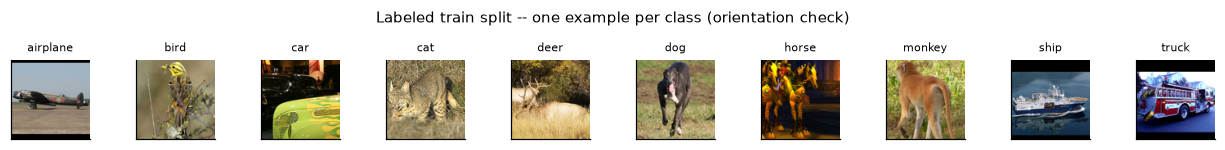

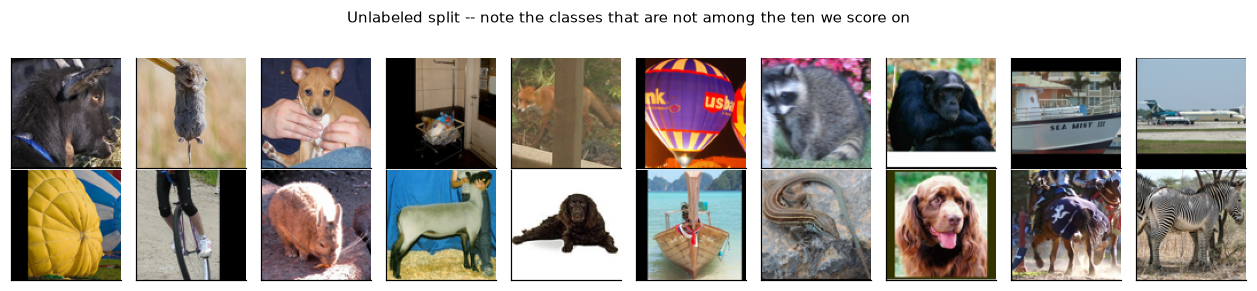

In [8]:
import matplotlib
import matplotlib.pyplot as plt

matplotlib.rcParams.update({
    "figure.dpi": 110,
    "savefig.dpi": 160,
    "font.size": 9,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

COLOR_CONTRASTIVE = "#2a78d6"
COLOR_GENERATIVE = "#eb6834"
COLOR_CNN = "#1baf7a"


def show_image_grid(images_uint8, titles=None, columns=8, title=None, save_as=None):
    """Display a strip of uint8 [N, 3, 96, 96] images."""
    count = len(images_uint8)
    rows = int(np.ceil(count / columns))
    figure, axes = plt.subplots(rows, columns, figsize=(columns * 1.15, rows * 1.3))
    axes = np.atleast_1d(axes).reshape(-1)

    for position in range(rows * columns):
        axis = axes[position]
        axis.set_xticks([]); axis.set_yticks([]); axis.grid(False)
        if position < count:
            axis.imshow(np.asarray(images_uint8[position]).transpose(1, 2, 0))
            if titles is not None:
                axis.set_title(titles[position], fontsize=7.5)
        else:
            axis.axis("off")

    if title:
        figure.suptitle(title, fontsize=10, y=1.0)
    figure.tight_layout()
    if save_as:
        figure.savefig(FIGURES_ROOT / save_as, bbox_inches="tight")
    plt.show()


sample_positions = [np.flatnonzero(train_labels == c)[0] for c in range(NUM_CLASSES)]
show_image_grid(
    train_images[sample_positions],
    titles=[CLASS_NAMES[c] for c in range(NUM_CLASSES)],
    columns=10,
    title="Labeled train split -- one example per class (orientation check)",
    save_as="fig01_labeled_examples.png",
)

unlabeled_sample = np.random.default_rng(SEED).choice(NUM_UNLABELED_IMAGES, 20, replace=False)
show_image_grid(
    np.asarray(unlabeled_images[np.sort(unlabeled_sample)]),
    columns=10,
    title="Unlabeled split -- note the classes that are not among the ten we score on",
    save_as="fig02_unlabeled_examples.png",
)

<div dir="rtl" lang="he" style="text-align: right;">

---

# 2. גזע ה-SE-ResNet המשותף

זהו הרכיב החשוב ביותר בטיעון ההוגנות. שתי הזרועות יוצרות מופע של **אותה מחלקה בדיוק**. אילו השתמשו בארכיטקטורות בסיס שונות, פונקציית המטרה בקדם-האימון כבר לא הייתה המשתנה היחיד, וההשוואה הייתה הופכת לשאלה "איזו ארכיטקטורה טובה יותר".

יש שלושה הבדלים מכוונים ביחס ל-ResNet רגיל:

- **Stem של שתי קונבולוציות ללא max-pool.** תמונות STL-10 בגודל 96×96 קטנות מספיק כך שה-stem המקובל של ImageNet — קונבולוציה 7×7 עם stride 2 ולאחריה pooling — היה מאבד יותר מדי רזולוציה עוד לפני הפעלת בלוק residual כלשהו.
- **בלוקים עם pre-activation** ‏(נרמול ← אקטיבציה ← קונבולוציה), כך שהענף ה-residual מתווסף לאות לא מנורמל והגרדיאנטים מגיעים לשכבות המוקדמות דרך נתיב זהות נקי.
- **שערי squeeze-and-excitation** בכל בלוק, עם reduction של 16 ומינימום של 16 ערוצים חבויים, כדי שה-bottleneck לא יצטמצם לארבעה ערוצים בשלבים הצרים הראשונים.

המעבר המרחבי עבור קלט בגודל 96×96 — ה-decoder בסעיף 6 משקף אותו במדויק:

</div>

```
input                       96 x 96 x   3
stem conv1, stride 2   ->   48 x 48 x  48
stem conv2, stride 1   ->   48 x 48 x  64
stage 0 (depth 2)      ->   48 x 48 x  64     all strides 1
stage 1 (depth 3)      ->   24 x 24 x 128     first block stride 2
stage 2 (depth 4)      ->   12 x 12 x 256     first block stride 2
stage 3 (depth 3)      ->    6 x  6 x 384     first block stride 2
output projection 1x1  ->    6 x  6 x 512
global average pool    ->    1 x  1 x 512
flatten                ->   [B, 512]
```

<div dir="rtl" lang="he" style="text-align: right;">

הפלט בממד 512 הוא נקודת לקיחת הייצוג בשתי הזרועות.

</div>


In [9]:
FINAL_FEATURE_MAP_CHANNELS = STAGE_WIDTHS[-1]
FINAL_FEATURE_MAP_SIZE = 6


class SqueezeExcitation(nn.Module):
    """Channel-attention gate: pool to one value per channel, learn a rescale."""

    def __init__(self, channels, reduction=SE_REDUCTION):
        super().__init__()
        hidden_channels = max(channels // reduction, 16)
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.scale = nn.Sequential(
            nn.Conv2d(channels, hidden_channels, kernel_size=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(hidden_channels, channels, kernel_size=1),
            nn.Sigmoid(),
        )

    def forward(self, x):
        return x * self.scale(self.pool(x))


class PreActivationSEBlock(nn.Module):
    """Pre-activation residual block with a squeeze-and-excitation gate."""

    def __init__(self, in_channels, out_channels, stride):
        super().__init__()

        self.norm1 = nn.BatchNorm2d(in_channels)
        self.activation1 = nn.ReLU(inplace=True)
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride,
                               padding=1, bias=False)
        self.norm2 = nn.BatchNorm2d(out_channels)
        self.activation2 = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1,
                               padding=1, bias=False)
        self.se = SqueezeExcitation(out_channels)

        needs_projection = stride != 1 or in_channels != out_channels
        self.downsample = (
            nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False)
            if needs_projection else None
        )

    def forward(self, x):
        preactivated = self.activation1(self.norm1(x))

        shortcut = x if self.downsample is None else self.downsample(preactivated)

        residual = self.conv1(preactivated)
        residual = self.conv2(self.activation2(self.norm2(residual)))
        return shortcut + self.se(residual)


class SEResNetEncoder(nn.Module):
    """The shared trunk. [B, 3, 96, 96] -> [B, 512]."""

    def __init__(self):
        super().__init__()

        self.stem = nn.Sequential(
            nn.Conv2d(3, STEM_WIDTH, kernel_size=3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(STEM_WIDTH),
            nn.ReLU(inplace=True),
            nn.Conv2d(STEM_WIDTH, STAGE_WIDTHS[0], kernel_size=3, stride=1, padding=1,
                      bias=False),
        )

        stages = []
        in_channels = STAGE_WIDTHS[0]
        for stage_index, (depth, out_channels) in enumerate(zip(STAGE_DEPTHS, STAGE_WIDTHS)):
            blocks = []
            for block_index in range(depth):
                stride = 2 if stage_index > 0 and block_index == 0 else 1
                blocks.append(PreActivationSEBlock(in_channels, out_channels, stride))
                in_channels = out_channels
            stages.append(nn.Sequential(*blocks))

        self.stages = nn.Sequential(*stages)
        self.final_norm = nn.BatchNorm2d(in_channels)
        self.final_activation = nn.ReLU(inplace=True)
        self.output_projection = nn.Conv2d(in_channels, ENCODER_DIM, kernel_size=1, bias=False)
        self.global_pool = nn.AdaptiveAvgPool2d(1)

    def forward(self, x):
        x = self.stem(x)
        x = self.stages(x)
        x = self.final_activation(self.final_norm(x))
        x = self.output_projection(x)
        return self.global_pool(x).flatten(1)


def parameter_count(model):
    return sum(parameter.numel() for parameter in model.parameters())

<div dir="rtl" lang="he" style="text-align: right;">

### אתחול המשקולות

כל שכבה מקבלת את שיטת האתחול המתאימה לפעולה שאחריה, ובשתי הזרועות חלים אותם כללים:

- קונבולוציית **SE reduce**: ‏Kaiming normal עם `fan_in`. אחריה מופעל ReLU, ו-`fan_in` שומר על שונות יציבה של האקטיבציות במעבר הקדמי — הדבר החשוב עבור שער 1×1 המחושב מערכים לאחר pooling.
- קונבולוציית **SE expand** ו-**הטלת הפלט**: ‏Xavier uniform. שתיהן מזינות פעולה שאינה ReLU — שער sigmoid ו-global average pooling בהתאמה — ולכן מקדם ה-ReLU של Kaiming אינו מתאים.
- **כל קונבולוציה אחרת**: ‏Kaiming normal עם `fan_out`, הבחירה המקובלת ב-ResNet. ‏`fan_out` שומר על שונות הגרדיאנט במעבר לאחור דרך ערימת residual עמוקה.
- **BatchNorm**: משקל 1 והטיה 0, כך שכל שכבה מתחילה כהעתקת זהות.

זהויות המודולים נאספות מראש, משום ש-`model.modules()` מחזירה את קונבולוציות ה-SE משולבות בין הקונבולוציות הרגילות, ואין דרך להבחין ביניהן מתוך המודול לבדו.

</div>


In [10]:
def initialize_encoder_weights(module_tree, output_projection=None,
                               projector_hidden=None, projector_output=None):
    """Apply the shared initialization scheme to a trunk (and optionally a projector)."""
    se_reduce_ids, se_expand_ids = set(), set()
    for module in module_tree.modules():
        if isinstance(module, SqueezeExcitation):
            se_reduce_ids.add(id(module.scale[0]))
            se_expand_ids.add(id(module.scale[2]))

    output_projection_id = id(output_projection) if output_projection is not None else None
    projector_hidden_id = id(projector_hidden) if projector_hidden is not None else None
    projector_output_id = id(projector_output) if projector_output is not None else None

    for module in module_tree.modules():
        module_id = id(module)

        if isinstance(module, nn.Conv2d):
            if module_id in se_reduce_ids:
                nn.init.kaiming_normal_(module.weight, mode="fan_in", nonlinearity="relu")
            elif module_id in se_expand_ids or module_id == output_projection_id:
                nn.init.xavier_uniform_(module.weight, gain=1.0)
            else:
                nn.init.kaiming_normal_(module.weight, mode="fan_out", nonlinearity="relu")
            if module.bias is not None:
                nn.init.zeros_(module.bias)

        elif isinstance(module, nn.Linear):
            if module_id == projector_hidden_id:
                nn.init.kaiming_normal_(module.weight, mode="fan_in", nonlinearity="relu")
            elif module_id == projector_output_id:
                nn.init.xavier_uniform_(module.weight, gain=1.0)
            if module.bias is not None:
                nn.init.zeros_(module.bias)

        elif isinstance(module, (nn.BatchNorm1d, nn.BatchNorm2d)):
            nn.init.ones_(module.weight)
            nn.init.zeros_(module.bias)


reset_seed()
reference_encoder = SEResNetEncoder()
initialize_encoder_weights(reference_encoder,
                           output_projection=reference_encoder.output_projection)

with torch.no_grad():
    trace_input = torch.zeros(2, 3, IMAGE_SIZE, IMAGE_SIZE)
    after_stem = reference_encoder.stem(trace_input)
    after_stages = reference_encoder.stages(after_stem)
    embedding = reference_encoder(trace_input)

print("trunk parameters :", format(parameter_count(reference_encoder), ","))
print()
print("shape trace")
print("  input          :", tuple(trace_input.shape))
print("  after stem     :", tuple(after_stem.shape))
print("  after stages   :", tuple(after_stages.shape),
      " <- the decoder in section 6 starts from this")
print("  embedding      :", tuple(embedding.shape))
print()


trunk parameters : 13,385,544

shape trace
  input          : (2, 3, 96, 96)
  after stem     : (2, 64, 48, 48)
  after stages   : (2, 384, 6, 6)  <- the decoder in section 6 starts from this
  embedding      : (2, 512)



<div dir="rtl" lang="he" style="text-align: right;">

---

# 3. אוגמנטציה במימוש עצמי

השימוש ב-`torchvision.transforms` אינו מותר, ולכן כל פעולה הנדרשת לשתי הזרועות ממומשת כאן ב-PyTorch. הדבר התברר כבעל ערך מעבר לעמידה בדרישה: שתי הזרועות קוראות כעת לאותם primitives, ולכן ההבדל בין המדיניות שלהן הוא הבדל במדיניות בלבד ולא במימוש. סעיף 14 בודק כל פעולה מול torchvision על tensor קבוע.

הכול פועל **ב-batches ועל ה-GPU**. מאה אלף התמונות ללא תוויות נשמרות ב-VRAM כ-uint8 ‏(2.76 GB), ואין כלל DataLoader. צינור transforms על ה-CPU לכל תמונה, עם תהליכי worker, היה הופך לצוואר הבקבוק כאשר הנתונים כבר נמצאים על ההתקן.

## היכן מותר לשתי הזרועות להיות שונות

SimCLR *זקוק* ל-views אגרסיביים. פונקציית ההפסד שלו דורשת לקרב שני views של אותה תמונה ולהרחיק כל אחד מהם מכל view של תמונה אחרת ב-batch. לכן שני ה-views חייבים להיות קשים מספיק כדי שהמשימה לא תהיה טריוויאלית. ללא color jitter, המקודד יכול לפתור את המטרה על סמך היסטוגרמות צבע בלבד.

ל-VAE אין view שני ואין עליו לחץ כזה. ההפסד משווה reconstruction למטרה, ולכן **כל אוגמנטציה משנה את המטרה עצמה**. Color jitter חזק הופך את המטרה לתמונה שונה; blur ו-grayscale מוחקים בדיוק את פרטי התדר הגבוה והצבע שעליהם מחושב איבר השחזור, ולכן המודל היה נענש על מידע שנמנע ממנו בכוונה.

כפיית מדיניות זהה לא הייתה הופכת את ההשוואה להוגנת יותר, אלא פוגעת באחת הזרועות באמצעות transform שמתאים רק לאחרת. הרכיבים שכן זהים, וחייבים להיות זהים, הם הגזע, רוחב ונקודת הייצוג, החלוקות, ה-seed, קבועי הנרמול, ה-optimizer ותקציב של 100 epochs.

</div>


In [11]:
GRAYSCALE_WEIGHTS = (0.2989, 0.5870, 0.1140)


def sample_uniform(shape, low, high, reference, generator=None):
    """Uniform draw in [low, high) on `reference`'s device."""
    if generator is None:
        values = torch.rand(shape, device=reference.device, dtype=torch.float32)
    else:
        values = torch.rand(shape, generator=generator, device=generator.device,
                            dtype=torch.float32).to(reference.device)
    return low + (high - low) * values


def _per_image(values):
    """Reshape a [B] factor tensor for broadcasting against [B, C, H, W]."""
    return values.view(-1, 1, 1, 1)


def random_horizontal_flip(batch, probability, generator=None):
    """Flip each image left-right independently with the given probability."""
    if probability <= 0.0:
        return batch
    draw = sample_uniform((batch.shape[0],), 0.0, 1.0, batch, generator)
    should_flip = _per_image(draw < probability)
    return torch.where(should_flip, torch.flip(batch, dims=(3,)), batch)


def random_resized_crop(batch, output_size, scale, ratio, generator=None):
    """Per-image random crop of a random area and aspect, resized to `output_size`."""
    if not batch.is_floating_point():
        raise ValueError("random_resized_crop needs a float batch, got %r" % (batch.dtype,))

    batch_size, _, height, width = batch.shape
    image_area = float(height * width)

    target_area = sample_uniform((batch_size,), scale[0], scale[1], batch, generator) * image_area
    log_aspect = sample_uniform((batch_size,), math.log(ratio[0]), math.log(ratio[1]),
                                batch, generator)
    aspect = torch.exp(log_aspect)

    crop_width = torch.sqrt(target_area * aspect).round().long().clamp(1, width)
    crop_height = torch.sqrt(target_area / aspect).round().long().clamp(1, height)

    top_fraction = sample_uniform((batch_size,), 0.0, 1.0, batch, generator)
    left_fraction = sample_uniform((batch_size,), 0.0, 1.0, batch, generator)
    top = (top_fraction * (height - crop_height + 1).float()).long().clamp(min=0)
    left = (left_fraction * (width - crop_width + 1).float()).long().clamp(min=0)
    top = torch.minimum(top, height - crop_height)
    left = torch.minimum(left, width - crop_width)

    tops, lefts = top.tolist(), left.tolist()
    heights, widths = crop_height.tolist(), crop_width.tolist()

    crops = []
    for index in range(batch_size):
        window = batch[index:index + 1, :,
                       tops[index]:tops[index] + heights[index],
                       lefts[index]:lefts[index] + widths[index]]
        crops.append(F.interpolate(window, size=(output_size, output_size),
                                   mode="bilinear", align_corners=False, antialias=True))
    return torch.cat(crops, dim=0)

<div dir="rtl" lang="he" style="text-align: right;">

## 3.1 פעולות צבע

ארבע הפעולות האלה הן אלה ש-torchvision מסתיר מאחורי `ColorJitter`. כולן פועלות על תמונות בטווח `[0, 1]`, לפני הנרמול — זהו הסדר שבו משתמש צינור הייחוס, וההפוך מן הסדר שבמסלול ה-VAE בסעיף 3.3.

כלל המיזוג הוא זה של torchvision: `result = factor * image + (1 - factor) * reference`, עם חיתוך חזרה אל תוך `[0, 1]`.

- **בהירות** ממזגת מול שחור.
- **ניגודיות** ממזגת מול תמונה אחידה שערכה הוא *הממוצע של גרסת גווני האפור* של הקלט — ולא הממוצע של הערוצים הגולמיים.
- **רוויה** ממזגת מול גרסת גווני האפור עצמה.
- **גוון** היא היקרה שבהן: היא מחייבת מעבר הלוך ושוב דרך HSV, והוספת ההיסט לערוץ הגוון מודולו 1.

סטייה אחת מתועדת. ‏torchvision מגריל תמורה אקראית חדשה של ארבע הפעולות עבור כל תמונה, ואילו אנו מגרילים תמורה אחת לכל batch. החלת סדר נפרד לכל תמונה על מימוש שפועל ב-batches הייתה מחייבת ארבעה מעברים ממוסכים לכל פעולה, וההרכבה קרובה לחילופיות עבור המקדמים הקטנים שבהם משתמשים כאן.

</div>


In [12]:
def rgb_to_grayscale(batch):
    """[B, 3, H, W] -> [B, 1, H, W] using the ITU-R 601-2 luma weights torchvision uses."""
    weights = torch.tensor(GRAYSCALE_WEIGHTS, dtype=batch.dtype,
                           device=batch.device).view(1, 3, 1, 1)
    return (batch * weights).sum(dim=1, keepdim=True)


def blend(image, reference, factor):
    """torchvision's blending rule, with per-image factors."""
    return (_per_image(factor) * image + (1.0 - _per_image(factor)) * reference).clamp(0.0, 1.0)


def adjust_brightness(batch, factor):
    return blend(batch, torch.zeros_like(batch), factor)


def adjust_contrast(batch, factor):
    grey_mean = rgb_to_grayscale(batch).mean(dim=(1, 2, 3), keepdim=True)
    return blend(batch, grey_mean.expand_as(batch), factor)


def adjust_saturation(batch, factor):
    return blend(batch, rgb_to_grayscale(batch).expand_as(batch), factor)


def rgb_to_hsv(batch):
    """[B, 3, H, W] in [0, 1] -> (hue, saturation, value), each [B, 1, H, W]."""
    maximum, argmax = batch.max(dim=1, keepdim=True)
    minimum = batch.min(dim=1, keepdim=True).values
    chroma = maximum - minimum

    safe_chroma = torch.where(chroma > 0, chroma, torch.ones_like(chroma))
    red, green, blue = batch[:, 0:1], batch[:, 1:2], batch[:, 2:3]

    hue_red = ((green - blue) / safe_chroma) % 6.0
    hue_green = ((blue - red) / safe_chroma) + 2.0
    hue_blue = ((red - green) / safe_chroma) + 4.0

    hue = torch.where(argmax == 0, hue_red, torch.where(argmax == 1, hue_green, hue_blue))
    hue = torch.where(chroma > 0, hue / 6.0, torch.zeros_like(hue))

    safe_maximum = torch.where(maximum > 0, maximum, torch.ones_like(maximum))
    saturation = torch.where(maximum > 0, chroma / safe_maximum, torch.zeros_like(maximum))
    return hue, saturation, maximum


def hsv_to_rgb(hue, saturation, value):
    """Inverse of `rgb_to_hsv`."""
    sector = (hue * 6.0).floor()
    offset = hue * 6.0 - sector

    p = value * (1.0 - saturation)
    q = value * (1.0 - saturation * offset)
    t = value * (1.0 - saturation * (1.0 - offset))

    sector = (sector % 6).to(torch.int64)
    red = torch.where(sector == 0, value, torch.where(sector == 1, q,
          torch.where(sector == 2, p, torch.where(sector == 3, p,
          torch.where(sector == 4, t, value)))))
    green = torch.where(sector == 0, t, torch.where(sector == 1, value,
            torch.where(sector == 2, value, torch.where(sector == 3, q,
            torch.where(sector == 4, p, p)))))
    blue = torch.where(sector == 0, p, torch.where(sector == 1, p,
           torch.where(sector == 2, t, torch.where(sector == 3, value,
           torch.where(sector == 4, value, q)))))
    return torch.cat([red, green, blue], dim=1).clamp(0.0, 1.0)


def adjust_hue(batch, shift):
    """Rotate the hue channel by `shift` (a [B] tensor in [-0.5, 0.5])."""
    hue, saturation, value = rgb_to_hsv(batch)
    return hsv_to_rgb((hue + _per_image(shift)) % 1.0, saturation, value)


def random_grayscale(batch, probability, generator=None):
    """Replace each image with its 3-channel greyscale version with the given probability."""
    if probability <= 0.0:
        return batch
    draw = sample_uniform((batch.shape[0],), 0.0, 1.0, batch, generator)
    grey = rgb_to_grayscale(batch).expand_as(batch)
    return torch.where(_per_image(draw < probability), grey, batch)


def gaussian_blur(batch, kernel_size, sigma_range, probability, generator=None):
    """Per-image Gaussian blur, applied with the given probability."""
    if probability <= 0.0:
        return batch

    sigma = float(sample_uniform((1,), sigma_range[0], sigma_range[1], batch, generator).item())
    radius = kernel_size // 2
    positions = torch.arange(kernel_size, dtype=torch.float32, device=batch.device) - radius
    kernel = torch.exp(-(positions ** 2) / (2.0 * sigma * sigma))
    kernel = kernel / kernel.sum()

    channels = batch.shape[1]
    horizontal = kernel.view(1, 1, 1, kernel_size).expand(channels, 1, 1, kernel_size)
    vertical = kernel.view(1, 1, kernel_size, 1).expand(channels, 1, kernel_size, 1)

    padded = F.pad(batch, (radius, radius, radius, radius), mode="reflect")
    blurred = F.conv2d(padded, horizontal, groups=channels)
    blurred = F.conv2d(blurred, vertical, groups=channels)

    draw = sample_uniform((batch.shape[0],), 0.0, 1.0, batch, generator)
    return torch.where(_per_image(draw < probability), blurred, batch)


def color_jitter(batch, brightness, contrast, saturation, hue, probability, generator=None):
    """torchvision's ColorJitter wrapped in a RandomApply, batched."""
    batch_size = batch.shape[0]
    apply_draw = sample_uniform((batch_size,), 0.0, 1.0, batch, generator)
    should_apply = _per_image(apply_draw < probability)

    jittered = batch
    factors = {
        "brightness": sample_uniform((batch_size,), 1 - brightness, 1 + brightness, batch, generator),
        "contrast": sample_uniform((batch_size,), 1 - contrast, 1 + contrast, batch, generator),
        "saturation": sample_uniform((batch_size,), 1 - saturation, 1 + saturation, batch, generator),
        "hue": sample_uniform((batch_size,), -hue, hue, batch, generator),
    }
    operations = {
        "brightness": adjust_brightness,
        "contrast": adjust_contrast,
        "saturation": adjust_saturation,
        "hue": adjust_hue,
    }

    names = list(operations)
    order = torch.randperm(4, generator=generator).tolist() if generator is not None \
        else torch.randperm(4).tolist()
    for position in order:
        name = names[position]
        jittered = operations[name](jittered, factors[name])

    return torch.where(should_apply, jittered, batch)

<div dir="rtl" lang="he" style="text-align: right;">

## 3.2 ארבע מדיניות SimCLR

זהו ניסוי ה-ablation: כל מדיניות היא קדם-אימון מלא של 100 epochs, וההבדלים ביניהן מבודדים פעולה אחת בכל פעם.

| מדיניות | crop | flip | colour | grayscale | blur |
|---|:--:|:--:|:--:|:--:|:--:|
| `P1_crop_color` | ✓ | | ✓ | | |
| `P2_crop_color_blur` | ✓ | | ✓ | | ✓ |
| `P3_crop_flip_color` | ✓ | ✓ | ✓ | | |
| `P4_full_policy` | ✓ | ✓ | ✓ | ✓ | ✓ |

שתי ההשוואות המשמעותיות: **P1 → P2** מבודדת את ה-blur, ו-**P3 → P4** מוסיפה יחד grayscale ו-blur. סעיף 11 קורא את ה-ablation דרך שני הניגודים האלה ולא כדירוג בן ארבע דרכים.

שימו לב שה-crop אגרסיבי כאן הרבה יותר מזה של ה-VAE — עד 20% משטח התמונה, לעומת 80% — וטווח יחסי הממדים רחב יותר. זו בדיוק מהותו של view קונטרסטיבי.

</div>


In [13]:
SIMCLR_CROP = {"output_size": IMAGE_SIZE, "scale": (0.20, 1.00),
                "ratio": (0.75, 4.0 / 3.0), "attempts": 10}
SIMCLR_JITTER = {"brightness": 0.40, "contrast": 0.40, "saturation": 0.40,
                 "hue": 0.10, "probability": 0.80}
SIMCLR_BLUR = {"kernel_size": 9, "sigma_range": (0.10, 2.00), "probability": 0.50}
SIMCLR_GRAYSCALE_PROBABILITY = 0.20
SIMCLR_FLIP_PROBABILITY = 0.50

SIMCLR_POLICIES = {
    "P1_crop_color":      {"flip": False, "grayscale": False, "blur": False},
    "P2_crop_color_blur": {"flip": False, "grayscale": False, "blur": True},
    "P3_crop_flip_color": {"flip": True,  "grayscale": False, "blur": False},
    "P4_full_policy":     {"flip": True,  "grayscale": True,  "blur": True},
}


def simclr_random_resized_crop(batch, output_size, scale, ratio, attempts=10, generator=None):
    """Float-tensor RandomResizedCrop with torchvision's 10-try + centre fallback policy."""
    if not batch.is_floating_point():
        raise ValueError("SimCLR crop expects a floating-point batch")
    if attempts <= 0:
        raise ValueError("attempts must be positive")

    batch_size, _, height, width = batch.shape
    image_area = float(height * width)

    input_ratio = width / height
    if input_ratio < ratio[0]:
        fallback_width = width
        fallback_height = int(round(fallback_width / ratio[0]))
    elif input_ratio > ratio[1]:
        fallback_height = height
        fallback_width = int(round(fallback_height * ratio[1]))
    else:
        fallback_width = width
        fallback_height = height

    crop_width = torch.full(
        (batch_size,), fallback_width, dtype=torch.int64, device=batch.device)
    crop_height = torch.full(
        (batch_size,), fallback_height, dtype=torch.int64, device=batch.device)
    top = torch.full(
        (batch_size,), (height - fallback_height) // 2,
        dtype=torch.int64, device=batch.device)
    left = torch.full(
        (batch_size,), (width - fallback_width) // 2,
        dtype=torch.int64, device=batch.device)

    pending = torch.ones(batch_size, dtype=torch.bool, device=batch.device)
    for _ in range(attempts):
        active = torch.nonzero(pending, as_tuple=False).flatten()
        if active.numel() == 0:
            break

        target_area = sample_uniform(
            (active.numel(),), scale[0], scale[1],
            batch, generator) * image_area
        log_aspect = sample_uniform(
            (active.numel(),), math.log(ratio[0]), math.log(ratio[1]),
            batch, generator)
        aspect = torch.exp(log_aspect)

        proposal_width = torch.round(
            torch.sqrt(target_area * aspect)).to(torch.int64)
        proposal_height = torch.round(
            torch.sqrt(target_area / aspect)).to(torch.int64)
        valid = ((proposal_width > 0) & (proposal_width <= width)
                 & (proposal_height > 0) & (proposal_height <= height))
        accepted = active[valid]
        if accepted.numel() == 0:
            continue

        accepted_width = proposal_width[valid]
        accepted_height = proposal_height[valid]
        top_draw = sample_uniform(
            (accepted.numel(),), 0.0, 1.0, batch, generator)
        left_draw = sample_uniform(
            (accepted.numel(),), 0.0, 1.0, batch, generator)
        accepted_top = torch.floor(
            top_draw * (height - accepted_height + 1).to(torch.float32)
        ).to(torch.int64)
        accepted_left = torch.floor(
            left_draw * (width - accepted_width + 1).to(torch.float32)
        ).to(torch.int64)

        crop_width[accepted] = accepted_width
        crop_height[accepted] = accepted_height
        top[accepted] = accepted_top
        left[accepted] = accepted_left
        pending[accepted] = False

    tops, lefts = top.tolist(), left.tolist()
    heights, widths = crop_height.tolist(), crop_width.tolist()
    crops = []
    for index in range(batch_size):
        window = batch[index:index + 1, :,
                       tops[index]:tops[index] + heights[index],
                       lefts[index]:lefts[index] + widths[index]]
        crops.append(F.interpolate(
            window,
            size=(output_size, output_size),
            mode="bilinear",
            align_corners=False,
            antialias=True,
        ))
    return torch.cat(crops, dim=0)


def simclr_random_horizontal_flip(batch, probability, generator=None):
    """Independent horizontal-flip decision for every image."""
    if probability <= 0.0:
        return batch
    draw = sample_uniform((batch.shape[0],), 0.0, 1.0, batch, generator)
    return torch.where(_per_image(draw < probability), torch.flip(batch, dims=(3,)), batch)


def simclr_color_jitter(batch, brightness, contrast, saturation, hue,
                         probability, generator=None):
    """Per-image RandomApply(ColorJitter), including an independent operation order."""
    batch_size = batch.shape[0]
    apply_mask = sample_uniform(
        (batch_size,), 0.0, 1.0, batch, generator) <= probability
    selected_indices = torch.nonzero(apply_mask, as_tuple=False).flatten()
    if selected_indices.numel() == 0:
        return batch

    selected_batch = batch.index_select(0, selected_indices).clone()
    selected_count = selected_indices.numel()

    permutation_table = torch.tensor(
        [(a, b, c, d)
         for a in range(4)
         for b in range(4) if b != a
         for c in range(4) if c != a and c != b
         for d in range(4) if d != a and d != b and d != c],
        dtype=torch.int64, device=batch.device)
    if generator is None:
        permutation_index = torch.randint(
            0, 24, (selected_count,), device=batch.device)
    else:
        permutation_index = torch.randint(
            0, 24, (selected_count,), generator=generator,
            device=generator.device).to(batch.device)
    operation_order = permutation_table.index_select(0, permutation_index)

    factors = (
        sample_uniform((selected_count,), max(0.0, 1.0 - brightness),
                       1.0 + brightness, selected_batch, generator),
        sample_uniform((selected_count,), max(0.0, 1.0 - contrast),
                       1.0 + contrast, selected_batch, generator),
        sample_uniform((selected_count,), max(0.0, 1.0 - saturation),
                       1.0 + saturation, selected_batch, generator),
        sample_uniform((selected_count,), -hue, hue, selected_batch, generator),
    )
    operations = (adjust_brightness, adjust_contrast, adjust_saturation, adjust_hue)

    jittered = selected_batch
    for order_position in range(4):
        operation_at_position = operation_order[:, order_position]
        for operation_index, operation in enumerate(operations):
            selected = torch.nonzero(
                operation_at_position == operation_index, as_tuple=False
            ).flatten()
            if selected.numel() == 0:
                continue
            selected_images = jittered.index_select(0, selected)
            selected_factors = factors[operation_index].index_select(0, selected)
            updated = operation(selected_images, selected_factors)
            jittered.index_copy_(0, selected, updated)
    output = batch.clone()
    output.index_copy_(0, selected_indices, jittered)
    return output


def simclr_random_grayscale(batch, probability, generator=None):
    """Independent RandomGrayscale decision for every image."""
    if probability <= 0.0:
        return batch
    draw = sample_uniform((batch.shape[0],), 0.0, 1.0, batch, generator)
    grayscale = rgb_to_grayscale(batch).expand_as(batch)
    return torch.where(_per_image(draw < probability), grayscale, batch)


def simclr_gaussian_blur(batch, kernel_size, sigma_range, probability, generator=None):
    """Per-image RandomApply(GaussianBlur) with an independent sigma for every image."""
    if kernel_size <= 0 or kernel_size % 2 == 0:
        raise ValueError("kernel_size must be a positive odd integer")
    if probability <= 0.0:
        return batch

    batch_size, channels, height, width = batch.shape
    apply_mask = sample_uniform(
        (batch_size,), 0.0, 1.0, batch, generator) <= probability
    selected_images = torch.nonzero(apply_mask, as_tuple=False).flatten()
    if selected_images.numel() == 0:
        return batch

    selected_batch = batch.index_select(0, selected_images)
    selected_count = selected_images.numel()
    sigma = sample_uniform(
        (selected_count,), sigma_range[0], sigma_range[1],
        selected_batch, generator)

    radius = kernel_size // 2
    positions = (torch.arange(kernel_size, device=batch.device, dtype=torch.float32)
                 - radius)
    kernels = torch.exp(
        -(positions.view(1, -1) ** 2) / (2.0 * sigma.view(-1, 1) ** 2))
    kernels = kernels / kernels.sum(dim=1, keepdim=True)
    kernels_by_channel = kernels.repeat_interleave(channels, dim=0)

    horizontal = kernels_by_channel.view(selected_count * channels, 1, 1, kernel_size)
    vertical = kernels_by_channel.view(selected_count * channels, 1, kernel_size, 1)

    padded = F.pad(selected_batch, (radius, radius, radius, radius), mode="reflect")
    grouped = padded.reshape(1, selected_count * channels,
                             height + 2 * radius, width + 2 * radius)
    blurred = F.conv2d(grouped, horizontal, groups=selected_count * channels)
    blurred = F.conv2d(blurred, vertical, groups=selected_count * channels)
    blurred = blurred.reshape(selected_count, channels, height, width)

    output = batch.clone()
    output.index_copy_(0, selected_images, blurred)
    return output


def simclr_view(images_uint8, policy_name, generator=None, device=None):
    """Self-contained float-tensor SimCLR policy with torchvision-equivalent semantics."""
    device = DEVICE if device is None else device
    if policy_name not in SIMCLR_POLICIES:
        raise ValueError("unknown SimCLR policy %r" % policy_name)
    policy = SIMCLR_POLICIES[policy_name]

    if isinstance(images_uint8, torch.Tensor):
        view = images_uint8.to(device=device, dtype=torch.float32) / 255.0
    else:
        view = torch.from_numpy(np.ascontiguousarray(images_uint8)).to(
            device=device, dtype=torch.float32) / 255.0

    view = simclr_random_resized_crop(
        view, SIMCLR_CROP["output_size"], SIMCLR_CROP["scale"],
        SIMCLR_CROP["ratio"], SIMCLR_CROP["attempts"], generator)
    if policy["flip"]:
        view = simclr_random_horizontal_flip(
            view, SIMCLR_FLIP_PROBABILITY, generator)
    view = simclr_color_jitter(view, generator=generator, **SIMCLR_JITTER)
    if policy["grayscale"]:
        view = simclr_random_grayscale(
            view, SIMCLR_GRAYSCALE_PROBABILITY, generator)
    if policy["blur"]:
        view = simclr_gaussian_blur(view, generator=generator, **SIMCLR_BLUR)

    mean = torch.as_tensor(
        NORMALIZATION_MEAN, dtype=torch.float32, device=device).view(1, -1, 1, 1)
    std = torch.as_tensor(
        NORMALIZATION_STD, dtype=torch.float32, device=device).view(1, -1, 1, 1)
    return (view - mean) / std


<div dir="rtl" lang="he" style="text-align: right;">

## 3.3 מדיניות ה-VAE

Flip ו-crop מתון. די בכך כדי למנוע מה-decoder לשנן מיקומי פיקסלים, אך לא כדי לשנות את מהות המטרה.

יש שני פרטים חשובים בסדר הפעולות:

**תחילה נרמול, אחר כך אוגמנטציה.** ה-crop מבצע דגימה מחדש בילינארית וממילא דורש tensor מסוג float. נרמול לאחר ה-crop היה מחשב סטטיסטיקות על פיקסלים שעברו דגימה מחדש במקום להשתמש בקבועים המשותפים לשתי הזרועות.

**ה-view לאחר האוגמנטציה הוא גם מטרת השחזור.** לולאת האימון מזינה למודל את הפלט של `augment_vae_batch` ומשתמשת באותו tensor כמטרה. שחזור המקור ללא האוגמנטציה מתוך קלט שעבר אוגמנטציה היה הופך את המודל ל-denoising autoencoder, מטרה שונה מה-ELBO.

</div>


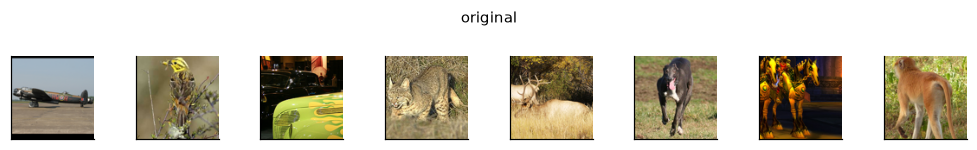

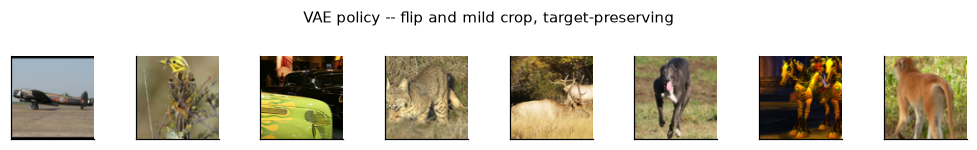

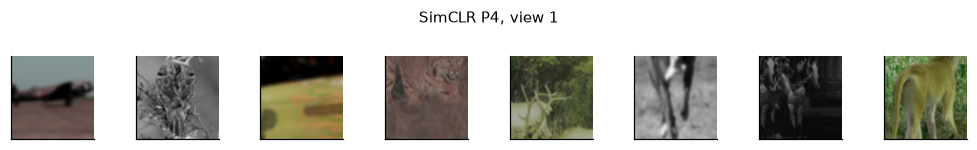

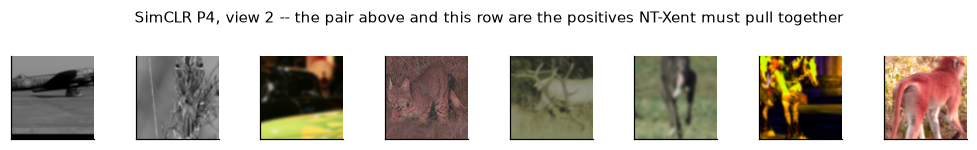

In [14]:
VAE_AUGMENTATION = {
    "horizontal_flip_probability": 0.5,
    "crop_scale": (0.8, 1.0),
    "crop_ratio": (0.9, 1.1),
    "output_size": IMAGE_SIZE,
}


def augment_vae_batch(batch, generator=None):
    """Flip, then a mild random resized crop. Input must already be normalized."""
    augmented = random_horizontal_flip(
        batch, VAE_AUGMENTATION["horizontal_flip_probability"], generator)
    return random_resized_crop(augmented, VAE_AUGMENTATION["output_size"],
                               VAE_AUGMENTATION["crop_scale"],
                               VAE_AUGMENTATION["crop_ratio"], generator)


reset_seed()
demo_source = train_images[sample_positions[:8]]
demo_generator = seeded_generator(SEED)

vae_views = augment_vae_batch(normalize_batch(demo_source), demo_generator)
simclr_view_a = simclr_view(demo_source, "P4_full_policy", demo_generator)
simclr_view_b = simclr_view(demo_source, "P4_full_policy", demo_generator)

show_image_grid(np.asarray(demo_source), columns=8,
                title="original", save_as="fig03a_original.png")

show_image_grid((denormalize_for_display(vae_views).numpy() * 255).astype(np.uint8),
                columns=8, title="VAE policy -- flip and mild crop, target-preserving",
                save_as="fig03b_vae_policy.png")

show_image_grid((denormalize_for_display(simclr_view_a).numpy() * 255).astype(np.uint8),
                columns=8, title="SimCLR P4, view 1", save_as="fig03c_simclr_view1.png")

show_image_grid((denormalize_for_display(simclr_view_b).numpy() * 255).astype(np.uint8),
                columns=8, title="SimCLR P4, view 2 -- the pair above and this row are the "
                                 "positives NT-Xent must pull together",
                save_as="fig03d_simclr_view2.png")


<div dir="rtl" lang="he" style="text-align: right;">

---

# 4. Optimizer ולוח קצב הלמידה

ההגדרות זהות בשתי הזרועות וגם ב-CNN של שלב ההמשך בסעיף 12: ‏AdamW, ‏warmup לינארי במשך 10 epochs, ולאחריו cosine decay מ-5e-4 עד 1e-5.

שני פרטים שקל לטעות בהם עלולים להפר את שוויון התקציב בלי סימן ברור:

**Weight decay מוחל רק על פרמטרים רב-ממדיים.** הבדיקה `ndim == 1` מוציאה בבת אחת כל משקל והטיה של BatchNorm וכל הטיה של קונבולוציה או שכבה לינארית. דחיפת scale של BatchNorm לכיוון אפס פועלת נגד הנרמול שהוא אמור לבצע, ו-decay על הטיות רק מוסיף רעש; לאף אחד מהם אין את מנגנון ה-overfitting שמצדיק weight decay על מטריצת משקולות.

**לוח הזמנים מחושב בכל צעד optimizer ולא בכל epoch.** עם כ-390 צעדים בכל epoch, לוח זמנים ברמת epoch היה משאיר את קצב הלמידה קבוע לאורך כל epoch ויוצר עקומת אימון שונה בבירור.

</div>


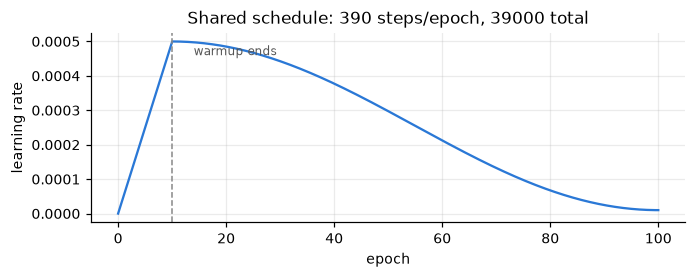

peak lr at step 3899, final lr 1.00e-05


In [15]:
def build_optimizer(model, weight_decay=WEIGHT_DECAY):
    """AdamW with weight decay on multi-dimensional parameters only."""
    decay, no_decay = [], []
    for parameter in model.parameters():
        (no_decay if parameter.ndim == 1 else decay).append(parameter)

    return torch.optim.AdamW(
        [{"params": decay, "weight_decay": weight_decay},
         {"params": no_decay, "weight_decay": 0.0}],
        lr=0.0,
    )


def learning_rate_at_step(step, total_steps, warmup_steps,
                          max_lr=MAX_LEARNING_RATE, min_lr=MIN_LEARNING_RATE):
    """Linear warmup then cosine decay, per optimizer step."""
    if step < warmup_steps:
        return max_lr * ((step + 1) / warmup_steps)

    denominator = max(total_steps - warmup_steps - 1, 1)
    progress = min((step - warmup_steps) / denominator, 1.0)
    return min_lr + (max_lr - min_lr) * 0.5 * (1.0 + math.cos(math.pi * progress))


def set_learning_rate(optimizer, learning_rate):
    for group in optimizer.param_groups:
        group["lr"] = learning_rate


steps_per_epoch_demo = NUM_UNLABELED_IMAGES // BATCH_SIZE
total_steps_demo = steps_per_epoch_demo * EPOCHS
warmup_steps_demo = steps_per_epoch_demo * WARMUP_EPOCHS
schedule = [learning_rate_at_step(s, total_steps_demo, warmup_steps_demo)
            for s in range(total_steps_demo)]

figure, axis = plt.subplots(figsize=(6.4, 2.6))
axis.plot(np.arange(total_steps_demo) / steps_per_epoch_demo, schedule, color=COLOR_CONTRASTIVE)
axis.axvline(WARMUP_EPOCHS, color="#888", linestyle="--", linewidth=1)
axis.annotate("warmup ends", xy=(WARMUP_EPOCHS, MAX_LEARNING_RATE),
              xytext=(WARMUP_EPOCHS + 4, MAX_LEARNING_RATE * 0.92), fontsize=8, color="#555")
axis.set_xlabel("epoch"); axis.set_ylabel("learning rate")
axis.set_title("Shared schedule: %d steps/epoch, %d total" % (steps_per_epoch_demo, total_steps_demo))
figure.tight_layout(); figure.savefig(FIGURES_ROOT / "fig04_lr_schedule.png", bbox_inches="tight")
plt.show()

print("peak lr at step %d, final lr %.2e" % (int(np.argmax(schedule)), schedule[-1]))

<div dir="rtl" lang="he" style="text-align: right;">

---

# 5. הזרוע הקונטרסטיבית

SimCLR לוקח שני views מאוגמנטים של אותה תמונה ומבקש מהמקודד למקם אותם קרוב זה לזה יותר מכפי שכל אחד מהם קרוב לכל view של כל תמונה אחרת ב-batch. אין decoder ואין שחזור — הלחץ היחיד הוא הבחנה.

**ראש ההטלה נזרק לאחר קדם-האימון.** ההפסד הקונטרסטיבי מוחל על הפלט שלו בממד 128, אך הייצוג שכל שלבי ההמשך משתמשים בו הוא המאפיין בממד 512 של המקודד לאחר pooling. זו הפרקטיקה המקובלת ב-SimCLR, וזה גם מה ששומר על שתי הזרועות בנות-השוואה: שתיהן לוקחות וקטור בממד 512 מאותו גזע.

## NT-Xent

עבור batch של B תמונות אנו בונים 2B views. ה-positive של כל view הוא התאום שלו, וכל view אחר ב-batch הוא negative. כאשר `projections` מנורמל ב-L2, מטריצת דמיון הקוסינוס מחולקת בטמפרטורה נותנת את ה-logits, וההפסד הוא cross-entropy על כל שורה כאשר התאום משמש מחלקת המטרה.

שני פרטי מימוש שראוי לציין:

- **הדמיון העצמי ממוסך למינוס אינסוף** לפני ה-log-sum-exp. כל view דומה לעצמו באופן טריוויאלי, והשארת האלכסון הייתה מאפשרת למודל למזער את ההפסד בלי ללמוד דבר.
- ה-views משורגים בסדר `[a0, b0, a1, b1, ...]`, ולכן התאום של view נמצא באמצעות היפוך הסיבית הנמוכה של האינדקס שלו — `indices ^ 1`. זו הסיבה שפעולת ה-stack ולאחריה reshape מתבצעת לפני הנרמול, ולא שרשור פשוט.

טמפרטורה 0.20 היא נמוכה. היא מחדדת את ההתפלגות ומרכזת את רוב הגרדיאנט על ה-negatives הקשים ביותר.

</div>


In [16]:
class ProjectionHead(nn.Module):
    """512 -> 512 -> 128 MLP. Used only during pretraining, then discarded."""

    def __init__(self):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(ENCODER_DIM, PROJECTOR_HIDDEN_DIM, bias=False),
            nn.BatchNorm1d(PROJECTOR_HIDDEN_DIM),
            nn.ReLU(inplace=True),
            nn.Linear(PROJECTOR_HIDDEN_DIM, PROJECTOR_OUTPUT_DIM, bias=False),
        )

    def forward(self, x):
        return self.layers(x)


class SimCLRModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = SEResNetEncoder()
        self.projection_head = ProjectionHead()
        initialize_encoder_weights(
            self,
            output_projection=self.encoder.output_projection,
            projector_hidden=self.projection_head.layers[0],
            projector_output=self.projection_head.layers[3],
        )

    def forward(self, x):
        return self.projection_head(self.encoder(x))


def nt_xent(z1, z2, temperature=TEMPERATURE):
    """Normalized temperature-scaled cross-entropy over 2B interleaved views."""
    batch_size = z1.shape[0]

    projections = torch.stack((z1, z2), dim=1).reshape(2 * batch_size, -1)
    projections = F.normalize(projections, p=2, dim=1)
    logits = (projections @ projections.T) / temperature

    number_of_views = 2 * batch_size
    indices = torch.arange(number_of_views, device=projections.device)
    positive_indices = indices ^ 1

    self_mask = torch.eye(number_of_views, dtype=torch.bool, device=projections.device)
    logits_without_self = logits.masked_fill(self_mask, -torch.inf)

    positive_logits = logits[indices, positive_indices]
    return (-positive_logits + torch.logsumexp(logits_without_self, dim=1)).mean()


demo_model = SimCLRModel()
print("encoder parameters   :", format(parameter_count(demo_model.encoder), ","))
print("projector parameters :", format(parameter_count(demo_model.projection_head), ","))
print("total                :", format(parameter_count(demo_model), ","))
print()
print("A perfectly collapsed encoder -- every view mapped to the same point -- scores")
print("log(2B - 1) on this loss, which for batch %d is %.4f. That is the number to" % (
    BATCH_SIZE, math.log(2 * BATCH_SIZE - 1)))
print("watch the training curve against.")
del demo_model

encoder parameters   : 13,385,544
projector parameters : 328,704
total                : 13,714,248

A perfectly collapsed encoder -- every view mapped to the same point -- scores
log(2B - 1) on this loss, which for batch 256 is 6.2364. That is the number to
watch the training curve against.


In [17]:
PROBE_EPOCHS = (50, 60, 70, 80, 90, 100)


class CheckpointStandardizer:
    """Manual StandardScaler equivalent, fitted on training features only."""

    def __init__(self, zero_variance_threshold=1e-12):
        self.mean = None
        self.standard_deviation = None
        self.zero_variance_threshold = zero_variance_threshold

    def fit(self, features):
        matrix = torch.as_tensor(np.asarray(features), dtype=torch.float64)
        self.mean = matrix.mean(dim=0)
        self.standard_deviation = matrix.std(dim=0, unbiased=False)
        self.standard_deviation = torch.where(
            self.standard_deviation > self.zero_variance_threshold,
            self.standard_deviation,
            torch.ones_like(self.standard_deviation),
        )
        return self

    def transform(self, features):
        if self.mean is None:
            raise RuntimeError("CheckpointStandardizer.transform called before fit")
        matrix = torch.as_tensor(np.asarray(features), dtype=torch.float64)
        return (matrix - self.mean) / self.standard_deviation


def fit_checkpoint_logistic(features, labels, c_value,
                            max_iterations=LINEAR_MAX_ITERATIONS,
                            tolerance=LINEAR_TOLERANCE):
    """Manual multinomial logistic regression with sklearn-equivalent C scaling."""
    matrix = torch.as_tensor(np.asarray(features), dtype=torch.float64)
    label_vector = torch.as_tensor(np.asarray(labels), dtype=torch.int64).reshape(-1)
    weights = torch.zeros(
        matrix.shape[1], NUM_CLASSES, dtype=torch.float64, requires_grad=True)
    bias = torch.zeros(NUM_CLASSES, dtype=torch.float64, requires_grad=True)
    strength = float(c_value)

    optimizer = torch.optim.LBFGS(
        [weights, bias],
        lr=1.0,
        max_iter=max_iterations,
        tolerance_grad=tolerance * strength,
        tolerance_change=1e-9,
        history_size=10,
        line_search_fn="strong_wolfe",
    )

    def objective():
        optimizer.zero_grad(set_to_none=True)
        logits = matrix @ weights + bias
        data_fit = F.cross_entropy(logits, label_vector, reduction="sum")
        loss = 0.5 * (weights * weights).sum() + strength * data_fit
        loss.backward()
        return loss

    optimizer.step(objective)
    return weights.detach(), bias.detach()


def checkpoint_predict_proba(features, weights, bias):
    matrix = torch.as_tensor(np.asarray(features), dtype=torch.float64)
    return torch.softmax(matrix @ weights + bias, dim=1)


def checkpoint_stratified_k_fold(labels, num_splits, seed):
    """Manual stratified K-fold split with balanced class remainders."""
    label_array = np.asarray(labels).reshape(-1)
    generator = np.random.default_rng(seed)
    per_split = [[] for _ in range(num_splits)]
    rotation = 0

    for class_id in np.unique(label_array):
        shuffled = generator.permutation(np.flatnonzero(label_array == class_id))
        assignment = (np.arange(len(shuffled)) + rotation) % num_splits
        for split_index in range(num_splits):
            per_split[split_index].append(shuffled[assignment == split_index])
        rotation = (rotation + len(shuffled)) % num_splits

    all_positions = np.arange(label_array.shape[0], dtype=np.int64)
    splits = []
    for split_index in range(num_splits):
        validation = np.sort(np.concatenate(per_split[split_index])).astype(np.int64)
        held_out = np.zeros(label_array.shape[0], dtype=bool)
        held_out[validation] = True
        splits.append((all_positions[~held_out], validation))
    return splits


def checkpoint_classification_metrics(labels, probabilities):
    """Accuracy, macro-F1 and log loss without sklearn."""
    truth = torch.as_tensor(np.asarray(labels), dtype=torch.int64).reshape(-1)
    probability_tensor = torch.as_tensor(
        np.asarray(probabilities), dtype=torch.float64)
    predictions = probability_tensor.argmax(dim=1)

    flat = torch.bincount(
        truth * NUM_CLASSES + predictions,
        minlength=NUM_CLASSES * NUM_CLASSES,
    )
    confusion = flat.reshape(NUM_CLASSES, NUM_CLASSES).to(torch.float64)
    true_positives = torch.diagonal(confusion)
    predicted_totals = confusion.sum(dim=0)
    actual_totals = confusion.sum(dim=1)

    accuracy = true_positives.sum() / torch.clamp(confusion.sum(), min=1.0)
    precision = torch.where(
        predicted_totals > 0,
        true_positives / torch.clamp(predicted_totals, min=1.0),
        torch.zeros_like(true_positives),
    )
    recall = torch.where(
        actual_totals > 0,
        true_positives / torch.clamp(actual_totals, min=1.0),
        torch.zeros_like(true_positives),
    )
    f1 = torch.where(
        precision + recall > 0,
        2.0 * precision * recall / torch.clamp(precision + recall, min=1e-300),
        torch.zeros_like(precision),
    )

    epsilon = float(np.finfo(np.float64).eps)
    clipped = torch.clamp(probability_tensor, min=epsilon, max=1.0 - epsilon)
    clipped = clipped / clipped.sum(dim=1, keepdim=True)
    true_probability = clipped.gather(1, truth.reshape(-1, 1)).reshape(-1)
    log_loss = -torch.log(true_probability).mean()

    return {
        "accuracy": float(accuracy.item()),
        "f1_macro": float(f1.mean().item()),
        "log_loss": float(log_loss.item()),
    }


@torch.inference_mode()
def extract_labeled_probe_features(encoder, batch_size=FEATURE_BATCH_SIZE, head=None):
    """Frozen float32 features for the 5,000 labeled train images."""
    modules = [encoder] if head is None else [encoder, head]
    was_training = [module.training for module in modules]
    for module in modules:
        module.eval()

    feature_batches = []
    for start in range(0, len(train_images), batch_size):
        batch = normalize_batch(train_images[start:start + batch_size])
        features = encoder(batch)
        if head is not None:
            features = head(features)
        feature_batches.append(features.float().cpu().numpy())

    for module, training in zip(modules, was_training):
        if training:
            module.train()
    return np.concatenate(feature_batches, axis=0)


def cross_validate_checkpoint_c(features, labels, random_state):
    """Manual inner stratified C search on the outer fold's 800 train images."""
    splits = checkpoint_stratified_k_fold(
        labels, CROSS_VALIDATION_SPLITS, random_state)
    rows = []

    for c_value in LINEAR_C_GRID:
        fold_metrics = []
        for train_positions, validation_positions in splits:
            standardizer = CheckpointStandardizer().fit(features[train_positions])
            train_features = standardizer.transform(features[train_positions])
            validation_features = standardizer.transform(features[validation_positions])
            weights, bias = fit_checkpoint_logistic(
                train_features, labels[train_positions], c_value)
            probabilities = checkpoint_predict_proba(
                validation_features, weights, bias)
            fold_metrics.append(checkpoint_classification_metrics(
                labels[validation_positions], probabilities))

        rows.append({
            "c": float(c_value),
            "log_loss_mean": float(np.mean([m["log_loss"] for m in fold_metrics])),
            "accuracy_mean": float(np.mean([m["accuracy"] for m in fold_metrics])),
            "f1_macro_mean": float(np.mean([m["f1_macro"] for m in fold_metrics])),
        })
    return rows


def evaluate_checkpoint_probe(encoder, head=None):
    """Manual nested development probe with one C shared by all official folds."""
    features = extract_labeled_probe_features(encoder, head=head)
    prepared_folds = []
    inner_rows_by_fold = []

    for fold_index, official_indices in enumerate(OFFICIAL_FOLDS):
        train_positions, validation_positions = DEVELOPMENT_SPLITS[fold_index]
        fold_features = features[official_indices]
        fold_labels = train_labels[official_indices]

        development_train_features = fold_features[train_positions]
        development_train_labels = fold_labels[train_positions]
        development_validation_features = fold_features[validation_positions]
        development_validation_labels = fold_labels[validation_positions]

        inner_rows_by_fold.append(cross_validate_checkpoint_c(
            development_train_features,
            development_train_labels,
            random_state=SEED + fold_index,
        ))
        prepared_folds.append({
            "fold": fold_index,
            "train_features": development_train_features,
            "train_labels": development_train_labels,
            "validation_features": development_validation_features,
            "validation_labels": development_validation_labels,
        })

    aggregate_rows = []
    for c_value in LINEAR_C_GRID:
        matching = [
            row for fold_rows in inner_rows_by_fold for row in fold_rows
            if float(row["c"]) == float(c_value)
        ]
        aggregate_rows.append({
            "c": float(c_value),
            "log_loss_mean": float(np.mean([row["log_loss_mean"] for row in matching])),
            "accuracy_mean": float(np.mean([row["accuracy_mean"] for row in matching])),
            "f1_macro_mean": float(np.mean([row["f1_macro_mean"] for row in matching])),
        })

    selected_c = float(min(
        aggregate_rows,
        key=lambda row: (
            row["log_loss_mean"],
            -row["accuracy_mean"],
            -row["f1_macro_mean"],
            row["c"],
        ),
    )["c"])

    fold_rows = []
    for fold in prepared_folds:
        standardizer = CheckpointStandardizer().fit(fold["train_features"])
        train_features = standardizer.transform(fold["train_features"])
        validation_features = standardizer.transform(fold["validation_features"])
        weights, bias = fit_checkpoint_logistic(
            train_features, fold["train_labels"], selected_c)
        probabilities = checkpoint_predict_proba(
            validation_features, weights, bias)
        metrics = checkpoint_classification_metrics(
            fold["validation_labels"], probabilities)
        fold_rows.append({"fold": fold["fold"], **metrics})

    return {
        "selected_c": selected_c,
        "log_loss_mean": float(np.mean([row["log_loss"] for row in fold_rows])),
        "accuracy_mean": float(np.mean([row["accuracy"] for row in fold_rows])),
        "f1_macro_mean": float(np.mean([row["f1_macro"] for row in fold_rows])),
        "fold_log_loss": [float(row["log_loss"]) for row in fold_rows],
        "fold_accuracy": [float(row["accuracy"]) for row in fold_rows],
        "fold_f1_macro": [float(row["f1_macro"]) for row in fold_rows],
        "c_search_summary": aggregate_rows,
    }


def is_better_checkpoint(candidate, current_best,
                         loss_epsilon=1e-4, metric_epsilon=5e-4):
    """Same checkpoint-ranking rule as the ablation notebook."""
    if current_best is None:
        return True

    loss_improvement = current_best["log_loss_mean"] - candidate["log_loss_mean"]
    if loss_improvement > loss_epsilon:
        return True
    if loss_improvement < -loss_epsilon:
        return False

    accuracy_improvement = candidate["accuracy_mean"] - current_best["accuracy_mean"]
    if accuracy_improvement > metric_epsilon:
        return True
    if accuracy_improvement < -metric_epsilon:
        return False

    f1_improvement = candidate["f1_macro_mean"] - current_best["f1_macro_mean"]
    return f1_improvement > metric_epsilon


def cpu_encoder_state(encoder):
    """Detached snapshot: later optimizer steps cannot mutate a selected checkpoint."""
    return {key: value.detach().cpu().clone()
            for key, value in encoder.state_dict().items()}


def train_simclr(policy_name, epochs=EPOCHS, batch_size=BATCH_SIZE, seed=SEED,
                 log_every=10, images=None):
    """Pretrain SimCLR and select the best development checkpoint at probe epochs."""
    images = unlabeled_images if images is None else images
    reset_seed(seed)

    model = SimCLRModel().to(DEVICE)
    optimizer = build_optimizer(model)
    generator = seeded_generator(seed)

    number_of_images = len(images)
    steps_per_epoch = number_of_images // batch_size
    total_steps = steps_per_epoch * epochs
    warmup_steps = steps_per_epoch * WARMUP_EPOCHS

    history = []
    probe_history = []
    best_summary = None
    best_epoch = None
    best_encoder_state = None
    global_step = 0
    started = time.time()

    for epoch_index in range(epochs):
        epoch_number = epoch_index + 1
        model.train()
        permutation = torch.randperm(number_of_images, generator=generator).numpy()
        epoch_loss, epoch_batches = 0.0, 0

        for step in range(steps_per_epoch):
            positions = np.sort(permutation[step * batch_size:(step + 1) * batch_size])
            raw = np.asarray(images[positions])

            learning_rate = learning_rate_at_step(global_step, total_steps, warmup_steps)
            set_learning_rate(optimizer, learning_rate)

            view_one = simclr_view(raw, policy_name, generator)
            view_two = simclr_view(raw, policy_name, generator)

            projections = model(torch.cat((view_one, view_two), dim=0))
            z1, z2 = projections.chunk(2, dim=0)
            loss = nt_xent(z1, z2)

            optimizer.zero_grad(set_to_none=True)
            loss.backward()
            optimizer.step()

            epoch_loss += float(loss.item())
            epoch_batches += 1
            global_step += 1

        record = {
            "epoch": epoch_number,
            "loss": epoch_loss / max(epoch_batches, 1),
            "learning_rate": learning_rate,
            "elapsed_seconds": time.time() - started,
        }
        history.append(record)

        if epoch_number % log_every == 0 or epoch_number == epochs:
            print("  %-18s epoch %3d/%d  loss %.4f  lr %.2e  %s"
                  % (policy_name, epoch_number, epochs, record["loss"], learning_rate,
                     format_duration(record["elapsed_seconds"])))

        if epoch_number in PROBE_EPOCHS:
            summary = evaluate_checkpoint_probe(model.encoder)
            probe_history.append({"epoch": epoch_number, **summary})
            print("    probe: log loss %.4f  accuracy %.4f  macro-F1 %.4f  C=%g"
                  % (summary["log_loss_mean"], summary["accuracy_mean"],
                     summary["f1_macro_mean"], summary["selected_c"]))

            if is_better_checkpoint(summary, best_summary):
                best_summary = summary.copy()
                best_epoch = epoch_number
                best_encoder_state = cpu_encoder_state(model.encoder)

    final_encoder_state = cpu_encoder_state(model.encoder)
    if best_encoder_state is None:
        best_encoder_state = final_encoder_state
        best_epoch = epochs
        best_summary = None

    return {
        "encoder_state": best_encoder_state,
        "final_encoder_state": final_encoder_state,
        "best_epoch": best_epoch,
        "best_summary": best_summary,
        "probe_history": probe_history,
        "history": history,
        "policy": policy_name,
        "seed": seed,
    }


SIMCLR_RUNS = {}
for policy_name in SIMCLR_POLICIES:
    SIMCLR_RUNS[policy_name] = cached(
        RUNS_ROOT / ("simclr_joint2b_probe_selftv_exactlogic_manual_%s_seed%d.pt" % (policy_name, SEED)),
        lambda name=policy_name: train_simclr(name),
        "SimCLR pretrain + checkpoint probes, %s" % policy_name,
    )

print()
print("policy               selected epoch   final NT-Xent loss")
for policy_name, run in SIMCLR_RUNS.items():
    print("  %-20s %14d   %.4f"
          % (policy_name, run["best_epoch"], run["history"][-1]["loss"]))


[building  ] SimCLR pretrain + checkpoint probes, P1_crop_color


  P1_crop_color      epoch  10/100  loss 2.3380  lr 5.00e-04  13m 26s


  P1_crop_color      epoch  20/100  loss 2.0813  lr 4.85e-04  26m 51s


  P1_crop_color      epoch  30/100  loss 1.9852  lr 4.43e-04  40m 17s


  P1_crop_color      epoch  40/100  loss 1.9249  lr 3.78e-04  53m 43s


...

    probe: log loss 0.6460  accuracy 0.7765  macro-F1 0.7769  C=0.1


  P4_full_policy     epoch  90/100  loss 1.9969  lr 2.48e-05  2h 09m


    probe: log loss 0.6452  accuracy 0.7775  macro-F1 0.7780  C=0.1


  P4_full_policy     epoch 100/100  loss 1.9934  lr 1.00e-05  2h 25m


    probe: log loss 0.6387  accuracy 0.7820  macro-F1 0.7825  C=0.1
[done      ] SimCLR pretrain + checkpoint probes, P4_full_policy in 2h 27m

policy               selected epoch   final NT-Xent loss
  P1_crop_color                   100   1.8016
  P2_crop_color_blur              100   1.8516
  P3_crop_flip_color              100   1.8140
  P4_full_policy                  100   1.9934


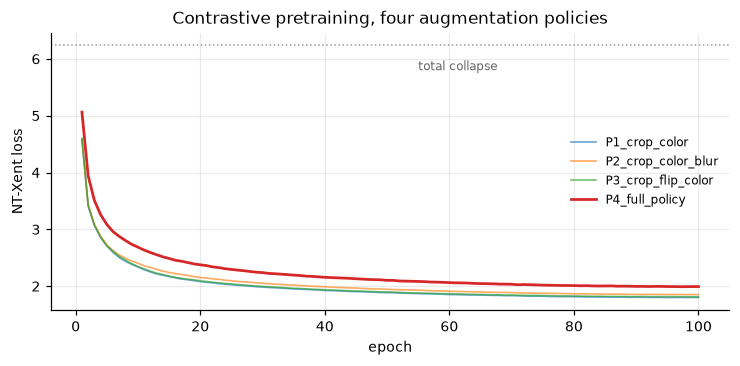

In [18]:
figure, axis = plt.subplots(figsize=(6.8, 3.4))
for policy_name, run in SIMCLR_RUNS.items():
    losses = [record["loss"] for record in run["history"]]
    axis.plot(range(1, len(losses) + 1), losses, label=policy_name,
              linewidth=1.8 if policy_name == "P4_full_policy" else 1.1,
              alpha=1.0 if policy_name == "P4_full_policy" else 0.65)

axis.axhline(math.log(2 * BATCH_SIZE - 1), color="#999", linestyle=":", linewidth=1)
axis.annotate("total collapse", xy=(EPOCHS * 0.6, math.log(2 * BATCH_SIZE - 1)),
              xytext=(EPOCHS * 0.55, math.log(2 * BATCH_SIZE - 1) * 0.93),
              fontsize=8, color="#666")
axis.set_xlabel("epoch"); axis.set_ylabel("NT-Xent loss")
axis.set_title("Contrastive pretraining, four augmentation policies")
axis.legend(frameon=False, fontsize=8)
figure.tight_layout(); figure.savefig(FIGURES_ROOT / "fig05_simclr_loss.png", bbox_inches="tight")
plt.show()


<div dir="rtl" lang="he" style="text-align: right;">

## 5.1 מסלולי ה-probe התקופתי

העקומות שלהלן משתמשות אך ורק בעשרת ה-folds הרשמיים של ה-**development**. כל fold אימון רשמי בן 1,000 תמונות מחולק ל-800/200, וחלוקת ה-test בת 8,000 התמונות אינה נקראת ואינה משמשת כאן. כל נקודה היא הערכה אמיתית של probe מוקפא באחד משישה ה-checkpoints המתוזמנים, ולא אינטרפולציה בין epochs שלא נמדדו.

</div>


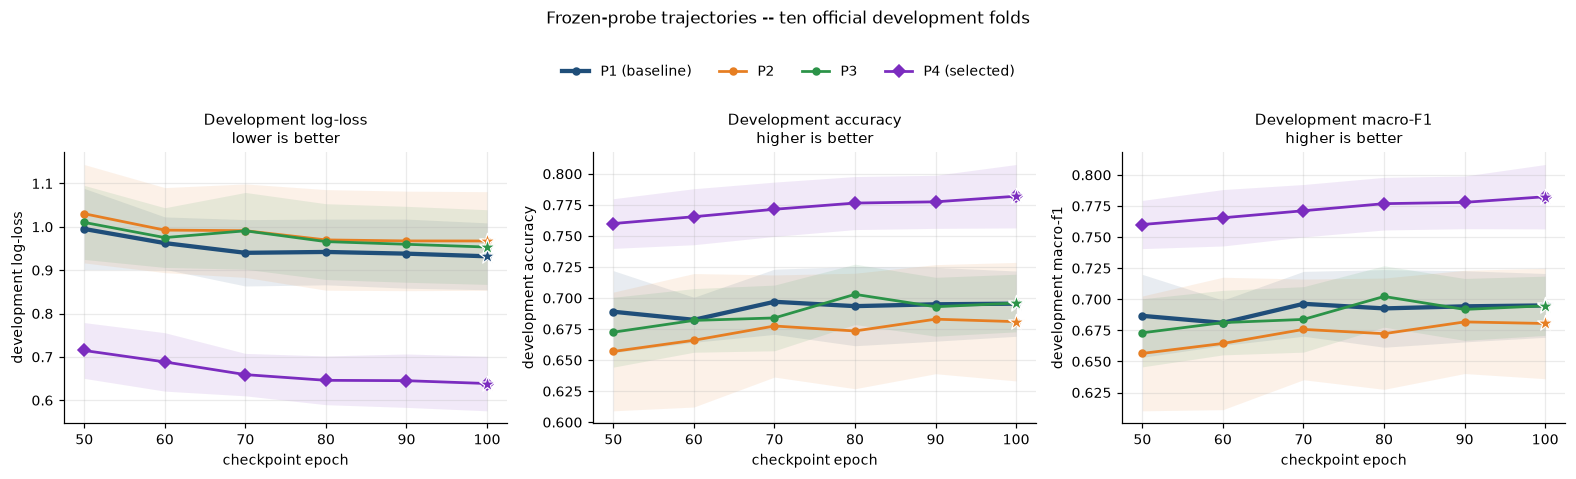

selected C at every periodic checkpoint (development only)
policy       50       60       70       80       90      100
P1          0.1      0.1      0.1      0.1      0.1      0.1
P2          0.1      0.1      0.1      0.1      0.1      0.1
P3          0.1      0.1      0.1      0.1      0.1      0.1
P4          0.1      0.1      0.1      0.1      0.1      0.1

development-selected policy: P4


In [19]:
POLICY_SHORT_NAMES = {
    "P1_crop_color": "P1",
    "P2_crop_color_blur": "P2",
    "P3_crop_flip_color": "P3",
    "P4_full_policy": "P4",
}
POLICY_COLORS = {
    "P1_crop_color": "#1f4e79",
    "P2_crop_color_blur": "#e67e22",
    "P3_crop_flip_color": "#2b9348",
    "P4_full_policy": "#7b2cbf",
}

trajectory_selected_policy = None
trajectory_selected_summary = None
for policy_name in SIMCLR_POLICIES:
    candidate = SIMCLR_RUNS[policy_name]["best_summary"]
    if is_better_checkpoint(candidate, trajectory_selected_summary):
        trajectory_selected_policy = policy_name
        trajectory_selected_summary = candidate

trajectory_specs = (
    ("log_loss_mean", "fold_log_loss", "Development log-loss", "lower is better"),
    ("accuracy_mean", "fold_accuracy", "Development accuracy", "higher is better"),
    ("f1_macro_mean", "fold_f1_macro", "Development macro-F1", "higher is better"),
)

figure, axes = plt.subplots(1, 3, figsize=(14.4, 3.8), sharex=True)
for axis, (mean_key, fold_key, title, direction) in zip(axes, trajectory_specs):
    for policy_name, run in SIMCLR_RUNS.items():
        points = sorted(run["probe_history"], key=lambda row: row["epoch"])
        epochs = np.asarray([row["epoch"] for row in points], dtype=np.int64)
        means = np.asarray([row[mean_key] for row in points], dtype=np.float64)
        deviations = np.asarray([
            np.asarray(row[fold_key], dtype=np.float64).std(ddof=1) for row in points
        ])
        color = POLICY_COLORS[policy_name]
        label = POLICY_SHORT_NAMES[policy_name]
        if label == "P1":
            label += " (baseline)"
        if policy_name == trajectory_selected_policy:
            label += " (selected)"
        axis.plot(epochs, means,
                  marker="D" if policy_name == trajectory_selected_policy else "o",
                  markersize=5.2 if policy_name == trajectory_selected_policy else 4.5,
                  linewidth=2.8 if policy_name == "P1_crop_color" else 1.8,
                  color=color, label=label)
        axis.fill_between(epochs, means - deviations, means + deviations,
                          color=color, alpha=0.10, linewidth=0)

        best_epoch = int(run["best_epoch"])
        best_position = np.flatnonzero(epochs == best_epoch)
        if best_position.size:
            position = int(best_position[0])
            axis.scatter([best_epoch], [means[position]], marker="*", s=115,
                         color=color, edgecolor="white", linewidth=0.8, zorder=5)

    axis.set_xticks(PROBE_EPOCHS)
    axis.set_xlabel("checkpoint epoch")
    axis.set_ylabel(title.lower())
    axis.set_title("%s\n%s" % (title, direction), fontsize=10)

handles, labels = axes[0].get_legend_handles_labels()
figure.legend(handles, labels, frameon=False, ncol=4, loc="upper center",
              bbox_to_anchor=(0.5, 1.03))
figure.suptitle("Frozen-probe trajectories -- ten official development folds",
                y=1.13, fontsize=11)
figure.tight_layout()
figure.savefig(FIGURES_ROOT / "fig05b_simclr_probe_trajectory.png",
               bbox_inches="tight")
plt.show()

print("selected C at every periodic checkpoint (development only)")
print("%-6s %8s %8s %8s %8s %8s %8s"
      % ("policy", *[str(epoch) for epoch in PROBE_EPOCHS]))
for policy_name, run in SIMCLR_RUNS.items():
    by_epoch = {int(row["epoch"]): float(row["selected_c"])
                for row in run["probe_history"]}
    print("%-6s %s" % (POLICY_SHORT_NAMES[policy_name],
          " ".join("%8g" % by_epoch[epoch] for epoch in PROBE_EPOCHS)))

print()
print("development-selected policy:", POLICY_SHORT_NAMES[trajectory_selected_policy])


<div dir="rtl" lang="he" style="text-align: right;">

---

# 6. הזרוע הגנרטיבית

אותו גזע, אותו תקציב ואותו optimizer — עם ELBO במקום NT-Xent.

</div>

```
x -> SEResNetEncoder -> 512-d -> to_mu     -> mu      (512-d)
                              -> to_logvar -> logvar  (512-d)
     mu, logvar -> reparameterize -> z -> Decoder -> reconstruction
```

<div dir="rtl" lang="he" style="text-align: right;">

## קוד שלבי ההמשך משתמש ב-`mu`, ולעולם לא בדגימה

כל שלב לאחר קדם-האימון — הייצוגים, הגרף, ההעברה, הסריקות וה-probe — קורא את `mu` ורק אותו. `mu` הוא פונקציה דטרמיניסטית של התמונה, ולכן מטריצת הייצוגים בגודל 105,000 × 512 והגרף הנבנה ממנה זהים בכל חישוב מחדש.

דגימה `z = mu + sigma * epsilon` אינה דטרמיניסטית. חילוץ מחדש תוך דגימה היה משנה כל דמיון קוסינוס זוגי, מסדר מחדש את top-K ליד נקודות שוויון, משנה את קבוצת הקשתות ומשנה אילו תוויות מגיעות לאן. הדיוק היה משתנה בין הרצות מסיבות שאינן קשורות לשאלת המחקר, וניסוי ה-ablation של β — שמטרתו לייחס שינויים בדיוק ההעברה ל-β — היה למעשה מודד רעש.

לכן `reparameterize` מחזירה את `mu` ללא שינוי במצב eval, כך שזו ברירת המחדל בכל קוד שקרא ל-`.eval()`. דגימה משמשת רק באימון, והיא זו שהופכת את המודל ל-VAE ולא ל-autoencoder רגיל: הרעש מאלץ נקודות לטנטיות סמוכות להתפענח לתמונות דומות, בדיוק תכונת החלקות המקומית שהעברת תוויות מניחה.

</div>


<div dir="rtl" lang="he" style="text-align: right;">

## ה-decoder משקף את המקודד

ארבע הכפלות גודל מבטלות את מקדם ההקטנה הכולל 16 של המקודד — stem עם stride 2 ושלושה שלבים נוספים עם stride 2 — ומחזירות את הפלט לגודל 96×96.

**הגדלה בשיטת nearest-neighbour ואחריה קונבולוציה עם stride 1, ולא `ConvTranspose2d`.** קונבולוציה משוחלפת עם stride 2 מכסה פיקסלי פלט מספר לא אחיד של פעמים, וכך נוצרת תבנית מחזורית מוכרת מסוג checkerboard. במחולל תמונות זו בעיה חזותית בלבד, אך כאן זו בעיה מתודולוגית: גרדיאנט השחזור הוא האות *היחיד* שמעצב את המרחב הלטנטי. אם ה-decoder יכול להקטין את ההפסד באמצעות רשת קבועה בתדר גבוה, המקודד נדחף לקודד מידע שעוזר ליישר את הרשת — מבנה דמוי-מרקם במקום זהות האובייקט. הגרף היה נבנה בדיוק על הכיוונים האלה. הפרדת שינוי הגודל, שאין בו פרמטרים, מן הסינון באמצעות קונבולוציה ב-stride 1 שנוגעת באופן שווה בכל פיקסל פלט, מונעת את הארטיפקט מעצם המבנה.

**לקונבולוציה הסופית אין פונקציית אקטיבציה.** המטרה היא תמונה *מנורמלת*, בקירוב בטווח [−2.5, +2.5] ועם שני הסימנים. ראש sigmoid או tanh היה חותך את הטווח ומונע מהשגיאה הריבועית להגיע לאפס.

</div>


In [20]:
DECODER_STAGE_WIDTHS = (STAGE_WIDTHS[2], STAGE_WIDTHS[1], STAGE_WIDTHS[0], STEM_WIDTH)

LOGVAR_MINIMUM, LOGVAR_MAXIMUM = -10.0, 10.0


class Decoder(nn.Module):
    """512-d latent -> [B, 3, 96, 96]."""

    def __init__(self, latent_dim=LATENT_DIM):
        super().__init__()
        self.initial_channels = FINAL_FEATURE_MAP_CHANNELS
        self.initial_size = FINAL_FEATURE_MAP_SIZE

        self.latent_projection = nn.Linear(
            latent_dim, self.initial_channels * self.initial_size ** 2)

        stages, in_channels = [], self.initial_channels
        for out_channels in DECODER_STAGE_WIDTHS:
            stages.append(nn.Sequential(
                nn.Upsample(scale_factor=2, mode="nearest"),
                nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),
                nn.BatchNorm2d(out_channels),
                nn.ReLU(inplace=True),
            ))
            in_channels = out_channels
        self.stages = nn.Sequential(*stages)

        self.output_projection = nn.Conv2d(in_channels, 3, kernel_size=3, padding=1)

    def forward(self, z):
        x = self.latent_projection(z)
        x = x.view(-1, self.initial_channels, self.initial_size, self.initial_size)
        return self.output_projection(self.stages(x))


class VariationalAutoencoder(nn.Module):
    def __init__(self, latent_dim=LATENT_DIM):
        super().__init__()
        self.encoder = SEResNetEncoder()
        initialize_encoder_weights(self.encoder,
                                   output_projection=self.encoder.output_projection)
        self.latent_dim = latent_dim
        self.to_mu = nn.Linear(ENCODER_DIM, latent_dim)
        self.to_logvar = nn.Linear(ENCODER_DIM, latent_dim)
        self.decoder = Decoder(latent_dim)

    def encode(self, x):
        features = self.encoder(x)
        return self.to_mu(features), self.to_logvar(features).clamp(LOGVAR_MINIMUM, LOGVAR_MAXIMUM)

    def reparameterize(self, mu, logvar):
        if not self.training:
            return mu
        standard_deviation = torch.exp(0.5 * logvar)
        return mu + standard_deviation * torch.randn_like(standard_deviation)

    def forward(self, x):
        mu, logvar = self.encode(x)
        return self.decoder(self.reparameterize(mu, logvar)), mu, logvar


def vae_loss(reconstruction, target, mu, logvar, beta):
    """Beta-weighted negative ELBO. Returns (total, reconstruction, kl)."""
    reconstruction_term = ((reconstruction - target) ** 2).flatten(1).sum(dim=1).mean()
    kl_term = (-0.5 * (1.0 + logvar - mu.pow(2) - logvar.exp()).sum(dim=1)).mean()
    return reconstruction_term + beta * kl_term, reconstruction_term, kl_term


def beta_at_epoch(epoch, beta_max, warmup_epochs=BETA_WARMUP_EPOCHS):
    """Linear KL warmup: 0 at epoch 0, beta_max from `warmup_epochs` on."""
    if warmup_epochs <= 0:
        return beta_max
    return beta_max * min(epoch / warmup_epochs, 1.0)

In [21]:
def vae_head_state(model):
    """Detached snapshot of both latent heads, to match the encoder snapshot."""
    return {"to_mu": {key: value.detach().cpu().clone()
                      for key, value in model.to_mu.state_dict().items()},
            "to_logvar": {key: value.detach().cpu().clone()
                          for key, value in model.to_logvar.state_dict().items()}}


def train_vae(beta_max, epochs=EPOCHS, batch_size=BATCH_SIZE, seed=SEED,
              log_every=10, images=None):
    """Pretrain one VAE at a given beta and select its best development checkpoint."""
    images = unlabeled_images if images is None else images
    reset_seed(seed)

    model = VariationalAutoencoder().to(DEVICE)
    optimizer = build_optimizer(model)
    generator = seeded_generator(seed)

    number_of_images = len(images)
    steps_per_epoch = number_of_images // batch_size
    total_steps = steps_per_epoch * epochs
    warmup_steps = steps_per_epoch * WARMUP_EPOCHS

    history = []
    probe_history = []
    best_summary = None
    best_epoch = None
    best_encoder_state = None
    best_head_state = None
    global_step = 0
    started = time.time()

    for epoch in range(epochs):
        epoch_number = epoch + 1
        model.train()
        beta = beta_at_epoch(epoch, beta_max)
        permutation = torch.randperm(number_of_images, generator=generator).numpy()
        totals = {"loss": 0.0, "reconstruction": 0.0, "kl": 0.0}
        batches = 0

        for step in range(steps_per_epoch):
            positions = np.sort(permutation[step * batch_size:(step + 1) * batch_size])

            learning_rate = learning_rate_at_step(global_step, total_steps, warmup_steps)
            set_learning_rate(optimizer, learning_rate)

            target = augment_vae_batch(
                normalize_batch(np.asarray(images[positions])), generator)
            reconstruction, mu, logvar = model(target)
            loss, reconstruction_term, kl_term = vae_loss(reconstruction, target, mu, logvar, beta)

            optimizer.zero_grad(set_to_none=True)
            loss.backward()
            optimizer.step()

            totals["loss"] += float(loss.item())
            totals["reconstruction"] += float(reconstruction_term.item())
            totals["kl"] += float(kl_term.item())
            batches += 1
            global_step += 1

        record = {"epoch": epoch, "beta": beta,
                  "loss": totals["loss"] / max(batches, 1),
                  "reconstruction": totals["reconstruction"] / max(batches, 1),
                  "kl": totals["kl"] / max(batches, 1),
                  "learning_rate": learning_rate,
                  "elapsed_seconds": time.time() - started}
        history.append(record)

        if epoch % log_every == 0 or epoch == epochs - 1:
            print("  beta=%-6g epoch %3d/%d  recon %9.2f  KL %8.2f  beta_t %.4f  %s"
                  % (beta_max, epoch + 1, epochs, record["reconstruction"], record["kl"],
                     beta, format_duration(record["elapsed_seconds"])))

        if epoch_number in PROBE_EPOCHS:
            summary = evaluate_checkpoint_probe(model.encoder, head=model.to_mu)
            probe_history.append({"epoch": epoch_number, **summary})
            print("    probe: log loss %.4f  accuracy %.4f  macro-F1 %.4f  C=%g"
                  % (summary["log_loss_mean"], summary["accuracy_mean"],
                     summary["f1_macro_mean"], summary["selected_c"]))

            if is_better_checkpoint(summary, best_summary):
                best_summary = summary.copy()
                best_epoch = epoch_number
                best_encoder_state = cpu_encoder_state(model.encoder)
                best_head_state = vae_head_state(model)

    final_encoder_state = cpu_encoder_state(model.encoder)
    final_head_state = vae_head_state(model)
    if best_encoder_state is None:
        best_encoder_state = final_encoder_state
        best_head_state = final_head_state
        best_epoch = epochs
        best_summary = None

    return {"encoder_state": best_encoder_state,
            "head_state": best_head_state,
            "final_encoder_state": final_encoder_state,
            "final_head_state": final_head_state,
            "best_epoch": best_epoch,
            "best_summary": best_summary,
            "probe_history": probe_history,
            "history": history, "beta": beta_max, "seed": seed}


VAE_RUNS = {}
for beta_value in BETA_GRID:
    VAE_RUNS[beta_value] = cached(
        RUNS_ROOT / ("vae_probe_bestckpt_beta%g_seed%d.pt" % (beta_value, SEED)),
        lambda b=beta_value: train_vae(b),
        "VAE pretrain, beta=%g" % beta_value,
    )

print()
print("  beta    final reconstruction    final KL (nats)   best epoch")
for beta_value, run in VAE_RUNS.items():
    last = run["history"][-1]
    print("  %-7g %18.2f %17.2f %12s"
          % (beta_value, last["reconstruction"], last["kl"], run["best_epoch"]))

[building  ] VAE pretrain, beta=0


  beta=0      epoch   1/100  recon  20260.40  KL   134.31  beta_t 0.0000  51s


  beta=0      epoch  11/100  recon   3998.70  KL  2059.65  beta_t 0.0000  9m 22s


  beta=0      epoch  21/100  recon   3175.54  KL  2294.12  beta_t 0.0000  17m 54s


  beta=0      epoch  31/100  recon   2845.11  KL  2323.59  beta_t 0.0000  26m 26s


...

  beta=1      epoch  81/100  recon   3171.81  KL   354.50  beta_t 1.0000  1h 16m


    probe: log loss 2.2119  accuracy 0.3370  macro-F1 0.3347  C=0.1


  beta=1      epoch  91/100  recon   3135.69  KL   356.16  beta_t 1.0000  1h 26m


  beta=1      epoch 100/100  recon   3119.82  KL   356.79  beta_t 1.0000  1h 34m


    probe: log loss 2.2119  accuracy 0.3380  macro-F1 0.3359  C=0.1
[done      ] VAE pretrain, beta=1 in 1h 36m

  beta    final reconstruction    final KL (nats)   best epoch
  0                  2164.75           2335.81          100
  0.001              2168.34           2335.36          100
  0.003              2166.65           2334.96          100
  0.01               2179.32           2302.56          100
  0.03               2207.58           1921.71           80
  0.1                2312.65           1365.27          100
  0.3                2591.82            716.32          100
  1                  3119.82            356.79           60


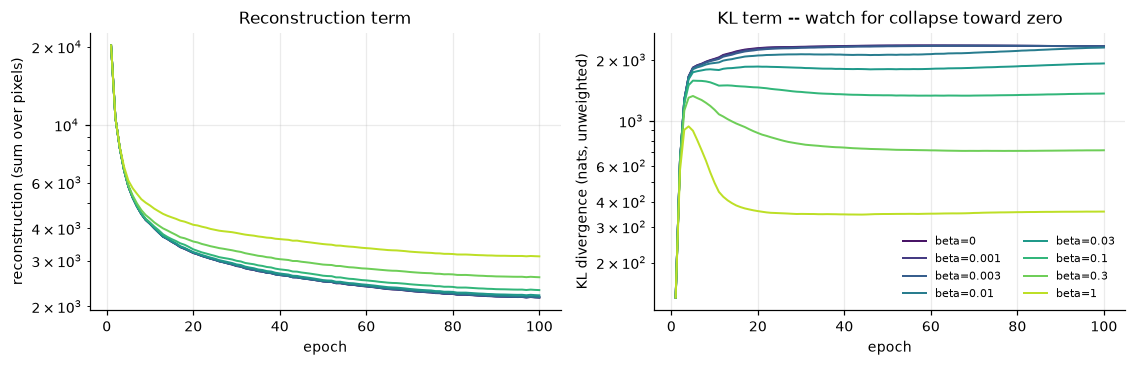

In [22]:
figure, axes = plt.subplots(1, 2, figsize=(10.4, 3.4))
palette = plt.cm.viridis(np.linspace(0.05, 0.9, len(BETA_GRID)))

for color, (beta_value, run) in zip(palette, VAE_RUNS.items()):
    epochs_axis = [record["epoch"] + 1 for record in run["history"]]
    axes[0].plot(epochs_axis, [r["reconstruction"] for r in run["history"]],
                 color=color, label="beta=%g" % beta_value, linewidth=1.3)
    axes[1].plot(epochs_axis, [r["kl"] for r in run["history"]],
                 color=color, label="beta=%g" % beta_value, linewidth=1.3)

axes[0].set_xlabel("epoch"); axes[0].set_ylabel("reconstruction (sum over pixels)")
axes[0].set_title("Reconstruction term"); axes[0].set_yscale("log")
axes[1].set_xlabel("epoch"); axes[1].set_ylabel("KL divergence (nats, unweighted)")
axes[1].set_title("KL term -- watch for collapse toward zero"); axes[1].set_yscale("log")
axes[1].legend(frameon=False, fontsize=7.5, ncol=2)
figure.tight_layout(); figure.savefig(FIGURES_ROOT / "fig06_vae_training.png", bbox_inches="tight")
plt.show()


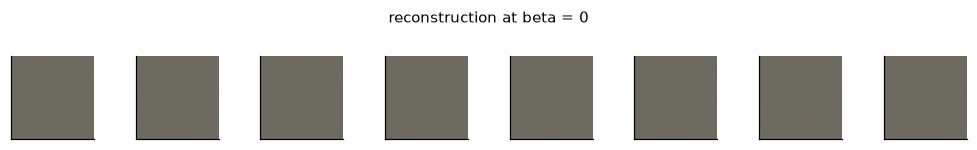

beta=0      mean per-dimension spread of mu across these 8 images: 0.3147


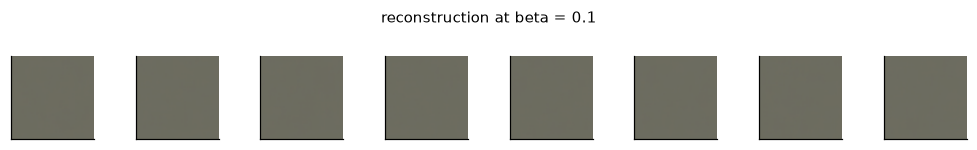

beta=0.1    mean per-dimension spread of mu across these 8 images: 0.6041


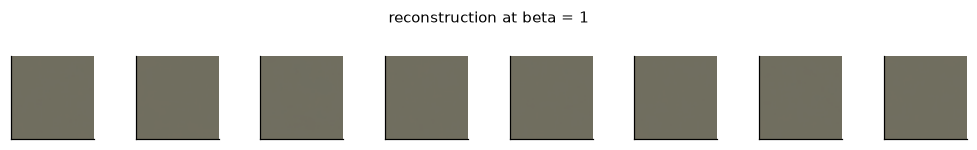

beta=1      mean per-dimension spread of mu across these 8 images: 0.3536


In [23]:
reset_seed()
reconstruction_source = normalize_batch(train_images[sample_positions[:8]])

for beta_value in (BETA_GRID[0], 0.1, BETA_GRID[-1]):
    model = VariationalAutoencoder().to(DEVICE)
    model.encoder.load_state_dict(VAE_RUNS[beta_value]["encoder_state"])
    model.to_mu.load_state_dict(VAE_RUNS[beta_value]["head_state"]["to_mu"])
    model.to_logvar.load_state_dict(VAE_RUNS[beta_value]["head_state"]["to_logvar"])
    model.eval()
    with torch.inference_mode():
        reconstruction, mu, _ = model(reconstruction_source)
    show_image_grid((denormalize_for_display(reconstruction).numpy() * 255).astype(np.uint8),
                    columns=8, title="reconstruction at beta = %g" % beta_value,
                    save_as="fig07_reconstruction_beta%g.png" % beta_value)
    spread = mu.std(dim=0).mean().item()
    print("beta=%-6g mean per-dimension spread of mu across these 8 images: %.4f"
          % (beta_value, spread))
    del model

<div dir="rtl" lang="he" style="text-align: right;">

## 6.1 מסלולי ה-probe התקופתי בזרוע הגנרטיבית

אותם שישה checkpoints, אותו probe ואותו כלל דירוג כמו בסעיף 5.1. הכוכב מסמן את ה-checkpoint שנבחר עבור כל beta. קריאת שני הסעיפים זה לצד זה היא ההשוואה שבמרכז המחקר: לא רק מספר מול מספר, אלא האופן שבו קריאה לינארית של כל מרחב לטנטי מתפתחת לאורך קדם-האימון.

</div>


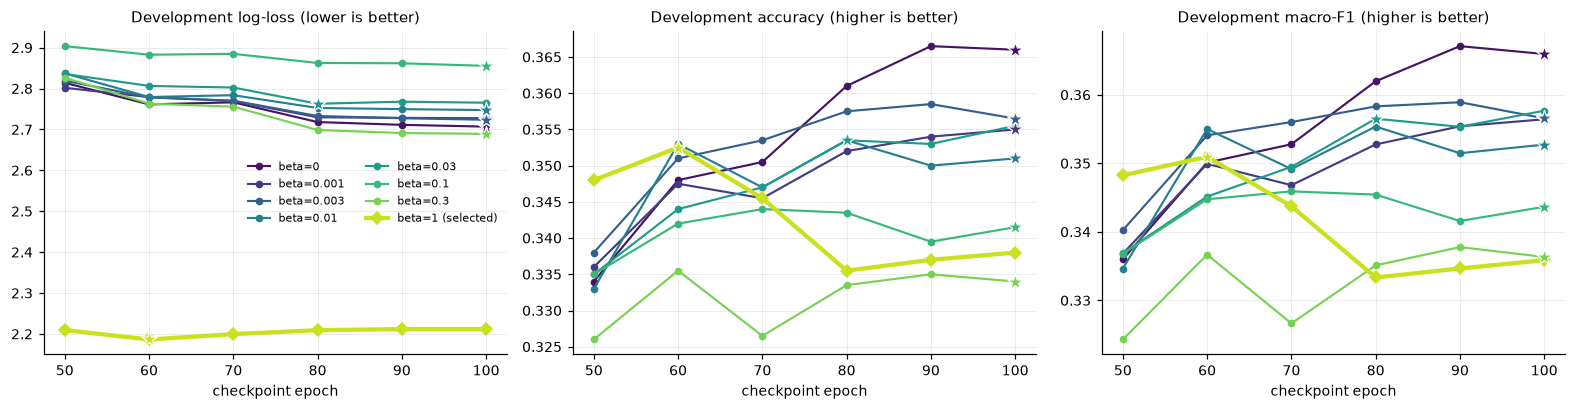

  beta        ep 50    ep 60    ep 70    ep 80    ep 90   ep 100   best
  0          0.3340   0.3480   0.3505   0.3610   0.3665   0.3660    100
  0.001      0.3360   0.3475   0.3455   0.3520   0.3540   0.3550    100
  0.003      0.3380   0.3510   0.3535   0.3575   0.3585   0.3565    100
  0.01       0.3330   0.3530   0.3470   0.3535   0.3500   0.3510    100
  0.03       0.3350   0.3440   0.3470   0.3535   0.3530   0.3555     80
  0.1        0.3350   0.3420   0.3440   0.3435   0.3395   0.3415    100
  0.3        0.3260   0.3355   0.3265   0.3335   0.3350   0.3340    100
  1          0.3480   0.3525   0.3455   0.3355   0.3370   0.3380     60


In [24]:
BETA_COLORS = plt.cm.viridis(np.linspace(0.05, 0.92, len(BETA_GRID)))

trajectory_selected_beta = None
trajectory_best_summary = None
for beta_value, run in VAE_RUNS.items():
    candidate = run["best_summary"]
    if is_better_checkpoint(candidate, trajectory_best_summary):
        trajectory_selected_beta = beta_value
        trajectory_best_summary = candidate

vae_trajectory_specs = (
    ("log_loss_mean", "fold_log_loss", "Development log-loss", "lower is better"),
    ("accuracy_mean", "fold_accuracy", "Development accuracy", "higher is better"),
    ("f1_macro_mean", "fold_f1_macro", "Development macro-F1", "higher is better"),
)

figure, axes = plt.subplots(1, 3, figsize=(14.4, 3.8), sharex=True)
for axis, (mean_key, fold_key, title, direction) in zip(axes, vae_trajectory_specs):
    for color, (beta_value, run) in zip(BETA_COLORS, VAE_RUNS.items()):
        points = sorted(run["probe_history"], key=lambda row: row["epoch"])
        epochs = np.asarray([row["epoch"] for row in points], dtype=np.int64)
        means = np.asarray([row[mean_key] for row in points], dtype=np.float64)
        selected = beta_value == trajectory_selected_beta

        axis.plot(epochs, means,
                  marker="D" if selected else "o",
                  markersize=5.2 if selected else 4.0,
                  linewidth=2.8 if selected else 1.4,
                  color=color,
                  label=("beta=%g (selected)" % beta_value) if selected else "beta=%g" % beta_value)

        best_position = np.flatnonzero(epochs == int(run["best_epoch"]))
        if best_position.size:
            axis.scatter([run["best_epoch"]], [means[int(best_position[0])]],
                         marker="*", s=115, color=color,
                         edgecolor="white", linewidth=0.8, zorder=5)

    axis.set_xticks(PROBE_EPOCHS)
    axis.set_xlabel("checkpoint epoch")
    axis.set_title("%s (%s)" % (title, direction), fontsize=10)
    axis.grid(alpha=0.25, linewidth=0.6)

axes[0].legend(fontsize=7.2, ncol=2, frameon=False)
figure.tight_layout()
figure.savefig(FIGURES_ROOT / "fig06a_vae_probe_trajectory.png",
               bbox_inches="tight")
plt.show()

print("  beta    " + "".join("%9s" % ("ep %d" % epoch) for epoch in PROBE_EPOCHS) + "   best")
for beta_value, run in VAE_RUNS.items():
    by_epoch = {row["epoch"]: row["accuracy_mean"] for row in run["probe_history"]}
    print("  %-7g " % beta_value
          + "".join("%9.4f" % by_epoch[epoch] for epoch in PROBE_EPOCHS)
          + "%7d" % run["best_epoch"])


<div dir="rtl" lang="he" style="text-align: right;">

---

# 7. ייצוגים מוקפאים

שתי הזרועות מוקפאות כעת, וכל שלב המשך קורא מערך שמור במקום את המקודד. הגרף כולל את חלוקת ה-unlabeled ואת חלוקת ה-train המתויגת — 105,000 צמתים — כך שכל צומת שאליו תווית עשויה להגיע נמצא במערך רציף אחד ובסדר קבוע:

</div>

```
index      0 .. 99,999    the 100,000 unlabeled images
index 100,000 .. 104,999  the 5,000 labeled train images
```

<div dir="rtl" lang="he" style="text-align: right;">

הסידור הזה חיוני. סעיף 9 זורע תווית בצומת `NUM_UNLABELED_IMAGES + position` עבור תמונה מתויגת במיקום `position`, וה-offset אינו מופיע במקום אחר.

הייצוגים נשמרים כ-fp32 בשתי הזרועות: 105,000 × 512 הם כ-215 MB לכל מקודד, ויש שנים-עשר מקודדים — שמונה ערכי β וארבע מדיניות SimCLR. הדיוק חייב להיות זהה, משום שההשוואה היא בין הזרועות; שמירת זרוע אחת בחצי דיוק והשנייה בדיוק יחיד הייתה מכניסה הבדל quantization לתוך ההשוואה. גם צבירה ב-fp16 של מכפלה פנימית בת 512 איברים מאבדת דיוק בכמות שמספיקה לסידור מחדש של נקודות כמעט שוות ב-top-K, ובכך משנה את הגרף בלי סימן גלוי.

</div>


In [25]:
@torch.inference_mode()
def extract_embeddings(encoder_state, batch_size=FEATURE_BATCH_SIZE, head_state=None,
                       output_dtype=torch.float32):
    """Encode the 105,000 graph nodes with a frozen trunk in `output_dtype`."""
    encoder = SEResNetEncoder().to(DEVICE)
    encoder.load_state_dict(encoder_state)
    encoder.eval()

    projection = None
    if head_state is not None:
        projection = nn.Linear(ENCODER_DIM, LATENT_DIM).to(DEVICE)
        projection.load_state_dict(head_state)
        projection.eval()

    output = torch.empty(NUM_GRAPH_NODES, ENCODER_DIM, dtype=output_dtype)
    cursor = 0

    for source in (unlabeled_images, train_images):
        for start in range(0, len(source), batch_size):
            batch = normalize_batch(np.asarray(source[start:start + batch_size]))
            features = encoder(batch)
            if projection is not None:
                features = projection(features)
            output[cursor:cursor + features.shape[0]] = features.to(output_dtype).cpu()
            cursor += features.shape[0]

    assert cursor == NUM_GRAPH_NODES, "expected %d nodes, encoded %d" % (NUM_GRAPH_NODES, cursor)
    del encoder, projection
    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()
    return output


VAE_EMBEDDINGS = {}
for beta_value, run in VAE_RUNS.items():
    VAE_EMBEDDINGS[beta_value] = cached(
        RUNS_ROOT / ("embeddings_vae_fp32_beta%g_seed%d.pt" % (beta_value, SEED)),
        lambda r=run: extract_embeddings(r["encoder_state"], head_state=r["head_state"]["to_mu"],
                                        output_dtype=torch.float32),
        "embeddings, VAE beta=%g" % beta_value,
    )

SIMCLR_EMBEDDINGS = {}
for policy_name, run in SIMCLR_RUNS.items():
    SIMCLR_EMBEDDINGS[policy_name] = cached(
        RUNS_ROOT / ("embeddings_simclr_joint2b_probe_selftv_exactlogic_manual_fp32_%s_seed%d.pt" % (policy_name, SEED)),
        lambda r=run: extract_embeddings(
            r["encoder_state"], output_dtype=torch.float32),
        "embeddings, SimCLR %s" % policy_name,
    )

reference_embedding = VAE_EMBEDDINGS[0.1]
print()
print("shape        :", tuple(reference_embedding.shape), reference_embedding.dtype)
print("size on disk : %.1f MB each, %d encoders cached"
      % (reference_embedding.numel() * reference_embedding.element_size() / 1e6, len(VAE_EMBEDDINGS) + len(SIMCLR_EMBEDDINGS)))
print("node layout  : 0..%d unlabeled, %d..%d labeled train"
      % (NUM_UNLABELED_IMAGES - 1, NUM_UNLABELED_IMAGES, NUM_GRAPH_NODES - 1))

[building  ] embeddings, VAE beta=0


[done      ] embeddings, VAE beta=0 in 12s
[building  ] embeddings, VAE beta=0.001


[done      ] embeddings, VAE beta=0.001 in 12s
[building  ] embeddings, VAE beta=0.003


[done      ] embeddings, VAE beta=0.003 in 12s
[building  ] embeddings, VAE beta=0.01


[done      ] embeddings, VAE beta=0.01 in 12s
[building  ] embeddings, VAE beta=0.03


...

[done      ] embeddings, VAE beta=1 in 12s
[building  ] embeddings, SimCLR P1_crop_color


[done      ] embeddings, SimCLR P1_crop_color in 12s
[building  ] embeddings, SimCLR P2_crop_color_blur


[done      ] embeddings, SimCLR P2_crop_color_blur in 12s
[building  ] embeddings, SimCLR P3_crop_flip_color


[done      ] embeddings, SimCLR P3_crop_flip_color in 12s
[building  ] embeddings, SimCLR P4_full_policy


[done      ] embeddings, SimCLR P4_full_policy in 12s

shape        : (105000, 512) torch.float32
size on disk : 215.0 MB each, 12 encoders cached
node layout  : 0..99999 unlabeled, 100000..104999 labeled train


<div dir="rtl" lang="he" style="text-align: right;">

---

# 8. גרף KNN

זהו השלב הקריטי מבחינת זיכרון, והמקום שבו למימוש מאפס יש המחיר הגבוה ביותר. FAISS וכל ספרייה לחיפוש שכנים מקורב אינם מותרים, ולכן אנו מממשים ב-PyTorch חיפוש cosine מדויק בשיטת brute force.

## מדוע החלוקה ל-chunks הכרחית

מטריצת הדמיון המלאה עבור N = 105,000 צמתים דורשת:

</div>

```
105,000 x 105,000 x 4 bytes (fp32) = 44.1 GB
```

<div dir="rtl" lang="he" style="text-align: right;">

היא אינה נכנסת ל-32 GB של הכרטיס וגם לא בנוחות לזיכרון המארח. עם זאת, איננו צריכים את המטריצה — רק את top-K של כל שורה. לכן מחשבים בכל פעם רצועה אופקית אחת ומשחררים אותה מיד לאחר חילוץ top-K:

| | |
|---|---|
| chunk אחד, 1024 × 105,000 ב-fp32 | כ-430 MB זמניים |
| ייצוגים, 105,000 × 512 ב-fp32 | כ-215 MB קבועים |
| אינדקסי פלט, K = 50 | כ-42 MB |
| ערכי דמיון בפלט, K = 50 | כ-21 MB |
| **שיא** | **פחות מ-1 GB** |

בעיה של 44 GB הופכת לבעיה של פחות מ-1 GB במחיר של 103 מכפלות מטריצה עוקבות במקום מכפלה גדולה אחת — אותה כמות כוללת של עבודה בנקודה צפה.

**אין כאן קירוב.** Chunk ‏*c* מחשב בדיוק את השורות *start..end* של המכפלה המלאה, ו-top-K של שורה אינו תלוי בשורות אחרות. סעיף 14 משווה את התוצאה המחולקת ל-`topk` ישיר על מטריצה מלאה עבור N קטן.

</div>


In [26]:
DIVISION_EPSILON = 1e-12


def l2_normalize(embeddings, device=None):
    """Scale every row to unit norm, so a dot product IS the cosine similarity."""
    device = DEVICE if device is None else device
    tensor = (embeddings.to(device=device, dtype=torch.float32) if isinstance(embeddings, torch.Tensor)
              else torch.as_tensor(embeddings, dtype=torch.float32, device=device)).contiguous()
    norms = torch.linalg.vector_norm(tensor, ord=2, dim=1, keepdim=True)
    return tensor / torch.clamp(norms, min=DIVISION_EPSILON)


def build_knn_graph(embeddings, k, chunk_rows=SIMILARITY_CHUNK_ROWS, device=None):
    """Exact cosine KNN, streamed one strip of rows at a time."""
    device = DEVICE if device is None else device
    normalized = l2_normalize(embeddings, device)
    number_of_nodes = normalized.shape[0]

    if k > number_of_nodes - 1:
        raise ValueError("k must be <= N - 1 (a node is not its own neighbour)")

    neighbor_indices = torch.empty((number_of_nodes, k), dtype=torch.int64, device=device)
    neighbor_similarities = torch.empty((number_of_nodes, k), dtype=torch.float32, device=device)
    transposed = normalized.t()

    for chunk_start in range(0, number_of_nodes, chunk_rows):
        chunk_end = min(chunk_start + chunk_rows, number_of_nodes)
        similarity_chunk = normalized[chunk_start:chunk_end] @ transposed

        positions = torch.arange(chunk_end - chunk_start, device=device)
        similarity_chunk[positions, positions + chunk_start] = float("-inf")

        values, indices = torch.topk(similarity_chunk, k, dim=1, largest=True, sorted=True)
        neighbor_indices[chunk_start:chunk_end] = indices
        neighbor_similarities[chunk_start:chunk_end] = values

        del similarity_chunk, values, indices

    return neighbor_indices.cpu(), neighbor_similarities.cpu()


def heat_kernel_weights(neighbor_similarities, sigma=None):
    """weight = exp((similarity - 1) / sigma), i.e. exp(-cosine_distance / sigma)."""
    similarities = neighbor_similarities.to(torch.float32)
    if sigma is None:
        bandwidth = float((1.0 - similarities.min(dim=1).values).mean().item())
        bandwidth = max(bandwidth, DIVISION_EPSILON)
    else:
        bandwidth = float(sigma)
    return torch.exp((similarities - 1.0) / bandwidth), bandwidth


def symmetrize_union(neighbor_indices, weights, num_nodes):
    """W = max(W, W^T) as a sparse COO tensor."""
    indices = neighbor_indices.to(torch.int64)
    edge_weights = weights.to(torch.float32)
    number_of_nodes, k = int(num_nodes), indices.shape[1]

    source = torch.arange(number_of_nodes).repeat_interleave(k)
    target = indices.reshape(-1)
    flat = edge_weights.reshape(-1)

    keep = source != target
    source, target, flat = source[keep], target[keep], flat[keep]

    all_rows = torch.cat([source, target])
    all_columns = torch.cat([target, source])
    all_weights = torch.cat([flat, flat])

    keys = all_rows * number_of_nodes + all_columns
    by_weight = torch.argsort(all_weights)
    keys, sorted_weights = keys[by_weight], all_weights[by_weight]
    by_key = torch.argsort(keys, stable=True)
    keys, sorted_weights = keys[by_key], sorted_weights[by_key]

    is_last = torch.ones_like(keys, dtype=torch.bool)
    is_last[:-1] = keys[1:] != keys[:-1]
    unique_keys, unique_weights = keys[is_last], sorted_weights[is_last]

    rows = unique_keys // number_of_nodes
    columns = unique_keys - rows * number_of_nodes
    return torch.sparse_coo_tensor(torch.stack([rows, columns]), unique_weights,
                                   (number_of_nodes, number_of_nodes)).coalesce()


def row_normalize(sparse_weight_matrix):
    """Row-normalize W into the transition matrix P, so every non-empty row sums to 1."""
    coalesced = sparse_weight_matrix.coalesce()
    indices, values = coalesced.indices(), coalesced.values()
    number_of_nodes = coalesced.shape[0]
    if values.numel() == 0:
        return coalesced

    rows = indices[0]
    totals = torch.bincount(rows, weights=values.to(torch.float64), minlength=number_of_nodes)
    inverse = torch.where(totals > 0, 1.0 / torch.clamp(totals, min=DIVISION_EPSILON),
                          torch.zeros_like(totals))
    normalized = (values.to(torch.float64) * inverse[rows]).to(torch.float32)
    return torch.sparse_coo_tensor(indices, normalized, coalesced.shape).coalesce()


def build_propagation_matrix(embeddings, k, sigma=None, device=None):
    """Embeddings -> (P, neighbor_indices, neighbor_similarities, sigma)."""
    indices, similarities = build_knn_graph(embeddings, k, device=device)
    weights, bandwidth = heat_kernel_weights(similarities, sigma)
    return (row_normalize(symmetrize_union(indices, weights, indices.shape[0])),
            indices, similarities, bandwidth)

<div dir="rtl" lang="he" style="text-align: right;">

## 8.1 Union-find ואבחוני הגרף

הקריאה המתבקשת היא `scipy.sparse.csgraph.connected_components`, אך היא אינה מותרת. לכן יער הקבוצות הזרות ממומש עם שתי האופטימיזציות המקובלות — דחיסת נתיב ב-`find` ואיחוד לפי rank ב-`union` — שביחד מביאות לסיבוכיות אפקטיבית כמעט לינארית.

לרכיבים יש חשיבות משום ש-**העברת תוויות אינה יכולה לחצות ביניהם**. צומת ברכיב שאין בו seed מתויג נשאר בלתי נגיש בכל מספר איטרציות, ולכן מבנה הרכיבים מציב גבול קשיח ליכולת ההעברה עבור K נתון.

בנוסף אנו מודדים **טוהר קשתות**: שיעור קשתות ה-KNN שמחברות צמתים מאותה מחלקה. זהו מדד לאיכות הגרף שאינו תלוי בהעברה; הוא שואל באיזו תדירות הייצוג מציב צומת ליד צומת מאותה מחלקה — בדיוק התכונה שהעברת תוויות צורכת. סריקה הנבחנת רק לפי accuracy אינה יכולה להבדיל בין גרף גרוע ללוח העברה גרוע.

</div>


In [27]:
class UnionFind:
    """Disjoint-set forest with path compression and union by rank."""

    def __init__(self, size):
        self.size = int(size)
        self.parent = list(range(self.size))
        self.rank = [0] * self.size
        self.number_of_components = self.size

    def find(self, x):
        root = x
        while self.parent[root] != root:
            root = self.parent[root]
        while self.parent[x] != root:
            self.parent[x], x = root, self.parent[x]
        return root

    def union(self, x, y):
        root_x, root_y = self.find(x), self.find(y)
        if root_x == root_y:
            return False
        if self.rank[root_x] < self.rank[root_y]:
            root_x, root_y = root_y, root_x
        self.parent[root_y] = root_x
        if self.rank[root_x] == self.rank[root_y]:
            self.rank[root_x] += 1
        self.number_of_components -= 1
        return True


def connected_components(neighbor_indices, num_nodes):
    """Components of the symmetrized graph. Returns (component_ids [N], count)."""
    neighbors = (neighbor_indices.cpu().numpy() if isinstance(neighbor_indices, torch.Tensor)
                 else np.asarray(neighbor_indices)).astype(np.int64, copy=False)
    number_of_nodes = int(num_nodes)
    disjoint_set = UnionFind(number_of_nodes)

    rows = neighbors.tolist()
    for node in range(number_of_nodes):
        for neighbor in rows[node]:
            if neighbor != node:
                disjoint_set.union(node, neighbor)

    roots = np.fromiter((disjoint_set.find(n) for n in range(number_of_nodes)),
                        dtype=np.int64, count=number_of_nodes)
    _, component_ids = np.unique(roots, return_inverse=True)
    return component_ids.astype(np.int64, copy=False), disjoint_set.number_of_components


def edge_purity(neighbor_indices, labels, valid_mask):
    """Fraction of edges joining two same-class nodes, among edges with both ends known."""
    neighbors = neighbor_indices.to(torch.int64)
    label_tensor = torch.as_tensor(labels, dtype=torch.int64).reshape(-1)
    known = torch.as_tensor(valid_mask, dtype=torch.bool).reshape(-1)

    source = torch.arange(neighbors.shape[0]).reshape(-1, 1).expand_as(neighbors)
    countable = known[source] & known[neighbors] & (source != neighbors)
    total = int(countable.sum().item())
    if total == 0:
        return 0.0
    same = (label_tensor[source] == label_tensor[neighbors]) & countable
    return float(int(same.sum().item()) / total)


def component_label_coverage(component_ids, labeled_mask):
    """Fraction of nodes in a component that holds at least one labeled seed."""
    components = torch.as_tensor(component_ids, dtype=torch.int64).reshape(-1)
    labeled = torch.as_tensor(labeled_mask, dtype=torch.bool).reshape(-1)
    number_of_components = int(components.max().item()) + 1
    labeled_per_component = torch.bincount(
        components, weights=labeled.to(torch.float64), minlength=number_of_components)
    return float(int((labeled_per_component > 0)[components].sum().item()) / components.numel())

In [28]:
GRAPH_LABELS = np.concatenate([
    np.full(NUM_UNLABELED_IMAGES, -1, dtype=np.int64),
    train_labels,
])
GRAPH_LABEL_KNOWN = GRAPH_LABELS >= 0


def _graph_structure_survey():
    rows = []
    for k in K_GRID:
        indices, similarities = build_knn_graph(reference_embedding, k)
        component_ids, component_count = connected_components(indices, NUM_GRAPH_NODES)
        sizes = np.bincount(component_ids)
        rows.append({
            "k": k,
            "components": component_count,
            "largest_component_fraction": float(sizes.max() / NUM_GRAPH_NODES),
            "singletons": int((sizes == 1).sum()),
            "edge_purity": edge_purity(indices, np.maximum(GRAPH_LABELS, 0), GRAPH_LABEL_KNOWN),
            "mean_similarity": float(similarities.mean().item()),
            "furthest_neighbour_similarity": float(similarities[:, -1].mean().item()),
        })
        print("  K=%-3d components %-7d largest %.4f  purity %.4f"
              % (k, component_count, rows[-1]["largest_component_fraction"],
                 rows[-1]["edge_purity"]))
    return rows


GRAPH_SURVEY = cached(RUNS_ROOT / "graph_survey_beta0.1.pt", _graph_structure_survey,
                      "graph structure survey")

print()
print("  K   components  largest comp.  singletons  edge purity")
for row in GRAPH_SURVEY:
    print("  %-3d %11d  %13.4f  %10d  %11.4f"
          % (row["k"], row["components"], row["largest_component_fraction"],
             row["singletons"], row["edge_purity"]))


[cache hit ] graph structure survey

  K   components  largest comp.  singletons  edge purity
  5             1         1.0000           0       0.6303
  10            1         1.0000           0       0.5683
  15            1         1.0000           0       0.5386
  20            1         1.0000           0       0.5111
  30            1         1.0000           0       0.4836
  50            1         1.0000           0       0.4517


<div dir="rtl" lang="he" style="text-align: right;">

---

# 9. העברת תוויות

הגרף נבנה. כעת אנו מפיצים 800 תוויות ידועות על פני 105,000 צמתים.

## השיטה הקלאסית

העברת Zhu–Ghahramani היא שורה אחת של אלגברה לינארית החוזרת עד להתכנסות:

</div>

$$F \leftarrow P F, \quad\text{ולאחר מכן מאפסים את השורות המתויגות לערכי one-hot שלהן}$$

<div dir="rtl" lang="he" style="text-align: right;">

**הקיבוע מחדש הוא האלגוריתם, לא שלב ניקוי.** `P` היא row-stochastic, ולכן איטרציה של `F ← PF` לבדה היא הילוך אקראי: גם השורות המתויגות הופכות לממוצע של שכנותיהן, ותוויות ה-seed מתחילות מיד לזלוג *החוצה* מהצמתים הידועים. האיטרציה מתכנסת להתפלגות הסטציונרית של ההילוך, שתלויה רק במבנה המעלות של הגרף ולא בתוויות. איפוס השורות המתויגות לאחר כל כפל הופך אותן למקורות קבועים במקום למשתתפות, וזהו תנאי השפה שיוצר את הפונקציה ההרמונית הרצויה בנקודת הקבע.

שורות ללא תוויות מתחילות ב-**אפס ולא בהתפלגות אחידה**. אתחול שלהן ב-1/C היה מזריק קבוע לנקודת הקבע, משטח את הניגוד בין המחלקות שאנו מודדים, ומונע מאיתנו לזהות צמתים שלא קיבלו מסה כלל.

</div>


In [29]:
def one_hot_matrix(labels, num_classes, device, dtype=torch.float32):
    label_tensor = torch.as_tensor(labels, dtype=torch.int64, device=device).reshape(-1)
    if label_tensor.numel() and (label_tensor.min() < 0 or label_tensor.max() >= num_classes):
        raise ValueError("labels must lie in [0, %d) -- the -1 sentinel must not be seeded"
                         % num_classes)
    one_hot = torch.zeros(label_tensor.numel(), num_classes, dtype=dtype, device=device)
    if label_tensor.numel():
        one_hot.scatter_(1, label_tensor.reshape(-1, 1), 1.0)
    return one_hot


def initial_label_matrix(num_nodes, num_classes, labeled_indices, labeled_labels,
                         device, dtype=torch.float32):
    """F0: one-hot on labeled rows, all zeros elsewhere."""
    initial_F = torch.zeros(int(num_nodes), num_classes, dtype=dtype, device=device)
    index_tensor = torch.as_tensor(labeled_indices, dtype=torch.int64, device=device).reshape(-1)
    if index_tensor.numel():
        initial_F[index_tensor] = one_hot_matrix(labeled_labels, num_classes, device, dtype)
    return initial_F


def propagate(propagation_matrix, initial_F, labeled_indices, labeled_onehot,
              max_iterations=LP_MAX_ITERATIONS, tolerance=LP_TOLERANCE):
    """Hard-clamped Zhu-Ghahramani iteration. Returns (F, iterations, final_delta)."""
    device, dtype = propagation_matrix.device, propagation_matrix.dtype

    current_F = initial_F.to(device=device, dtype=dtype)
    if current_F is initial_F:
        current_F = current_F.clone()

    index_tensor = torch.as_tensor(labeled_indices, dtype=torch.int64, device=device).reshape(-1)
    clamp_target = labeled_onehot.to(device=device, dtype=dtype)
    if index_tensor.numel():
        current_F[index_tensor] = clamp_target

    iterations_run, final_delta = 0, float("inf")
    for _ in range(int(max_iterations)):
        next_F = (torch.sparse.mm(propagation_matrix, current_F) if propagation_matrix.is_sparse
                  else propagation_matrix @ current_F)
        if index_tensor.numel():
            next_F[index_tensor] = clamp_target
        final_delta = float((next_F - current_F).abs().max().item())
        current_F = next_F
        iterations_run += 1
        if final_delta < tolerance:
            break

    return current_F, iterations_run, final_delta


def spread(propagation_matrix, initial_F, labeled_indices, labeled_onehot, alpha,
           max_iterations=LP_MAX_ITERATIONS, tolerance=LP_TOLERANCE):
    """Zhou label spreading: F <- alpha P F + (1 - alpha) Y. Soft clamp."""
    if not 0.0 < float(alpha) < 1.0:
        raise ValueError("alpha must lie strictly in (0, 1); alpha=1 is `propagate`")

    device, dtype = propagation_matrix.device, propagation_matrix.dtype
    index_tensor = torch.as_tensor(labeled_indices, dtype=torch.int64, device=device).reshape(-1)
    clamp_target = labeled_onehot.to(device=device, dtype=dtype)

    restart_F = torch.zeros_like(initial_F, device=device, dtype=dtype)
    if index_tensor.numel():
        restart_F[index_tensor] = clamp_target
    restart_term = (1.0 - float(alpha)) * restart_F

    current_F = initial_F.to(device=device, dtype=dtype)
    if current_F is initial_F:
        current_F = current_F.clone()

    iterations_run, final_delta = 0, float("inf")
    for _ in range(int(max_iterations)):
        next_F = (torch.sparse.mm(propagation_matrix, current_F) if propagation_matrix.is_sparse
                  else propagation_matrix @ current_F)
        next_F = float(alpha) * next_F + restart_term
        final_delta = float((next_F - current_F).abs().max().item())
        current_F = next_F
        iterations_run += 1
        if final_delta < tolerance:
            break

    return current_F, iterations_run, final_delta


def pseudo_labels_from(F, minimum_mass=0.0, epsilon=1e-12):
    """(pseudo_labels [N] int64, confidence [N] float)."""
    row_mass = F.sum(dim=1)
    winning_mass, winning_class = F.max(dim=1)
    confidence = winning_mass / (row_mass + epsilon)
    unreachable = row_mass <= minimum_mass
    return (torch.where(unreachable, torch.full_like(winning_class, -1), winning_class),
            torch.where(unreachable, torch.zeros_like(confidence), confidence))

<div dir="rtl" lang="he" style="text-align: right;">

## 9.1 קיבוע קשיח נכשל בגרף הזה — וזו אינה תקלה

כאשר מריצים כאן את האיטרציה הקלאסית עד להתכנסות, התוצאה גבוהה רק במעט מסף 10%. האיטרציה תקינה ומגיעה לנקודת הקבע עם delta מרבי בסדר גודל 1e-8. **נקודת הקבע עצמה אינה אינפורמטיבית.**

הסיבה מבנית. עם 800 seeds בתוך 105,000 צמתים בגרף מחובר היטב, ההילוך האקראי מתערבב הרבה לפני שהוא נספג. לכן הסתברויות הספיגה מפסיקות להיות תלויות בנקודת ההתחלה, וכל שורה מתכנסת כמעט לאותו וקטור. פעולת argmax עליו כמעט חסרת משמעות.

התא הבא מודד שלושה דברים יחד: accuracy בנקודת הקבע, החלק הממוצע של המחלקה הזוכה ביחס לרצפה אחידה של 0.10, ובעיקר — accuracy *לאורך הדרך*.

</div>


[cache hit ] hard-clamp decay study


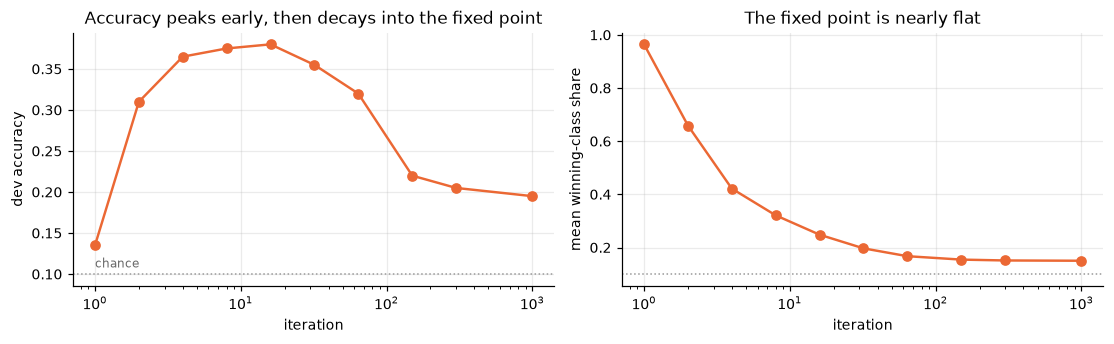


Peak dev accuracy 0.3800 at iteration 16; at the fixed point it is 0.1950.


In [30]:
def fold_seed_indices(fold_index):
    """Graph node indices and labels for one fold's 800 development-train images."""
    train_positions, validation_positions = DEVELOPMENT_SPLITS[fold_index]
    fold_members = OFFICIAL_FOLDS[fold_index]

    seed_nodes = NUM_UNLABELED_IMAGES + fold_members[train_positions]
    seed_labels = train_labels[fold_members[train_positions]]
    validation_nodes = NUM_UNLABELED_IMAGES + fold_members[validation_positions]
    validation_labels = train_labels[fold_members[validation_positions]]
    return seed_nodes, seed_labels, validation_nodes, validation_labels


def _clamp_decay_study(k=15, fold_index=0, checkpoints=(1, 2, 4, 8, 16, 32, 64, 150, 300, 1000)):
    """Accuracy of hard-clamped propagation as a function of iteration count."""
    propagation_matrix, indices, _, _ = build_propagation_matrix(reference_embedding, k)
    propagation_matrix = propagation_matrix.to(DEVICE)

    seed_nodes, seed_labels, validation_nodes, validation_labels = fold_seed_indices(fold_index)
    initial_F = initial_label_matrix(NUM_GRAPH_NODES, NUM_CLASSES, seed_nodes, seed_labels, DEVICE)
    clamp_target = one_hot_matrix(seed_labels, NUM_CLASSES, DEVICE)

    validation_index = torch.as_tensor(validation_nodes, dtype=torch.int64, device=DEVICE)
    truth = torch.as_tensor(validation_labels, dtype=torch.int64, device=DEVICE)

    current_F = initial_F.clone()
    current_F[torch.as_tensor(seed_nodes, dtype=torch.int64, device=DEVICE)] = clamp_target
    seed_index = torch.as_tensor(seed_nodes, dtype=torch.int64, device=DEVICE)

    trace = []
    for iteration in range(1, max(checkpoints) + 1):
        current_F = torch.sparse.mm(propagation_matrix, current_F)
        current_F[seed_index] = clamp_target
        if iteration in checkpoints:
            predictions = current_F[validation_index].argmax(dim=1)
            row_mass = current_F.sum(dim=1)
            confidence = (current_F.max(dim=1).values / (row_mass + 1e-12))
            trace.append({
                "iteration": iteration,
                "accuracy": float((predictions == truth).double().mean().item()),
                "mean_confidence": float(confidence[row_mass > 0].mean().item()),
            })
            print("  iteration %5d   dev accuracy %.4f   mean confidence %.4f"
                  % (iteration, trace[-1]["accuracy"], trace[-1]["mean_confidence"]))
    return trace


CLAMP_DECAY = cached(RUNS_ROOT / "clamp_decay_study.pt", _clamp_decay_study,
                     "hard-clamp decay study")

figure, axes = plt.subplots(1, 2, figsize=(10.2, 3.2))
iterations = [row["iteration"] for row in CLAMP_DECAY]

axes[0].plot(iterations, [r["accuracy"] for r in CLAMP_DECAY], "o-",
             color=COLOR_GENERATIVE, linewidth=1.6)
axes[0].axhline(1.0 / NUM_CLASSES, color="#999", linestyle=":", linewidth=1)
axes[0].annotate("chance", xy=(iterations[0], 1.0 / NUM_CLASSES + 0.008), fontsize=8, color="#666")
axes[0].set_xscale("log"); axes[0].set_xlabel("iteration"); axes[0].set_ylabel("dev accuracy")
axes[0].set_title("Accuracy peaks early, then decays into the fixed point")

axes[1].plot(iterations, [r["mean_confidence"] for r in CLAMP_DECAY], "o-",
             color=COLOR_GENERATIVE, linewidth=1.6)
axes[1].axhline(1.0 / NUM_CLASSES, color="#999", linestyle=":", linewidth=1)
axes[1].set_xscale("log"); axes[1].set_xlabel("iteration")
axes[1].set_ylabel("mean winning-class share")
axes[1].set_title("The fixed point is nearly flat")

figure.tight_layout(); figure.savefig(FIGURES_ROOT / "fig08_clamp_decay.png", bbox_inches="tight")
plt.show()

best = max(CLAMP_DECAY, key=lambda r: r["accuracy"])
print()
print("Peak dev accuracy %.4f at iteration %d; at the fixed point it is %.4f."
      % (best["accuracy"], best["iteration"], CLAMP_DECAY[-1]["accuracy"]))


<div dir="rtl" lang="he" style="text-align: right;">

## 9.2 התיקון: איבר restart

Label spreading מוסיף איבר $(1-\alpha)Y$ שמזריק מחדש את מטריצת ה-seeds בכל צעד. כך הילוך שמתרחק מדי נמשך חזרה לנקודת ההתחלה. נקודת הקבע היא:

</div>

$$F^* = (1-\alpha)(I - \alpha P)^{-1} Y$$

<div dir="rtl" lang="he" style="text-align: right;">

זהו ציון של random walk with restart מוזל, שנשאר מקומי ואינפורמטיבי. הצבה של $\alpha = 1$ מחזירה את הפתרון השטוח המנוון, ולכן $\alpha$ הוא בדיוק הפרמטר שמאזן בין מקומיות לטווח הגעה.

ההשוואה הבאה מוסיפה שורה שלישית לבקרה: **הצבעת cosine פשוטה של 20 השכנים הקרובים ביותר מבין 800 ה-seeds, ללא גרף כלל.** אם מנגנון הגרף אינו עולה עליה, מורכבותו אינה מוצדקת.

</div>


In [31]:
def knn_vote_baseline(embeddings, fold_index, k=20):
    """No graph: classify each validation node by a cosine vote among the 800 seeds."""
    seed_nodes, seed_labels, validation_nodes, validation_labels = fold_seed_indices(fold_index)
    normalized = l2_normalize(embeddings)

    seed_matrix = normalized[torch.as_tensor(seed_nodes, dtype=torch.int64, device=DEVICE)]
    query = normalized[torch.as_tensor(validation_nodes, dtype=torch.int64, device=DEVICE)]

    similarity = query @ seed_matrix.T
    _, nearest = torch.topk(similarity, min(k, seed_matrix.shape[0]), dim=1)
    neighbour_labels = torch.as_tensor(seed_labels, dtype=torch.int64, device=DEVICE)[nearest]

    votes = torch.zeros(len(validation_nodes), NUM_CLASSES, device=DEVICE)
    votes.scatter_add_(1, neighbour_labels, torch.ones_like(neighbour_labels, dtype=votes.dtype))
    predictions = votes.argmax(dim=1).cpu().numpy()
    return float((predictions == validation_labels).mean())


def _method_comparison(k=15, alpha=0.90):
    propagation_matrix, _, _, _ = build_propagation_matrix(reference_embedding, k)
    propagation_matrix = propagation_matrix.to(DEVICE)
    rows = {"clamp": [], "spread": [], "knn_vote": []}
    iteration_counts = {"clamp": [], "spread": []}
    confidences = {"clamp": [], "spread": []}

    for fold_index in range(NUM_FOLDS):
        seed_nodes, seed_labels, validation_nodes, validation_labels = fold_seed_indices(fold_index)
        initial_F = initial_label_matrix(NUM_GRAPH_NODES, NUM_CLASSES, seed_nodes,
                                         seed_labels, DEVICE)
        clamp_target = one_hot_matrix(seed_labels, NUM_CLASSES, DEVICE)
        validation_index = torch.as_tensor(validation_nodes, dtype=torch.int64, device=DEVICE)

        for name, function, kwargs in (
            ("clamp", propagate, {}),
            ("spread", spread, {"alpha": alpha}),
        ):
            F_final, iterations, _ = function(propagation_matrix, initial_F, seed_nodes,
                                              clamp_target, **kwargs)
            predictions = F_final[validation_index].argmax(dim=1).cpu().numpy()
            rows[name].append(float((predictions == validation_labels).mean()))
            iteration_counts[name].append(iterations)
            row_mass = F_final.sum(dim=1)
            confidences[name].append(float(
                (F_final.max(dim=1).values / (row_mass + 1e-12))[row_mass > 0].mean().item()))

        rows["knn_vote"].append(knn_vote_baseline(reference_embedding, fold_index))

    return {"accuracy": rows, "iterations": iteration_counts, "confidence": confidences}


METHOD_COMPARISON = cached(RUNS_ROOT / "method_comparison.pt", _method_comparison,
                           "clamp vs spread vs no-graph baseline")

print("method                      dev accuracy      mean confidence   iterations")
for name, label in (("clamp", "hard clamp"), ("spread", "label spreading, alpha=0.9"),
                    ("knn_vote", "no graph: cosine 20-NN vote")):
    accuracies = np.array(METHOD_COMPARISON["accuracy"][name])
    if name in METHOD_COMPARISON["iterations"]:
        iteration_text = "%d-%d" % (min(METHOD_COMPARISON["iterations"][name]),
                                    max(METHOD_COMPARISON["iterations"][name]))
        confidence_text = "%.3f" % np.mean(METHOD_COMPARISON["confidence"][name])
    else:
        iteration_text, confidence_text = "--", "--"
    print("  %-27s %.4f +/- %.4f   %-15s %s"
          % (label, accuracies.mean(), accuracies.std(ddof=1), confidence_text, iteration_text))

print()
print("Hard clamping performs WORSE than doing nothing clever at all. Everything from here")
print("on uses label spreading; the hard-clamped sweep is kept in section 11 as the")
print("negative result it is.")

[cache hit ] clamp vs spread vs no-graph baseline
method                      dev accuracy      mean confidence   iterations
  hard clamp                  0.2190 +/- 0.0233   0.151           966-998
  label spreading, alpha=0.9  0.4005 +/- 0.0421   0.266           30-40
  no graph: cosine 20-NN vote 0.3790 +/- 0.0291   --              --

Hard clamping performs WORSE than doing nothing clever at all. Everything from here
on uses label spreading; the hard-clamped sweep is kept in section 11 as the
negative result it is.


<div dir="rtl" lang="he" style="text-align: right;">

---

# 10. מדדים וה-probe הלינארי

## כל המדדים נגזרים ממטריצת בלבול אחת

השימוש ב-`sklearn.metrics` אינו מותר, אך אין בו צורך: accuracy, precision, recall ו-F1 אינם ארבעה אלגוריתמים, אלא ארבע דרכים לקרוא אותה טבלת ספירות בגודל $C \times C$. הזוג (אמת, חיזוי) מקודד באופן חד-חד-ערכי כ-`true * C + predicted`, וספירת ההופעות של כל ערך היא בדיוק הפעולה של `torch.bincount`.

שתי מוסכמות של sklearn מועתקות בכוונה משום שהן משנות את התוצאה: `zero_division=0`, כך שמחלקה שלעולם אינה נחזית תורמת 0 לממוצע המאקרו במקום NaN; וכן חיתוך ונרמול מחדש בתוך `log_loss`, שבלעדיהם חיזוי שגוי יחיד ובטוח מדי הופך את כל הממוצע לאינסופי.

</div>


In [32]:
def confusion_matrix(true_labels, predicted_labels, num_classes=NUM_CLASSES):
    """Rows = true, columns = predicted. The one primitive every other metric reads."""
    true_tensor = torch.as_tensor(np.asarray(true_labels), dtype=torch.int64).reshape(-1)
    predicted_tensor = torch.as_tensor(np.asarray(predicted_labels), dtype=torch.int64).reshape(-1)

    if true_tensor.numel() != predicted_tensor.numel():
        raise ValueError("label vectors disagree on length")
    if true_tensor.numel():
        smallest = int(min(true_tensor.min(), predicted_tensor.min()))
        largest = int(max(true_tensor.max(), predicted_tensor.max()))
        if smallest < 0 or largest >= num_classes:
            raise ValueError("labels must lie in [0, %d) -- the -1 sentinel must be filtered "
                             "out before scoring, not folded into class 0" % num_classes)

    flat = torch.bincount(true_tensor * num_classes + predicted_tensor,
                          minlength=num_classes * num_classes)
    return flat.reshape(num_classes, num_classes)


def accuracy_from(confusion):
    counts = confusion.to(torch.float64)
    total = counts.sum()
    return 0.0 if total.item() == 0 else float((torch.diagonal(counts).sum() / total).item())


def per_class_precision_recall_f1(confusion):
    counts = confusion.to(torch.float64)
    true_positives = torch.diagonal(counts)
    predicted_totals, actual_totals = counts.sum(dim=0), counts.sum(dim=1)

    precision = torch.where(predicted_totals > 0,
                            true_positives / torch.clamp(predicted_totals, min=1.0),
                            torch.zeros_like(true_positives))
    recall = torch.where(actual_totals > 0,
                         true_positives / torch.clamp(actual_totals, min=1.0),
                         torch.zeros_like(true_positives))
    denominator = precision + recall
    f1 = torch.where(denominator > 0,
                     2.0 * precision * recall / torch.clamp(denominator, min=1e-300),
                     torch.zeros_like(precision))
    return precision, recall, f1


def macro_f1(confusion):
    return float(per_class_precision_recall_f1(confusion)[2].mean().item())


def macro_precision(confusion):
    return float(per_class_precision_recall_f1(confusion)[0].mean().item())


def cross_entropy_loss(probabilities, labels):
    """Mean negative log-likelihood of the true class -- sklearn's log_loss."""
    probability_tensor = torch.as_tensor(np.asarray(probabilities), dtype=torch.float64)
    label_tensor = torch.as_tensor(np.asarray(labels), dtype=torch.int64).reshape(-1)
    if label_tensor.numel() == 0:
        return 0.0

    epsilon = float(np.finfo(np.float64).eps)
    clipped = torch.clamp(probability_tensor, min=epsilon, max=1.0 - epsilon)
    clipped = clipped / clipped.sum(dim=1, keepdim=True)
    true_class = clipped.gather(1, label_tensor.reshape(-1, 1)).reshape(-1)
    return float((-torch.log(true_class)).mean().item())


def sample_std(values):
    """Sample standard deviation, ddof = 1. Used for every +/- in this notebook."""
    array = np.asarray(values, dtype=np.float64)
    return float(array.std(ddof=1)) if array.size > 1 else float("nan")

<div dir="rtl" lang="he" style="text-align: right;">

## ה-probe מחליף pipeline שלם של sklearn

הערכת הייחוס בשלב ההמשך היא:

</div>

```python
Pipeline([("scaler", StandardScaler()),
          ("classifier", LogisticRegression(C=..., solver="lbfgs", max_iter=5000))])
```

<div dir="rtl" lang="he" style="text-align: right;">

ה-pipeline מותאם בכל fold, עם חיפוש משוכב פנימי בן חמש חלוקות על `C ∈ {0.1, 1, 10, 100}`.

המטרה אינה רק לקבל "מסווג לינארי", אלא למטב את **אותה פונקציית מטרה ובאותה מוסכמת רגולריזציה**, משום שהטענה המרכזית משווה בין שני מרחבי ייצוג. אילו ה-probe שלנו השתמש ברגולריזציה אחרת, הפער בין הזרועות היה עשוי להיות פער בין שני אומדים.

לכן `fit_logistic_regression` ממזערת:

</div>

$$\tfrac{1}{2}\lVert W \rVert_F^2 \;+\; C \sum_i \text{cross-entropy}(x_i W + b,\, y_i)$$

<div dir="rtl" lang="he" style="text-align: right;">

זוהי בדיוק המוסכמה של sklearn. הספרייה אינה מציבה $\lambda$ לפני הקנס; היא מקבעת את הקנס ומכפילה את איבר התאמת הנתונים ב-$C$, ולכן $C$ הוא חוזק רגולריזציה **הפוך**. מימוש מספר לימוד של `mean_CE + lambda * ||W||²` היה נותן מודל שונה לחלוטין עבור אותו ערך מספרי של C.

שימו לב ל-**סכום**, ולא לממוצע, על פני הדוגמאות. שימוש בממוצע היה גורם לרגולריזציה האפקטיבית להיות תלויה במספר הדוגמאות ב-fold. ה-intercept אינו נענש בכוונה; ענישה שלו הייתה קושרת את סף ההחלטה למיקום השרירותי של הראשית.

מאחר שהמחברת משתמשת באותו probe ב-**שתי** הזרועות, החשש הזה נעלם: זהו ממש אותו אומד בשני הצדדים, ולא רק אותה מוסכמה.

## ושוב אותה הערכה באמצעות scikit-learn

דרישת המימוש מאפס חלה על *השיטה* — הגרף, ההעברה, הגזע והמדדים. מסווג לינארי בשלב ההמשך אינו חלק מהשיטה הנחקרת, ולכן אנו מריצים גם את מימוש הייחוס על שתי הזרועות ובאותו פרוטוקול.

גישה זו מספקת יותר מידע מבחירה במימוש אחד. אם המימושים מסכימים, הוכחנו שהמסקנה אינה תלויה בזהות מימוש הרגרסיה הלוגיסטית, וההשוואה לתוצאות SimCLR המקוריות ישירה. אם הם חלוקים, זהו ממצא על ה-probe ולא על המרחבים הלטנטיים, ויש להציגו במקום להסתירו מאחורי בחירה בסעיף 10.

</div>


In [33]:
class Standardizer:
    """Per-feature zero-mean unit-variance rescaling -- our StandardScaler."""

    def __init__(self, zero_variance_threshold=1e-12):
        self.mean = None
        self.standard_deviation = None
        self.zero_variance_threshold = zero_variance_threshold

    def fit(self, features):
        matrix = torch.as_tensor(np.asarray(features), dtype=torch.float64)
        self.mean = matrix.mean(dim=0)
        self.standard_deviation = matrix.std(dim=0, unbiased=False)
        self.standard_deviation = torch.where(
            self.standard_deviation > self.zero_variance_threshold,
            self.standard_deviation, torch.ones_like(self.standard_deviation))
        return self

    def transform(self, features):
        if self.mean is None:
            raise RuntimeError("Standardizer.transform called before fit")
        matrix = torch.as_tensor(np.asarray(features), dtype=torch.float64)
        return (matrix - self.mean.to(matrix.device)) / self.standard_deviation.to(matrix.device)


def fit_logistic_regression(features, labels, C, max_iterations=LINEAR_MAX_ITERATIONS,
                            num_classes=NUM_CLASSES, tolerance=LINEAR_TOLERANCE):
    """Multinomial logistic regression fitted with L-BFGS. Returns (W, b)."""
    matrix = torch.as_tensor(np.asarray(features), dtype=torch.float64)
    label_vector = torch.as_tensor(np.asarray(labels), dtype=torch.int64).reshape(-1)

    weights = torch.zeros(matrix.shape[1], num_classes, dtype=torch.float64, requires_grad=True)
    bias = torch.zeros(num_classes, dtype=torch.float64, requires_grad=True)
    strength = float(C)

    optimizer = torch.optim.LBFGS(
        [weights, bias], lr=1.0, max_iter=max_iterations,
        tolerance_grad=tolerance * strength,
        tolerance_change=1e-9, history_size=10, line_search_fn="strong_wolfe",
    )

    def objective():
        optimizer.zero_grad(set_to_none=True)
        logits = matrix @ weights + bias
        data_fit = F.cross_entropy(logits, label_vector, reduction="sum")
        loss = 0.5 * (weights * weights).sum() + strength * data_fit
        loss.backward()
        return loss

    optimizer.step(objective)
    return weights.detach(), bias.detach()


def predict_proba(features, W, b):
    matrix = torch.as_tensor(np.asarray(features), dtype=torch.float64)
    return torch.softmax(matrix @ W + b, dim=1)


def stratified_k_fold(labels, num_splits=CROSS_VALIDATION_SPLITS, seed=SEED):
    """Hand-rolled StratifiedKFold. Deals each class round-robin into the k splits."""
    label_array = np.asarray(labels).reshape(-1)
    generator = np.random.default_rng(seed)
    per_split = [[] for _ in range(num_splits)]
    rotation = 0

    for class_id in np.unique(label_array):
        shuffled = generator.permutation(np.flatnonzero(label_array == class_id))
        assignment = (np.arange(len(shuffled)) + rotation) % num_splits
        for split_index in range(num_splits):
            per_split[split_index].append(shuffled[assignment == split_index])
        rotation = (rotation + len(shuffled)) % num_splits

    all_positions = np.arange(label_array.shape[0], dtype=np.int64)
    splits = []
    for split_index in range(num_splits):
        validation = np.sort(np.concatenate(per_split[split_index])).astype(np.int64)
        held_out = np.zeros(label_array.shape[0], dtype=bool)
        held_out[validation] = True
        splits.append((all_positions[~held_out], validation))
    return splits


def cross_validate_c(features, labels, c_grid=LINEAR_C_GRID, num_splits=CROSS_VALIDATION_SPLITS,
                     seed=SEED):
    """Inner C search over the development-train features only."""
    matrix = torch.as_tensor(np.asarray(features), dtype=torch.float64)
    label_vector = np.asarray(labels).reshape(-1)
    splits = stratified_k_fold(label_vector, num_splits, seed)

    rows = []
    for c_value in c_grid:
        accuracies, f1_scores, log_losses = [], [], []
        for train_positions, validation_positions in splits:
            standardizer = Standardizer().fit(matrix[train_positions])
            weights, bias = fit_logistic_regression(
                standardizer.transform(matrix[train_positions]),
                label_vector[train_positions], C=c_value)
            probabilities = predict_proba(
                standardizer.transform(matrix[validation_positions]), weights, bias)
            truth = label_vector[validation_positions]
            confusion = confusion_matrix(truth, probabilities.argmax(dim=1))
            accuracies.append(accuracy_from(confusion))
            f1_scores.append(macro_f1(confusion))
            log_losses.append(cross_entropy_loss(probabilities, truth))
        rows.append({"c": float(c_value), "log_loss_mean": float(np.mean(log_losses)),
                     "accuracy_mean": float(np.mean(accuracies)),
                     "f1_macro_mean": float(np.mean(f1_scores))})
    return rows


def select_best_c(rows):
    """Rank by log loss ASCENDING first, then accuracy, then macro-F1, then C."""
    if not rows:
        raise ValueError("cannot select a C from an empty result list")
    return float(min(rows, key=lambda r: (r["log_loss_mean"], -r["accuracy_mean"],
                                          -r["f1_macro_mean"], r["c"]))["c"])


try:
    from sklearn.linear_model import LogisticRegression as ReferenceLogisticRegression
    from sklearn.preprocessing import StandardScaler as ReferenceStandardScaler
    SKLEARN_PROBE_AVAILABLE = True
except ImportError:
    SKLEARN_PROBE_AVAILABLE = False


def fit_reference_probe(train_features, train_labels_, C):
    """scikit-learn's StandardScaler + LogisticRegression, the reference pipeline."""
    if not SKLEARN_PROBE_AVAILABLE:
        raise RuntimeError("scikit-learn is not installed")
    scaler = ReferenceStandardScaler().fit(train_features)
    model = ReferenceLogisticRegression(
        C=C, solver="lbfgs", max_iter=LINEAR_MAX_ITERATIONS).fit(
        scaler.transform(train_features), train_labels_)

    def predict(features):
        seen = np.asarray(model.predict_proba(scaler.transform(features)))
        full = np.zeros((seen.shape[0], NUM_CLASSES), dtype=np.float64)
        full[:, model.classes_.astype(np.int64)] = seen
        return full

    return predict


def fit_hand_written_probe(train_features, train_labels_, C):
    """Our probe, wrapped in the same interface as `fit_reference_probe`."""
    standardizer = Standardizer().fit(train_features)
    weights, bias = fit_logistic_regression(
        standardizer.transform(train_features), train_labels_, C=C)
    return lambda features: predict_proba(
        standardizer.transform(features), weights, bias).numpy()


PROBE_BACKENDS = {"hand_written": fit_hand_written_probe}
if SKLEARN_PROBE_AVAILABLE:
    PROBE_BACKENDS["sklearn"] = fit_reference_probe
else:
    print("scikit-learn is not installed; only the hand-written probe will be reported.")


def probe_development_accuracy(embeddings, fold_index, c_value=None):
    """Fit the probe on a fold's 800 and score its 200. Returns a metrics dict."""
    features = embeddings.to(torch.float32).numpy()
    seed_nodes, seed_labels, validation_nodes, validation_labels = fold_seed_indices(fold_index)

    train_features = features[seed_nodes]
    validation_features = features[validation_nodes]

    if c_value is None:
        rows = cross_validate_c(train_features, seed_labels)
        c_value = select_best_c(rows)
    else:
        rows = None

    standardizer = Standardizer().fit(train_features)
    weights, bias = fit_logistic_regression(
        standardizer.transform(train_features), seed_labels, C=c_value)
    probabilities = predict_proba(standardizer.transform(validation_features), weights, bias)
    confusion = confusion_matrix(validation_labels, probabilities.argmax(dim=1))

    return {"accuracy": accuracy_from(confusion), "f1_macro": macro_f1(confusion),
            "log_loss": cross_entropy_loss(probabilities, validation_labels),
            "c": float(c_value), "cv_rows": rows}


<div dir="rtl" lang="he" style="text-align: right;">

---

# 11. בחירת hyperparameters

כל מה שמופיע להלן מדורג על **200 תמונות development-validation המוחזקות בצד** בכל fold. חלוקת ה-test אינה נקראת. בסוף הסעיף הערכים שנבחרו נכתבים ל-`results/selection.json` ונחתמים ב-hash; סעיף 12 אינו רץ ללא הקובץ.

נבחרים ארבעה דברים:

1. **מדיניות האוגמנטציה** של הזרוע הקונטרסטיבית,
2. **β** של הזרוע הגנרטיבית,
3. **K** ו-**α** עבור הגרף וההעברה,
4. ערך **C** גלובלי אחד ל-probe, המשותף לשתי הזרועות.

</div>


In [34]:
POLICY_ABLATION = {}
for policy_name, run in SIMCLR_RUNS.items():
    summary = run["best_summary"]
    if summary is None:
        raise RuntimeError(
            "Policy %s has no checkpoint probe result; run through epoch 50 or later."
            % policy_name
        )
    POLICY_ABLATION[policy_name] = {
        "epoch": int(run["best_epoch"]),
        "c": float(summary["selected_c"]),
        "accuracy": list(summary["fold_accuracy"]),
        "f1_macro": list(summary["fold_f1_macro"]),
        "log_loss": list(summary["fold_log_loss"]),
        "c_search_summary": list(summary["c_search_summary"]),
    }

SELECTED_POLICY = None
selected_policy_summary = None
for policy_name in SIMCLR_POLICIES:
    candidate_summary = SIMCLR_RUNS[policy_name]["best_summary"]
    if is_better_checkpoint(candidate_summary, selected_policy_summary):
        SELECTED_POLICY = policy_name
        selected_policy_summary = candidate_summary

ranked_policies = sorted(
    POLICY_ABLATION.items(),
    key=lambda item: (
        np.mean(item[1]["log_loss"]),
        -np.mean(item[1]["accuracy"]),
        -np.mean(item[1]["f1_macro"]),
        item[1]["c"],
    ),
)

print()
print("  policy               epoch   dev accuracy       log loss   C       selected")
for policy_name, result in ranked_policies:
    print("  %-20s %5d   %.4f +/- %.4f   %.4f   %-7g %s"
          % (policy_name, result["epoch"], np.mean(result["accuracy"]),
             sample_std(result["accuracy"]), np.mean(result["log_loss"]), result["c"],
             "<--" if policy_name == SELECTED_POLICY else ""))



  policy               epoch   dev accuracy       log loss   C       selected
  P4_full_policy         100   0.7820 +/- 0.0255   0.6387   0.1     <--
  P1_crop_color          100   0.6955 +/- 0.0263   0.9321   0.1     
  P3_crop_flip_color     100   0.6960 +/- 0.0232   0.9534   0.1     
  P2_crop_color_blur     100   0.6810 +/- 0.0477   0.9674   0.1     


paired per-fold contrasts
  P4 - P3   +0.0860  (paired sd 0.0185)  wins 10/10   isolates: grayscale + blur
  P4 - P1   +0.0865  (paired sd 0.0214)  wins 10/10   isolates: flip + grayscale + blur
  P1 - P2   +0.0145  (paired sd 0.0317)  wins 7/10   isolates: blur alone
  P3 - P1   +0.0005  (paired sd 0.0211)  wins 4/10   isolates: flip alone


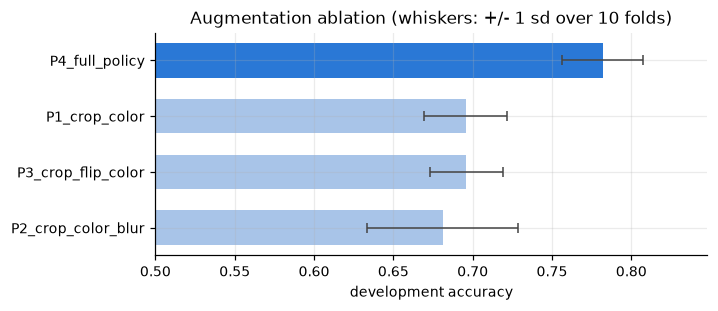

In [35]:
def paired_contrast(policy_a, policy_b):
    a = np.array(POLICY_ABLATION[policy_a]["accuracy"])
    b = np.array(POLICY_ABLATION[policy_b]["accuracy"])
    difference = a - b
    return {"mean": float(difference.mean()), "std": sample_std(difference),
            "wins": int((difference > 0).sum()), "folds": len(difference)}


print("paired per-fold contrasts")
for label, a, b, isolates in (
    ("P4 - P3", "P4_full_policy", "P3_crop_flip_color", "grayscale + blur"),
    ("P4 - P1", "P4_full_policy", "P1_crop_color", "flip + grayscale + blur"),
    ("P1 - P2", "P1_crop_color", "P2_crop_color_blur", "blur alone"),
    ("P3 - P1", "P3_crop_flip_color", "P1_crop_color", "flip alone"),
):
    contrast = paired_contrast(a, b)
    print("  %-9s %+.4f  (paired sd %.4f)  wins %d/%d   isolates: %s"
          % (label, contrast["mean"], contrast["std"], contrast["wins"],
             contrast["folds"], isolates))

figure, axis = plt.subplots(figsize=(6.6, 2.9))
names = [name for name, _ in ranked_policies][::-1]
means = [np.mean(POLICY_ABLATION[n]["accuracy"]) for n in names]
errors = [sample_std(POLICY_ABLATION[n]["accuracy"]) for n in names]
colors = [COLOR_CONTRASTIVE if n == SELECTED_POLICY else "#a8c4e8" for n in names]
axis.barh(names, means, xerr=errors, color=colors, height=0.62,
          error_kw={"ecolor": "#444", "capsize": 3, "elinewidth": 1})
axis.set_xlabel("development accuracy"); axis.set_xlim(0.5, None)
axis.set_title("Augmentation ablation (whiskers: +/- 1 sd over 10 folds)")
figure.tight_layout(); figure.savefig(FIGURES_ROOT / "fig09_policy_ablation.png",
                                      bbox_inches="tight")
plt.show()

<div dir="rtl" lang="he" style="text-align: right;">

## 11.1 P1 כקו הבסיס ב-development

P1 הוא קו בסיס לדיווח, ולא מנצח שהוכרז מראש. כל מדיניות תורמת את ה-checkpoint הטוב ביותר שלה ב-development ואת ה-C שלה שקובע באותו checkpoint. לאחר מכן P2, ‏P3 ו-P4 מושווים ל-P1 על אותם עשרה folds רשמיים של ה-development. בסעיף זה אין גישה לאף ייצוג test ולאף תווית test.

</div>


In [36]:
P1_BASELINE_POLICY = "P1_crop_color"
P1_COMPARISON_POLICIES = (
    "P2_crop_color_blur",
    "P3_crop_flip_color",
    "P4_full_policy",
)

POLICY_REPORT_ROLES = {
    "P1_crop_color": "BASELINE",
    "P2_crop_color_blur": "blur change",
    "P3_crop_flip_color": "flip change",
    "P4_full_policy": "full policy",
}

def policy_configuration_row(policy_name):
    policy = SIMCLR_POLICIES[policy_name]
    order = ["crop"]
    if policy["flip"]:
        order.append("flip")
    order.append("color")
    if policy["grayscale"]:
        order.append("gray")
    if policy["blur"]:
        order.append("blur")
    order.append("normalize")
    return {
        "policy": POLICY_SHORT_NAMES[policy_name],
        "role": POLICY_REPORT_ROLES[policy_name],
        "crop": 1.0,
        "flip": SIMCLR_FLIP_PROBABILITY if policy["flip"] else 0.0,
        "color": SIMCLR_JITTER["probability"],
        "grayscale": SIMCLR_GRAYSCALE_PROBABILITY if policy["grayscale"] else 0.0,
        "blur": SIMCLR_BLUR["probability"] if policy["blur"] else 0.0,
        "order": " -> ".join(order),
    }

POLICY_CONFIGURATION_ROWS = [
    policy_configuration_row(policy_name) for policy_name in SIMCLR_POLICIES
]

print("policy configuration (P1 is the reporting baseline)")
print("%-6s %-14s %6s %6s %7s %6s %6s   %s"
      % ("policy", "role", "crop", "flip", "color", "gray", "blur", "order"))
for row in POLICY_CONFIGURATION_ROWS:
    print("%-6s %-14s %6s %6s %7s %6s %6s   %s"
          % (row["policy"], row["role"], *("%.2f" % row[key]
              for key in ("crop", "flip", "color", "grayscale", "blur")),
             row["order"]))

steps_per_epoch = NUM_UNLABELED_IMAGES // BATCH_SIZE

def policy_run_summary(policy_name):
    run = SIMCLR_RUNS[policy_name]
    history = run["history"]
    losses = np.asarray([row["loss"] for row in history], dtype=np.float64)
    epochs = np.asarray([row["epoch"] for row in history], dtype=np.int64)
    minimum_position = int(np.argmin(losses))
    best = run["best_summary"]
    completed = len(history) == EPOCHS and run.get("encoder_state") is not None
    return {
        "policy_name": policy_name,
        "policy": POLICY_SHORT_NAMES[policy_name],
        "run_status": "completed" if completed else "incomplete",
        "epochs_planned": int(EPOCHS),
        "epochs_completed": int(len(history)),
        "optimizer_steps": int(len(history) * steps_per_epoch),
        "checkpoint_available": bool(run.get("encoder_state") is not None),
        "best_epoch": int(run["best_epoch"]),
        "optimizer_steps_to_best": int(run["best_epoch"] * steps_per_epoch),
        "minimum_train_loss": float(losses[minimum_position]),
        "epoch_of_minimum_train_loss": int(epochs[minimum_position]),
        "final_train_loss": float(losses[-1]),
        "best_dev_log_loss": float(best["log_loss_mean"]),
        "best_dev_log_loss_sd": sample_std(best["fold_log_loss"]),
        "best_dev_accuracy": float(best["accuracy_mean"]),
        "best_dev_accuracy_sd": sample_std(best["fold_accuracy"]),
        "best_dev_f1_macro": float(best["f1_macro_mean"]),
        "best_dev_f1_macro_sd": sample_std(best["fold_f1_macro"]),
        "selected_c": float(best["selected_c"]),
    }

P1_RUN_SUMMARY = {name: policy_run_summary(name) for name in SIMCLR_POLICIES}

print()
print("run and best-development-checkpoint summary")
print("%-6s %-10s %7s %7s %7s %9s %10s %10s %9s %8s"
      % ("policy", "status", "epochs", "steps", "best", "C",
         "dev loss", "dev acc", "dev F1", "final L"))
for policy_name in SIMCLR_POLICIES:
    row = P1_RUN_SUMMARY[policy_name]
    print("%-6s %-10s %7d %7d %7d %9g %10.4f %10.4f %9.4f %8.4f"
          % (row["policy"], row["run_status"], row["epochs_completed"],
             row["optimizer_steps"], row["best_epoch"], row["selected_c"],
             row["best_dev_log_loss"], row["best_dev_accuracy"],
             row["best_dev_f1_macro"], row["final_train_loss"]))

print()
print("best development metrics (mean +/- sample SD across ten folds)")
print("%-6s %20s %20s %20s" % ("policy", "log-loss", "accuracy", "macro-F1"))
for policy_name in SIMCLR_POLICIES:
    row = P1_RUN_SUMMARY[policy_name]
    print("%-6s %8.4f +/- %-7.4f %8.4f +/- %-7.4f %8.4f +/- %-7.4f"
          % (row["policy"], row["best_dev_log_loss"], row["best_dev_log_loss_sd"],
             row["best_dev_accuracy"], row["best_dev_accuracy_sd"],
             row["best_dev_f1_macro"], row["best_dev_f1_macro_sd"]))


policy configuration (P1 is the reporting baseline)
policy role             crop   flip   color   gray   blur   order
P1     BASELINE         1.00   0.00    0.80   0.00   0.00   crop -> color -> normalize
P2     blur change      1.00   0.00    0.80   0.00   0.50   crop -> color -> blur -> normalize
P3     flip change      1.00   0.50    0.80   0.00   0.00   crop -> flip -> color -> normalize
P4     full policy      1.00   0.50    0.80   0.20   0.50   crop -> flip -> color -> gray -> blur -> normalize

run and best-development-checkpoint summary
policy status      epochs   steps    best         C   dev loss    dev acc    dev F1  final L
P1     completed      100   39000     100       0.1     0.9321     0.6955    0.6951   1.8016
P2     completed      100   39000     100       0.1     0.9674     0.6810    0.6806   1.8516
P3     completed      100   39000     100       0.1     0.9534     0.6960    0.6948   1.8140
P4     completed      100   39000     100       0.1     0.6387     0.7820    

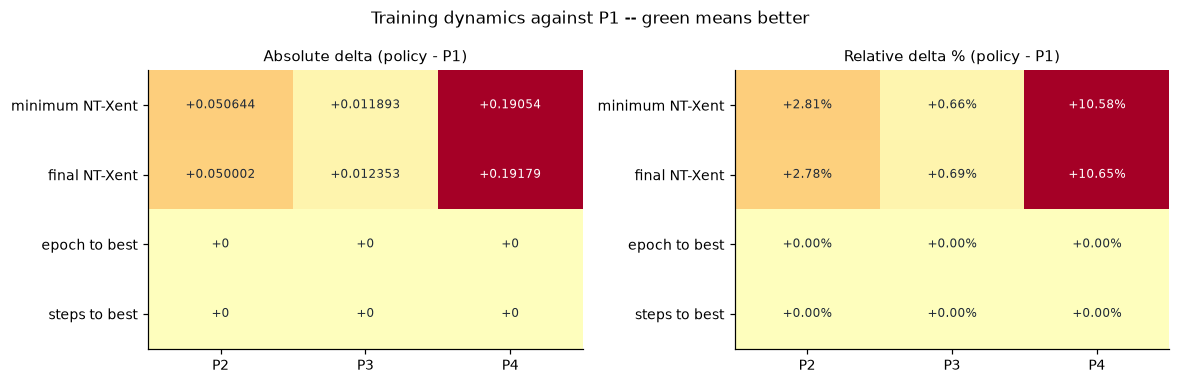

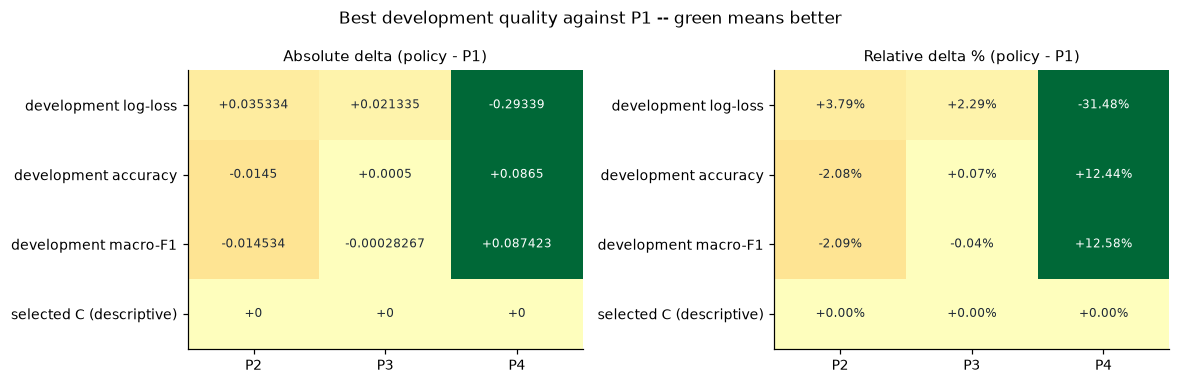

paired best-checkpoint deltas against P1 -- official development folds
policy metric       mean delta    paired sd     wins
P2     log_loss       +0.03533      0.07691    4/10
P2     accuracy       -0.01450      0.03166    2/10
P2     f1_macro       -0.01453      0.03051    3/10
P3     log_loss       +0.02133      0.02812    3/10
P3     accuracy       +0.00050      0.02114    4/10
P3     f1_macro       -0.00028      0.02089    6/10
P4     log_loss       -0.29339      0.04842   10/10
P4     accuracy       +0.08650      0.02135   10/10
P4     f1_macro       +0.08742      0.02287   10/10


In [37]:
def delta_rows_against_p1(metric_specs):
    baseline = P1_RUN_SUMMARY[P1_BASELINE_POLICY]
    rows = []
    for key, label, direction in metric_specs:
        baseline_value = float(baseline[key])
        row = {"metric": key, "label": label, "direction": int(direction),
               "p1_value": baseline_value}
        for policy_name in P1_COMPARISON_POLICIES:
            value = float(P1_RUN_SUMMARY[policy_name][key])
            absolute = value - baseline_value
            relative = 100.0 * absolute / max(abs(baseline_value), 1e-12)
            short = POLICY_SHORT_NAMES[policy_name].lower()
            row[short + "_value"] = value
            row[short + "_absolute_delta"] = absolute
            row[short + "_relative_delta_percent"] = relative
        rows.append(row)
    return rows

TRAINING_DELTA_SPECS = (
    ("minimum_train_loss", "minimum NT-Xent", -1),
    ("final_train_loss", "final NT-Xent", -1),
    ("best_epoch", "epoch to best", -1),
    ("optimizer_steps_to_best", "steps to best", -1),
)
QUALITY_DELTA_SPECS = (
    ("best_dev_log_loss", "development log-loss", -1),
    ("best_dev_accuracy", "development accuracy", 1),
    ("best_dev_f1_macro", "development macro-F1", 1),
    ("selected_c", "selected C (descriptive)", 0),
)

P1_TRAINING_DELTAS = delta_rows_against_p1(TRAINING_DELTA_SPECS)
P1_QUALITY_DELTAS = delta_rows_against_p1(QUALITY_DELTA_SPECS)

def delta_matrix(rows, suffix):
    columns = [POLICY_SHORT_NAMES[name] for name in P1_COMPARISON_POLICIES]
    matrix = np.asarray([[row[column.lower() + suffix] for column in columns]
                         for row in rows], dtype=np.float64)
    return columns, matrix

def draw_delta_heatmap(axis, rows, suffix, title, percent=False):
    columns, raw = delta_matrix(rows, suffix)
    directions = np.asarray([row["direction"] for row in rows], dtype=np.float64)[:, None]
    desirable = raw * directions
    row_scale = np.maximum(np.max(np.abs(desirable), axis=1, keepdims=True), 1e-12)
    colors = desirable / row_scale
    image = axis.imshow(colors, cmap="RdYlGn", vmin=-1.0, vmax=1.0, aspect="auto")
    axis.set_xticks(range(len(columns))); axis.set_xticklabels(columns)
    axis.set_yticks(range(len(rows))); axis.set_yticklabels([row["label"] for row in rows])
    axis.set_title(title, fontsize=10)
    axis.grid(False)
    for row_index in range(raw.shape[0]):
        for column_index in range(raw.shape[1]):
            value = raw[row_index, column_index]
            label = ("%+.2f%%" % value) if percent else ("%+.5g" % value)
            text_color = "white" if abs(colors[row_index, column_index]) > 0.65 else "#1f2937"
            axis.text(column_index, row_index, label, ha="center", va="center",
                      color=text_color, fontsize=8)
    return image

for rows, stem, heading in (
    (P1_TRAINING_DELTAS, "training", "Training dynamics against P1"),
    (P1_QUALITY_DELTAS, "quality", "Best development quality against P1"),
):
    figure, axes = plt.subplots(1, 2, figsize=(10.8, 3.5))
    draw_delta_heatmap(axes[0], rows, "_absolute_delta",
                       "Absolute delta (policy - P1)")
    draw_delta_heatmap(axes[1], rows, "_relative_delta_percent",
                       "Relative delta % (policy - P1)", percent=True)
    figure.suptitle(heading + " -- green means better", fontsize=11)
    figure.tight_layout()
    figure.savefig(FIGURES_ROOT / ("fig09_%s_delta_vs_p1.png" % stem),
                   bbox_inches="tight")
    plt.show()

def paired_metric_against_p1(policy_name, value_key, direction):
    candidate = np.asarray(POLICY_ABLATION[policy_name][value_key], dtype=np.float64)
    baseline = np.asarray(POLICY_ABLATION[P1_BASELINE_POLICY][value_key], dtype=np.float64)
    raw_difference = candidate - baseline
    return {
        "policy": POLICY_SHORT_NAMES[policy_name],
        "metric": value_key,
        "mean_delta": float(raw_difference.mean()),
        "sd_delta": sample_std(raw_difference),
        "wins": int((raw_difference * direction > 0).sum()),
        "folds": int(raw_difference.size),
    }

P1_PAIRED_DELTAS = []
for policy_name in P1_COMPARISON_POLICIES:
    for value_key, direction in (("log_loss", -1), ("accuracy", 1), ("f1_macro", 1)):
        P1_PAIRED_DELTAS.append(
            paired_metric_against_p1(policy_name, value_key, direction))

print("paired best-checkpoint deltas against P1 -- official development folds")
print("%-6s %-10s %12s %12s %8s"
      % ("policy", "metric", "mean delta", "paired sd", "wins"))
for row in P1_PAIRED_DELTAS:
    print("%-6s %-10s %+12.5f %12.5f %4d/%d"
          % (row["policy"], row["metric"], row["mean_delta"],
             row["sd_delta"], row["wins"], row["folds"]))


<div dir="rtl" lang="he" style="text-align: right;">

## 11.2 הפרשים לפי מחלקה ב-development ביחס ל-P1

הסיכומים התקופתיים אינם שומרים מטריצות בלבול. לכן תא זה מתאים מחדש רק את ה-probe הלוגיסטי המוקפא, ב-checkpoint הטוב ביותר וב-C שכבר קובעו עבור כל מדיניות. הוא משתמש באותן חלוקות 800/200 בתוך עשרת ה-folds הרשמיים של ה-development. ‏SimCLR אינו מאומן מחדש, וחלוקת ה-test אינה נקראת.

</div>


[building  ] best-checkpoint development confusions, P1_crop_color


[done      ] best-checkpoint development confusions, P1_crop_color in 4s
[building  ] best-checkpoint development confusions, P2_crop_color_blur


[done      ] best-checkpoint development confusions, P2_crop_color_blur in 3s
[building  ] best-checkpoint development confusions, P3_crop_flip_color


[done      ] best-checkpoint development confusions, P3_crop_flip_color in 4s
[building  ] best-checkpoint development confusions, P4_full_policy


[done      ] best-checkpoint development confusions, P4_full_policy in 4s


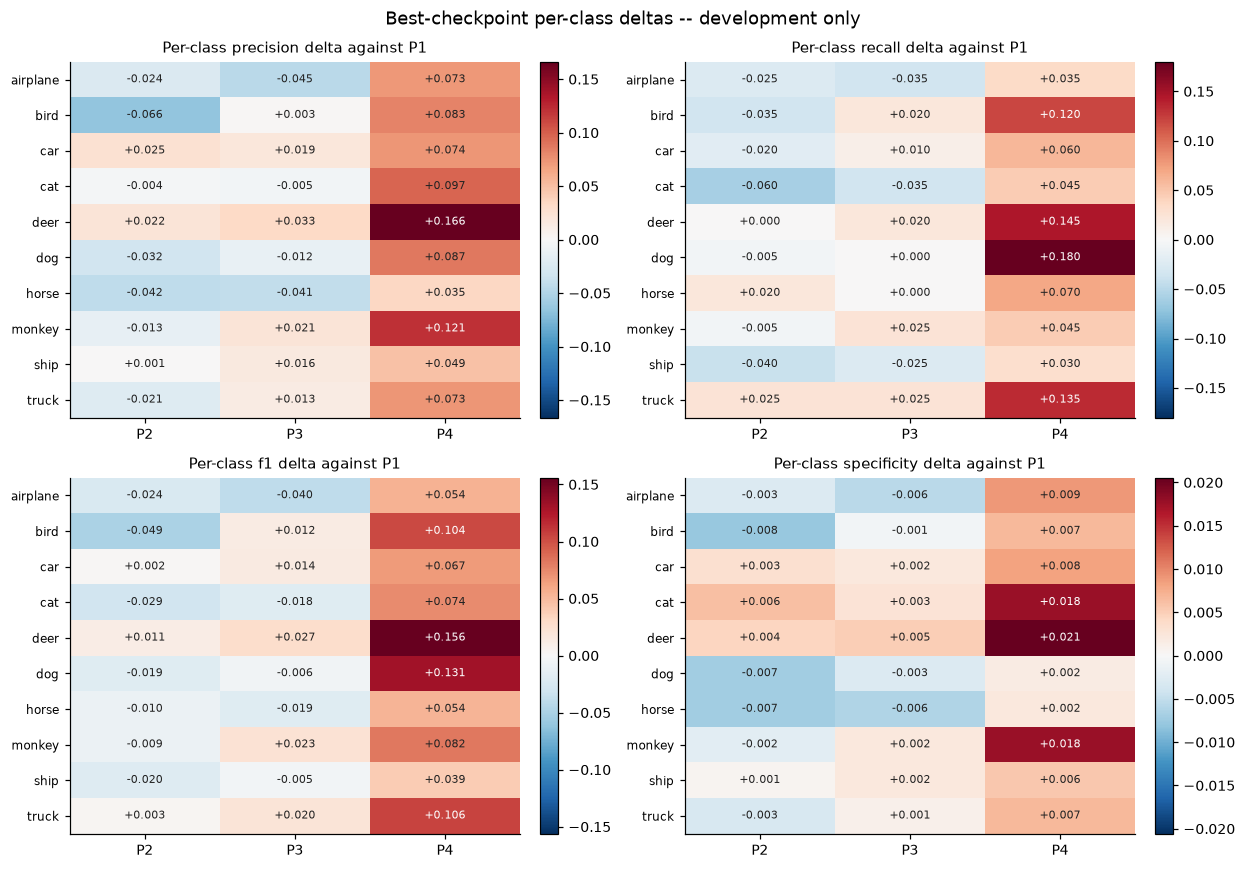

In [38]:
def development_confusions_for_policy(policy_name):
    run = SIMCLR_RUNS[policy_name]
    encoder = SEResNetEncoder().to(DEVICE)
    encoder.load_state_dict(run["encoder_state"])
    features = extract_labeled_probe_features(encoder)
    del encoder
    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()

    selected_c = float(run["best_summary"]["selected_c"])
    fold_confusions = []
    for fold_index, official_indices in enumerate(OFFICIAL_FOLDS):
        train_positions, validation_positions = DEVELOPMENT_SPLITS[fold_index]
        fold_features = features[official_indices]
        fold_labels = train_labels[official_indices]

        standardizer = CheckpointStandardizer().fit(fold_features[train_positions])
        train_features = standardizer.transform(fold_features[train_positions])
        validation_features = standardizer.transform(fold_features[validation_positions])
        weights, bias = fit_checkpoint_logistic(
            train_features, fold_labels[train_positions], selected_c)
        probabilities = checkpoint_predict_proba(
            validation_features, weights, bias)
        confusion = confusion_matrix(
            fold_labels[validation_positions], probabilities.argmax(dim=1))
        fold_confusions.append(confusion.numpy())

    return {
        "policy": policy_name,
        "epoch": int(run["best_epoch"]),
        "c": selected_c,
        "fold_confusions": fold_confusions,
        "summed_confusion": np.sum(fold_confusions, axis=0),
        "split": "official development folds, stratified 800/200",
        "test_used": False,
    }

P1_DEVELOPMENT_CONFUSIONS = {}
for policy_name in SIMCLR_POLICIES:
    run = SIMCLR_RUNS[policy_name]
    cache_c = ("%g" % float(run["best_summary"]["selected_c"])).replace(".", "p")
    P1_DEVELOPMENT_CONFUSIONS[policy_name] = cached(
        RUNS_ROOT / ("policy_dev_confusions_selftv_exactlogic_manual_%s_e%d_c%s_seed%d.pt"
                     % (policy_name, run["best_epoch"], cache_c, SEED)),
        lambda name=policy_name: development_confusions_for_policy(name),
        "best-checkpoint development confusions, %s" % policy_name,
    )

def per_class_metrics_with_specificity(confusion):
    counts = torch.as_tensor(confusion, dtype=torch.float64)
    precision, recall, f1 = per_class_precision_recall_f1(counts)
    true_positive = torch.diagonal(counts)
    false_positive = counts.sum(dim=0) - true_positive
    false_negative = counts.sum(dim=1) - true_positive
    true_negative = counts.sum() - true_positive - false_positive - false_negative
    specificity = torch.where(
        true_negative + false_positive > 0,
        true_negative / torch.clamp(true_negative + false_positive, min=1.0),
        torch.zeros_like(true_negative),
    )
    return {
        "precision": precision.numpy(),
        "recall": recall.numpy(),
        "f1": f1.numpy(),
        "specificity": specificity.numpy(),
    }

P1_PER_CLASS_METRICS = {
    policy_name: per_class_metrics_with_specificity(
        result["summed_confusion"])
    for policy_name, result in P1_DEVELOPMENT_CONFUSIONS.items()
}

P1_PER_CLASS_DELTA_ROWS = []
baseline_metrics = P1_PER_CLASS_METRICS[P1_BASELINE_POLICY]
for policy_name in P1_COMPARISON_POLICIES:
    for metric_name in ("precision", "recall", "f1", "specificity"):
        values = P1_PER_CLASS_METRICS[policy_name][metric_name]
        baseline_values = baseline_metrics[metric_name]
        for class_id in range(NUM_CLASSES):
            absolute = float(values[class_id] - baseline_values[class_id])
            relative = 100.0 * absolute / max(abs(float(baseline_values[class_id])), 1e-12)
            P1_PER_CLASS_DELTA_ROWS.append({
                "policy": POLICY_SHORT_NAMES[policy_name],
                "metric": metric_name,
                "class_id": int(class_id),
                "class_name": CLASS_NAMES[class_id],
                "p1_value": float(baseline_values[class_id]),
                "policy_value": float(values[class_id]),
                "absolute_delta": absolute,
                "relative_delta_percent": relative,
            })

figure, axes = plt.subplots(2, 2, figsize=(11.4, 8.0))
comparison_labels = [POLICY_SHORT_NAMES[name] for name in P1_COMPARISON_POLICIES]
for axis, metric_name in zip(axes.reshape(-1),
                             ("precision", "recall", "f1", "specificity")):
    matrix = np.column_stack([
        P1_PER_CLASS_METRICS[name][metric_name] - baseline_metrics[metric_name]
        for name in P1_COMPARISON_POLICIES
    ])
    limit = max(float(np.abs(matrix).max()), 1e-6)
    image = axis.imshow(matrix, cmap="RdBu_r", vmin=-limit, vmax=limit, aspect="auto")
    axis.set_xticks(range(len(comparison_labels)))
    axis.set_xticklabels(comparison_labels)
    axis.set_yticks(range(NUM_CLASSES))
    axis.set_yticklabels(CLASS_NAMES, fontsize=8)
    axis.set_title("Per-class %s delta against P1" % metric_name, fontsize=10)
    axis.grid(False)
    for class_id in range(NUM_CLASSES):
        for column_index in range(len(comparison_labels)):
            value = matrix[class_id, column_index]
            text_color = "white" if abs(value) > 0.62 * limit else "#222"
            axis.text(column_index, class_id, "%+.3f" % value,
                      ha="center", va="center", fontsize=7, color=text_color)
    figure.colorbar(image, ax=axis, fraction=0.046, pad=0.04)

figure.suptitle("Best-checkpoint per-class deltas -- development only", fontsize=12)
figure.tight_layout()
figure.savefig(FIGURES_ROOT / "fig09_per_class_delta_vs_p1.png",
               bbox_inches="tight")
plt.show()


<div dir="rtl" lang="he" style="text-align: right;">

## 11.3 קובצי דוח המבוססים על development בלבד

קובצי ה-CSV האלה נכתבים כאן, לפני שער ה-test. הם מכילים את המספרים הגולמיים שמאחורי המסלול, את הפרש ה-P1 ואת הנתונים לפי מחלקה, ואינם דורשים אף תמונת test ואף תוצאת test.

</div>


In [39]:
DEVELOPMENT_ROOT = RESULTS_ROOT / "development"
DEVELOPMENT_ROOT.mkdir(parents=True, exist_ok=True)

def write_development_csv(path, header, rows):
    with open(path, "w", encoding="utf-8", newline="\n") as handle:
        handle.write(",".join(header) + "\n")
        for row in rows:
            handle.write(",".join(("%.8f" % value) if isinstance(value, float) else str(value)
                                  for value in row) + "\n")

write_development_csv(
    DEVELOPMENT_ROOT / "policy_configuration.csv",
    ["policy", "role", "crop_probability", "flip_probability",
     "color_probability", "grayscale_probability", "blur_probability", "order"],
    [[row["policy"], row["role"], row["crop"], row["flip"], row["color"],
      row["grayscale"], row["blur"], row["order"]]
     for row in POLICY_CONFIGURATION_ROWS],
)

write_development_csv(
    DEVELOPMENT_ROOT / "policy_probe_trajectory.csv",
    ["policy", "epoch", "selected_c", "dev_log_loss_mean", "dev_log_loss_sd",
     "dev_accuracy_mean", "dev_accuracy_sd", "dev_f1_macro_mean",
     "dev_f1_macro_sd", "selected_checkpoint"],
    [[POLICY_SHORT_NAMES[policy_name], row["epoch"], row["selected_c"],
      row["log_loss_mean"], sample_std(row["fold_log_loss"]),
      row["accuracy_mean"], sample_std(row["fold_accuracy"]),
      row["f1_macro_mean"], sample_std(row["fold_f1_macro"]),
      int(row["epoch"] == SIMCLR_RUNS[policy_name]["best_epoch"])]
     for policy_name in SIMCLR_POLICIES
     for row in sorted(SIMCLR_RUNS[policy_name]["probe_history"],
                       key=lambda item: item["epoch"])],
)

best_summary_fields = (
    "policy_name", "policy", "run_status", "epochs_planned", "epochs_completed",
    "optimizer_steps", "checkpoint_available", "best_epoch", "optimizer_steps_to_best",
    "minimum_train_loss", "epoch_of_minimum_train_loss", "final_train_loss",
    "best_dev_log_loss", "best_dev_log_loss_sd",
    "best_dev_accuracy", "best_dev_accuracy_sd",
    "best_dev_f1_macro", "best_dev_f1_macro_sd", "selected_c")
write_development_csv(
    DEVELOPMENT_ROOT / "policy_best_summary.csv", list(best_summary_fields),
    [[row[field] for field in best_summary_fields]
     for row in (P1_RUN_SUMMARY[name] for name in SIMCLR_POLICIES)],
)

all_p1_delta_rows = [("training", row) for row in P1_TRAINING_DELTAS] + [
    ("quality", row) for row in P1_QUALITY_DELTAS]
write_development_csv(
    DEVELOPMENT_ROOT / "policy_delta_vs_p1.csv",
    ["group", "metric", "direction", "p1_value",
     "p2_value", "p2_absolute_delta", "p2_relative_delta_percent",
     "p3_value", "p3_absolute_delta", "p3_relative_delta_percent",
     "p4_value", "p4_absolute_delta", "p4_relative_delta_percent"],
    [[group, row["metric"], row["direction"], row["p1_value"],
      row["p2_value"], row["p2_absolute_delta"], row["p2_relative_delta_percent"],
      row["p3_value"], row["p3_absolute_delta"], row["p3_relative_delta_percent"],
      row["p4_value"], row["p4_absolute_delta"], row["p4_relative_delta_percent"]]
     for group, row in all_p1_delta_rows],
)

write_development_csv(
    DEVELOPMENT_ROOT / "policy_paired_fold_delta_vs_p1.csv",
    ["policy", "metric", "mean_delta", "sd_delta", "wins", "folds"],
    [[row["policy"], row["metric"], row["mean_delta"], row["sd_delta"],
      row["wins"], row["folds"]] for row in P1_PAIRED_DELTAS],
)

write_development_csv(
    DEVELOPMENT_ROOT / "policy_per_class_delta_vs_p1.csv",
    ["policy", "class_id", "class_name", "metric", "p1_value",
     "policy_value", "absolute_delta", "relative_delta_percent"],
    [[row["policy"], row["class_id"], row["class_name"], row["metric"],
      row["p1_value"], row["policy_value"], row["absolute_delta"],
      row["relative_delta_percent"]] for row in P1_PER_CLASS_DELTA_ROWS],
)

print("development report files written before the test gate:")
for path in sorted(DEVELOPMENT_ROOT.glob("policy_*.csv")):
    print(" ", path)
print("No test data was read.")


development report files written before the test gate:
  /home/labadmin/lab/Tomer_Karmazin/stl10-ssl-comparison/results/development/policy_ablation.csv
  /home/labadmin/lab/Tomer_Karmazin/stl10-ssl-comparison/results/development/policy_best_summary.csv
  /home/labadmin/lab/Tomer_Karmazin/stl10-ssl-comparison/results/development/policy_configuration.csv
  /home/labadmin/lab/Tomer_Karmazin/stl10-ssl-comparison/results/development/policy_delta_vs_p1.csv
  /home/labadmin/lab/Tomer_Karmazin/stl10-ssl-comparison/results/development/policy_paired_fold_delta_vs_p1.csv
  /home/labadmin/lab/Tomer_Karmazin/stl10-ssl-comparison/results/development/policy_per_class_delta_vs_p1.csv
  /home/labadmin/lab/Tomer_Karmazin/stl10-ssl-comparison/results/development/policy_probe_trajectory.csv
No test data was read.


In [40]:
def _spread_sweep(method="spread"):
    """Sweep beta x K x alpha (or beta x K for hard clamping) on development data."""
    alpha_values = LP_ALPHA_GRID if method == "spread" else (1.0,)
    records = []

    for beta_value, embeddings in VAE_EMBEDDINGS.items():
        for k in K_GRID:
            propagation_matrix, indices, _, sigma = build_propagation_matrix(embeddings, k)
            propagation_matrix = propagation_matrix.to(DEVICE)
            component_ids, _ = connected_components(indices, NUM_GRAPH_NODES)
            purity = edge_purity(indices, np.maximum(GRAPH_LABELS, 0), GRAPH_LABEL_KNOWN)

            for alpha in alpha_values:
                accuracies, coverages, unreachable_counts, iteration_counts = [], [], [], []

                for fold_index in range(NUM_FOLDS):
                    seed_nodes, seed_labels, validation_nodes, validation_labels = \
                        fold_seed_indices(fold_index)
                    initial_F = initial_label_matrix(NUM_GRAPH_NODES, NUM_CLASSES, seed_nodes,
                                                     seed_labels, DEVICE)
                    clamp_target = one_hot_matrix(seed_labels, NUM_CLASSES, DEVICE)

                    if method == "spread":
                        F_final, iterations, _ = spread(propagation_matrix, initial_F,
                                                        seed_nodes, clamp_target, alpha)
                    else:
                        F_final, iterations, _ = propagate(propagation_matrix, initial_F,
                                                           seed_nodes, clamp_target)

                    validation_index = torch.as_tensor(validation_nodes, dtype=torch.int64,
                                                       device=DEVICE)
                    predictions = F_final[validation_index].argmax(dim=1).cpu().numpy()
                    accuracies.append(float((predictions == validation_labels).mean()))

                    labeled_mask = np.zeros(NUM_GRAPH_NODES, dtype=bool)
                    labeled_mask[seed_nodes] = True
                    coverages.append(component_label_coverage(component_ids, labeled_mask))
                    pseudo, _ = pseudo_labels_from(F_final)
                    unreachable_counts.append(int((pseudo < 0).sum().item()))
                    iteration_counts.append(iterations)

                records.append({
                    "beta": beta_value, "k": k, "alpha": alpha, "method": method,
                    "dev_accuracy_mean": float(np.mean(accuracies)),
                    "dev_accuracy_std": sample_std(accuracies),
                    "edge_purity": purity, "sigma": sigma,
                    "component_coverage": float(np.mean(coverages)),
                    "unreachable_mean": float(np.mean(unreachable_counts)),
                    "iterations_mean": float(np.mean(iteration_counts)),
                })
            del propagation_matrix
            if DEVICE.type == "cuda":
                torch.cuda.empty_cache()
        print("  beta=%-6g swept" % beta_value)
    return records


SPREAD_SWEEP = cached(RUNS_ROOT / "sweep_spread.pt", lambda: _spread_sweep("spread"),
                      "label-spreading sweep (beta x K x alpha)")
CLAMP_SWEEP = cached(RUNS_ROOT / "sweep_clamp.pt", lambda: _spread_sweep("clamp"),
                     "hard-clamp sweep (beta x K)")

best_spread = max(SPREAD_SWEEP, key=lambda r: r["dev_accuracy_mean"])
best_clamp = max(CLAMP_SWEEP, key=lambda r: r["dev_accuracy_mean"])

SELECTED_BETA = best_spread["beta"]
SELECTED_K = best_spread["k"]
SELECTED_ALPHA = best_spread["alpha"]

print()
print("best spreading cell : beta=%g K=%d alpha=%.2f -> %.4f +/- %.4f"
      % (SELECTED_BETA, SELECTED_K, SELECTED_ALPHA,
         best_spread["dev_accuracy_mean"], best_spread["dev_accuracy_std"]))
print("best clamping cell  : beta=%g K=%d          -> %.4f +/- %.4f"
      % (best_clamp["beta"], best_clamp["k"],
         best_clamp["dev_accuracy_mean"], best_clamp["dev_accuracy_std"]))

[cache hit ] label-spreading sweep (beta x K x alpha)
[cache hit ] hard-clamp sweep (beta x K)

best spreading cell : beta=0.1 K=20 alpha=0.80 -> 0.4085 +/- 0.0481
best clamping cell  : beta=0.1 K=5          -> 0.2285 +/- 0.0331


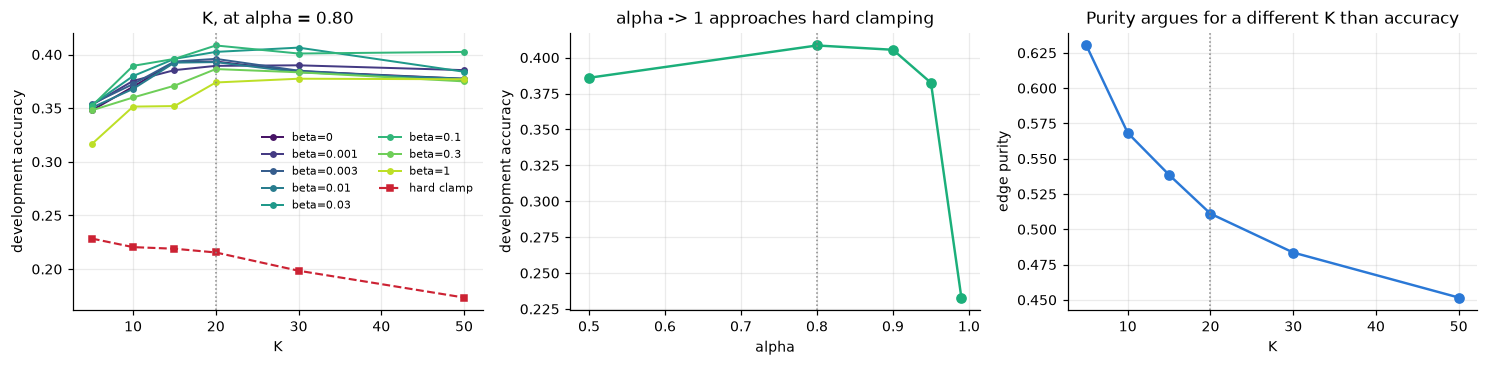

Accuracy selects K=20; edge purity would select K=5.


In [41]:
figure, axes = plt.subplots(1, 3, figsize=(13.6, 3.4))
palette = plt.cm.viridis(np.linspace(0.05, 0.9, len(BETA_GRID)))

for color, beta_value in zip(palette, BETA_GRID):
    slice_rows = sorted([r for r in SPREAD_SWEEP
                         if r["beta"] == beta_value and r["alpha"] == SELECTED_ALPHA],
                        key=lambda r: r["k"])
    axes[0].plot([r["k"] for r in slice_rows], [r["dev_accuracy_mean"] for r in slice_rows],
                 "o-", color=color, label="beta=%g" % beta_value, markersize=3.5, linewidth=1.3)

clamp_rows = sorted([r for r in CLAMP_SWEEP if r["beta"] == SELECTED_BETA], key=lambda r: r["k"])
axes[0].plot([r["k"] for r in clamp_rows], [r["dev_accuracy_mean"] for r in clamp_rows],
             "s--", color="#c23", label="hard clamp", markersize=3.5, linewidth=1.4)
axes[0].axvline(SELECTED_K, color="#888", linestyle=":", linewidth=1)
axes[0].set_xlabel("K"); axes[0].set_ylabel("development accuracy")
axes[0].set_title("K, at alpha = %.2f" % SELECTED_ALPHA)
axes[0].legend(frameon=False, fontsize=7, ncol=2)

alpha_rows = sorted([r for r in SPREAD_SWEEP
                     if r["beta"] == SELECTED_BETA and r["k"] == SELECTED_K],
                    key=lambda r: r["alpha"])
axes[1].plot([r["alpha"] for r in alpha_rows], [r["dev_accuracy_mean"] for r in alpha_rows],
             "o-", color=COLOR_CNN, linewidth=1.6)
axes[1].axvline(SELECTED_ALPHA, color="#888", linestyle=":", linewidth=1)
axes[1].set_xlabel("alpha"); axes[1].set_ylabel("development accuracy")
axes[1].set_title("alpha -> 1 approaches hard clamping")

purity_rows = sorted([r for r in SPREAD_SWEEP
                      if r["beta"] == SELECTED_BETA and r["alpha"] == SELECTED_ALPHA],
                     key=lambda r: r["k"])
axes[2].plot([r["k"] for r in purity_rows], [r["edge_purity"] for r in purity_rows],
             "o-", color=COLOR_CONTRASTIVE, linewidth=1.6)
axes[2].axvline(SELECTED_K, color="#888", linestyle=":", linewidth=1)
axes[2].set_xlabel("K"); axes[2].set_ylabel("edge purity")
axes[2].set_title("Purity argues for a different K than accuracy")

figure.tight_layout(); figure.savefig(FIGURES_ROOT / "fig10_sweeps.png", bbox_inches="tight")
plt.show()

purity_best_k = max(purity_rows, key=lambda r: r["edge_purity"])["k"]
print("Accuracy selects K=%d; edge purity would select K=%d." % (SELECTED_K, purity_best_k))


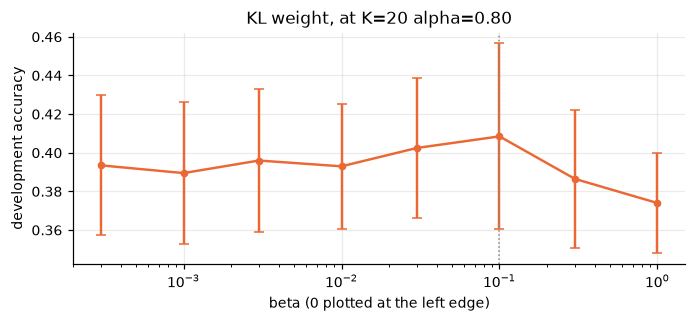

  beta     dev accuracy         edge purity   mean KL at end of training
  0        0.3935 +/- 0.0362     0.4907           2335.81
  0.001    0.3895 +/- 0.0365     0.4930           2335.36
  0.003    0.3960 +/- 0.0371     0.4963           2334.96
  0.01     0.3930 +/- 0.0322     0.4882           2302.56
  0.03     0.4025 +/- 0.0363     0.4997           1921.71
  0.1      0.4085 +/- 0.0481     0.5111           1365.27
  0.3      0.3865 +/- 0.0359     0.4980            716.32
  1        0.3740 +/- 0.0259     0.4566            356.79


In [42]:
beta_rows = sorted([r for r in SPREAD_SWEEP
                    if r["k"] == SELECTED_K and r["alpha"] == SELECTED_ALPHA],
                   key=lambda r: r["beta"])

figure, axis = plt.subplots(figsize=(6.4, 3.0))
axis.errorbar([max(r["beta"], 3e-4) for r in beta_rows],
              [r["dev_accuracy_mean"] for r in beta_rows],
              yerr=[r["dev_accuracy_std"] for r in beta_rows],
              fmt="o-", color=COLOR_GENERATIVE, capsize=3, linewidth=1.6, markersize=4)
axis.axvline(max(SELECTED_BETA, 3e-4), color="#888", linestyle=":", linewidth=1)
axis.set_xscale("log"); axis.set_xlabel("beta (0 plotted at the left edge)")
axis.set_ylabel("development accuracy")
axis.set_title("KL weight, at K=%d alpha=%.2f" % (SELECTED_K, SELECTED_ALPHA))
figure.tight_layout(); figure.savefig(FIGURES_ROOT / "fig11_beta.png", bbox_inches="tight")
plt.show()

print("  beta     dev accuracy         edge purity   mean KL at end of training")
for row in beta_rows:
    print("  %-7g  %.4f +/- %.4f     %.4f        %10.2f"
          % (row["beta"], row["dev_accuracy_mean"], row["dev_accuracy_std"],
             row["edge_purity"], VAE_RUNS[row["beta"]]["history"][-1]["kl"]))


In [43]:
locked_vae_summary = VAE_RUNS[SELECTED_BETA]["best_summary"]
locked_simclr_summary = SIMCLR_RUNS[SELECTED_POLICY]["best_summary"]

C_SELECTION = {
    "vae_c": float(locked_vae_summary["selected_c"]),
    "simclr_c": float(locked_simclr_summary["selected_c"]),
    "vae_aggregate": locked_vae_summary["c_search_summary"],
    "simclr_aggregate": locked_simclr_summary["c_search_summary"],
}

print("generative arm  locked C = %g  at epoch %d"
      % (C_SELECTION["vae_c"], VAE_RUNS[SELECTED_BETA]["best_epoch"]))
print("contrastive arm locked C = %g  at epoch %d"
      % (C_SELECTION["simclr_c"], SIMCLR_RUNS[SELECTED_POLICY]["best_epoch"]))
print()

SELECTION = {
    "selected_policy": SELECTED_POLICY,
    "selected_simclr_epoch": int(SIMCLR_RUNS[SELECTED_POLICY]["best_epoch"]),
    "selected_beta": float(SELECTED_BETA),
    "selected_vae_epoch": int(VAE_RUNS[SELECTED_BETA]["best_epoch"]),
    "selected_k": int(SELECTED_K),
    "selected_alpha": float(SELECTED_ALPHA),
    "selected_lp_method": "spread",
    "vae_c": float(C_SELECTION["vae_c"]),
    "simclr_c": float(C_SELECTION["simclr_c"]),
    "seed": SEED,
    "selection_split": "development",
    "test_seen_during_selection": False,
    "note": ("Both arms select their checkpoint and their C from periodic development "
             "probes under one schedule; the test split was not opened during selection"),
}

SELECTION_PATH = RESULTS_ROOT / "selection.json"
with open(SELECTION_PATH, "w", encoding="utf-8") as handle:
    json.dump(SELECTION, handle, indent=2, sort_keys=True)

SELECTION_HASH = hashlib.sha256(
    json.dumps(SELECTION, sort_keys=True).encode("utf-8")).hexdigest()

print("locked selection written to", SELECTION_PATH)
print(json.dumps(SELECTION, indent=2, sort_keys=True))
print()
print("sha256:", SELECTION_HASH)


generative arm  locked C = 0.1  at epoch 100
contrastive arm locked C = 0.1  at epoch 100

locked selection written to /home/labadmin/lab/Tomer_Karmazin/stl10-ssl-comparison/results/selection.json
{
  "note": "Both arms select their checkpoint and their C from periodic development probes under one schedule; the test split was not opened during selection",
  "seed": 42,
  "selected_alpha": 0.8,
  "selected_beta": 0.1,
  "selected_k": 20,
  "selected_lp_method": "spread",
  "selected_policy": "P4_full_policy",
  "selected_simclr_epoch": 100,
  "selected_vae_epoch": 100,
  "selection_split": "development",
  "simclr_c": 0.1,
  "test_seen_during_selection": false,
  "vae_c": 0.1
}

sha256: dbae40b001aa9b2db43cf064c48d7587a48a33ebbbbd51ba5eea80d227f93dd6


In [44]:
def _c_grid_comparison():
    vae_by_c = {float(row["c"]): row for row in C_SELECTION["vae_aggregate"]}
    simclr_by_c = {float(row["c"]): row for row in C_SELECTION["simclr_aggregate"]}

    print("inner-CV development means, generative beta=%g against contrastive %s at epoch %d"
          % (SELECTED_BETA, SELECTED_POLICY, SELECTION["selected_simclr_epoch"]))
    print()
    print("  %-7s  %-25s  %-25s" % ("", "generative", "contrastive"))
    print("  %-7s  %9s %7s %7s  %9s %7s %7s   %s"
          % ("C", "log loss", "acc", "F1", "log loss", "acc", "F1", "higher accuracy"))

    leaders = []
    for c_value in LINEAR_C_GRID:
        vae_row = vae_by_c[float(c_value)]
        simclr_row = simclr_by_c[float(c_value)]
        leader = ("generative" if vae_row["accuracy_mean"] > simclr_row["accuracy_mean"]
                  else "contrastive")
        leaders.append(leader)

        selected_marks = ""
        if float(c_value) == float(C_SELECTION["vae_c"]):
            selected_marks += "  selected by generative"
        if float(c_value) == float(C_SELECTION["simclr_c"]):
            selected_marks += "  selected by contrastive"

        print("  %-7g  %9.4f %7.4f %7.4f  %9.4f %7.4f %7.4f   %-11s%s"
              % (c_value,
                 vae_row["log_loss_mean"], vae_row["accuracy_mean"], vae_row["f1_macro_mean"],
                 simclr_row["log_loss_mean"], simclr_row["accuracy_mean"],
                 simclr_row["f1_macro_mean"],
                 leader, selected_marks))

    print()
    if len(set(leaders)) == 1:
        print("The same arm leads at all %d values in the grid, so the comparison does not"
              % len(LINEAR_C_GRID))
        print("depend on the regularization strength either arm selected.")
    else:
        print("The arms change places across the grid, so the selected C values are")
        print("load-bearing and the write-up has to say so rather than report one row.")


_c_grid_comparison()


inner-CV development means, generative beta=0.1 against contrastive P4_full_policy at epoch 100

           generative                 contrastive              
  C         log loss     acc      F1   log loss     acc      F1   higher accuracy
  0.1         2.7037  0.3455  0.3476     0.6939  0.7756  0.7753   contrastive  selected by generative  selected by contrastive
  1           4.3216  0.3317  0.3342     1.0818  0.7579  0.7574   contrastive
  10          6.2127  0.3271  0.3295     1.6533  0.7503  0.7500   contrastive
  100         8.2215  0.3239  0.3262     2.3010  0.7432  0.7430   contrastive

The same arm leads at all 4 values in the grid, so the comparison does not
depend on the regularization strength either arm selected.


<div dir="rtl" lang="he" style="text-align: right;">

---

# 12. ה-benchmark על חלוקת ה-test

**זהו הסעיף היחיד שקורא את חלוקת ה-test, והוא רץ פעם אחת.**

הפרוטוקול משקף בדיוק את מימוש הייחוס: מסווג אחד לכל fold רשמי, המאומן על 1,000 התמונות המתויגות של אותו fold ומוערך על כל 8,000 תמונות ה-test. המספר המרכזי הוא הממוצע על פני עשרת ה-folds. כל `±` הוא סטיית התקן המדגמית (ddof = 1) על פני אותם folds.

מתקבלות שלוש שורות:

| שורה | משמעות |
|---|---|
| **קונטרסטיבי + probe לינארי** | ההשוואה המרכזית |
| **גנרטיבי + probe לינארי** | ההשוואה המרכזית |
| גנרטיבי + העברת תוויות → CNN | שאלה שונה וצרה יותר; מדווחת לצד ההשוואה ולא במקומה |

## מדוע שורת ה-CNN מופרדת

ה-CNN מאומן על כ-105,000 pseudo-labels שהועברו בגרף, ויש לו קיבולת גדולה בהרבה מזו של probe לינארי. השוואתו ישירות ל-probe הקונטרסטיבי הייתה מודדת שני דברים יחד: איכות המרחב הלטנטי, שהיא שאלת המחקר, וקיבולת המסווג שמעליו, שהיא גורם מערפל. CNN יכול לנצח בטבלה גם כאשר המרחב הלטנטי שלו גרוע יותר.

</div>


In [45]:
UNLABELED_SENTINEL = -1


def gather_graph_images(positions):
    """uint8 images for graph node indices, returned IN THE ORDER GIVEN."""
    positions = np.asarray(positions)
    output = np.empty((positions.size, NUMBER_OF_CHANNELS, IMAGE_SIZE, IMAGE_SIZE),
                      dtype=np.uint8)

    from_unlabeled = positions < NUM_UNLABELED_IMAGES
    if from_unlabeled.any():
        slots = np.flatnonzero(from_unlabeled)
        nodes = positions[from_unlabeled]
        order = np.argsort(nodes)
        output[slots[order]] = np.asarray(unlabeled_images[nodes[order]])

    if (~from_unlabeled).any():
        slots = np.flatnonzero(~from_unlabeled)
        output[slots] = train_images[positions[~from_unlabeled] - NUM_UNLABELED_IMAGES]

    return output


class PseudoLabelClassifier(nn.Module):
    """The shared trunk plus a linear head, trained on propagated labels."""

    def __init__(self, num_classes=NUM_CLASSES):
        super().__init__()
        self.encoder = SEResNetEncoder()
        initialize_encoder_weights(self.encoder,
                                   output_projection=self.encoder.output_projection)
        self.classification_head = nn.Linear(ENCODER_DIM, num_classes)

    def forward(self, images):
        return self.classification_head(self.encoder(images))


def train_pseudo_label_classifier(pseudo_labels, confidence, encoder_state=None,
                                  epochs=EPOCHS, batch_size=BATCH_SIZE, seed=SEED,
                                  log_every=20):
    """Train a CNN on propagated pseudo-labels over the 105,000 graph nodes."""
    reset_seed(seed)
    label_array = np.asarray(pseudo_labels).reshape(-1)
    usable = np.flatnonzero(label_array != UNLABELED_SENTINEL).astype(np.int64)
    if usable.size == 0:
        raise ValueError("propagation reached no node; there is nothing to train on")

    model = PseudoLabelClassifier().to(DEVICE)
    if encoder_state is not None:
        model.encoder.load_state_dict(encoder_state)
    optimizer = build_optimizer(model)

    label_tensor = torch.as_tensor(label_array[usable], dtype=torch.int64, device=DEVICE)
    weight_tensor = torch.as_tensor(np.asarray(confidence).reshape(-1)[usable],
                                    dtype=torch.float32, device=DEVICE)

    steps_per_epoch = max(usable.size // batch_size, 1)
    total_steps = steps_per_epoch * epochs
    warmup_steps = max(steps_per_epoch * WARMUP_EPOCHS, 1)
    generator = seeded_generator(seed)

    history, global_step = [], 0
    for epoch in range(epochs):
        model.train()
        permutation = torch.randperm(usable.size, generator=generator).numpy()
        loss_sum, correct, seen = 0.0, 0, 0

        for step in range(steps_per_epoch):
            slots = permutation[step * batch_size:(step + 1) * batch_size]
            if slots.size == 0:
                continue
            positions = usable[slots]

            set_learning_rate(optimizer,
                              learning_rate_at_step(global_step, total_steps, warmup_steps))

            batch_images = normalize_batch(gather_graph_images(positions))
            slot_tensor = torch.as_tensor(slots, device=DEVICE)
            batch_labels = label_tensor[slot_tensor]
            batch_weights = weight_tensor[slot_tensor]

            logits = model(batch_images)
            per_sample = F.cross_entropy(logits, batch_labels, reduction="none")
            loss = (per_sample * batch_weights).sum() / torch.clamp(batch_weights.sum(), min=1e-8)

            optimizer.zero_grad(set_to_none=True)
            loss.backward()
            optimizer.step()

            loss_sum += float(loss.item()) * batch_labels.numel()
            correct += int((logits.argmax(dim=1) == batch_labels).sum().item())
            seen += batch_labels.numel()
            global_step += 1

        history.append({"epoch": epoch, "loss": loss_sum / max(seen, 1),
                        "pseudo_label_agreement": correct / max(seen, 1)})
        if epoch % log_every == 0 or epoch == epochs - 1:
            print("    epoch %3d/%d  loss %.4f  agreement with pseudo-labels %.4f"
                  % (epoch + 1, epochs, history[-1]["loss"],
                     history[-1]["pseudo_label_agreement"]))

    return {"state": {k: v.cpu() for k, v in model.state_dict().items()}, "history": history}


@torch.inference_mode()
def classifier_test_probabilities(state, batch_size=FEATURE_BATCH_SIZE):
    model = PseudoLabelClassifier().to(DEVICE)
    model.load_state_dict(state)
    model.eval()
    batches = []
    for start in range(0, len(test_images), batch_size):
        logits = model(normalize_batch(test_images[start:start + batch_size]))
        batches.append(torch.softmax(logits, dim=1).to(torch.float64).cpu())
    del model
    return torch.cat(batches, dim=0)

In [46]:
CONFIRM_TEST_EVALUATION = True

if not CONFIRM_TEST_EVALUATION:
    raise RuntimeError("The test split is read below. Set CONFIRM_TEST_EVALUATION once the "
                       "selection in section 11 is final.")
if not SELECTION_PATH.exists():
    raise RuntimeError("results/selection.json is missing; run section 11 first.")

print("Reading the test split. Selection hash:", SELECTION_HASH[:16], "...")
print()


def probe_test_fold(embeddings, test_features, fold_index, c_value, backend="hand_written"):
    """Fit the probe on a fold's full 1000 labeled images, score all 8000 test images."""
    features = embeddings.to(torch.float32).numpy()
    fold_members = OFFICIAL_FOLDS[fold_index]
    train_nodes = NUM_UNLABELED_IMAGES + fold_members

    predict = PROBE_BACKENDS[backend](
        features[train_nodes], train_labels[fold_members], c_value)
    probabilities = np.asarray(predict(test_features))
    confusion = confusion_matrix(test_labels, probabilities.argmax(axis=1))
    return {"accuracy": accuracy_from(confusion), "f1_macro": macro_f1(confusion),
            "precision_macro": macro_precision(confusion),
            "log_loss": cross_entropy_loss(probabilities, test_labels),
            "confusion": confusion.numpy()}


@torch.inference_mode()
def extract_test_embeddings(encoder_state, head_state=None, batch_size=FEATURE_BATCH_SIZE):
    encoder = SEResNetEncoder().to(DEVICE)
    encoder.load_state_dict(encoder_state)
    encoder.eval()
    projection = None
    if head_state is not None:
        projection = nn.Linear(ENCODER_DIM, LATENT_DIM).to(DEVICE)
        projection.load_state_dict(head_state)
        projection.eval()

    output = torch.empty(NUM_TEST_IMAGES, ENCODER_DIM, dtype=torch.float32)
    for start in range(0, NUM_TEST_IMAGES, batch_size):
        features = encoder(normalize_batch(test_images[start:start + batch_size]))
        if projection is not None:
            features = projection(features)
        output[start:start + features.shape[0]] = features.float().cpu()
    del encoder, projection
    return output.numpy()


GENERATIVE_TEST_FEATURES = cached(
    RUNS_ROOT / ("test_embeddings_vae_beta%g.pt" % SELECTED_BETA),
    lambda: extract_test_embeddings(VAE_RUNS[SELECTED_BETA]["encoder_state"],
                                    VAE_RUNS[SELECTED_BETA]["head_state"]["to_mu"]),
    "test embeddings, generative arm")
CONTRASTIVE_TEST_FEATURES = cached(
    RUNS_ROOT / ("test_embeddings_simclr_joint2b_probe_selftv_exactlogic_manual_fp32_%s.pt" % SELECTED_POLICY),
    lambda: extract_test_embeddings(SIMCLR_RUNS[SELECTED_POLICY]["encoder_state"]),
    "test embeddings, contrastive arm")


def _test_probe_rows():
    """Both arms, every fold, under every available probe implementation."""
    rows = {}
    for backend in PROBE_BACKENDS:
        rows[backend] = {"contrastive": [], "generative": []}
        for fold_index in range(NUM_FOLDS):
            rows[backend]["contrastive"].append(probe_test_fold(
                SIMCLR_EMBEDDINGS[SELECTED_POLICY], CONTRASTIVE_TEST_FEATURES,
                fold_index, SELECTION["simclr_c"], backend))
            rows[backend]["generative"].append(probe_test_fold(
                VAE_EMBEDDINGS[SELECTED_BETA], GENERATIVE_TEST_FEATURES,
                fold_index, SELECTION["vae_c"], backend))
        print("  %-12s contrastive %.4f   generative %.4f"
              % (backend,
                 np.mean([r["accuracy"] for r in rows[backend]["contrastive"]]),
                 np.mean([r["accuracy"] for r in rows[backend]["generative"]])))
    return rows


TEST_PROBE_ALL = cached(RUNS_ROOT / "test_probe_joint2b_probe_selftv_exactlogic_manual_fp32_locked.pt", _test_probe_rows,
                        "test-split linear probes, both backends")

TEST_PROBE = TEST_PROBE_ALL["hand_written"]

Reading the test split. Selection hash: dbae40b001aa9b2d ...

[cache hit ] test embeddings, generative arm
[building  ] test embeddings, contrastive arm


[done      ] test embeddings, contrastive arm in 1s
[building  ] test-split linear probes, both backends


  hand_written contrastive 0.7933   generative 0.3564


  sklearn      contrastive 0.7933   generative 0.3566
[done      ] test-split linear probes, both backends in 44s


In [47]:
def _test_cnn_rows():
    """Propagate at the locked hyperparameters, train a CNN per fold, score the test split."""
    propagation_matrix, _, _, _ = build_propagation_matrix(
        VAE_EMBEDDINGS[SELECTED_BETA], SELECTED_K)
    propagation_matrix = propagation_matrix.to(DEVICE)
    rows = []

    for fold_index in range(NUM_FOLDS):
        fold_members = OFFICIAL_FOLDS[fold_index]
        seed_nodes = NUM_UNLABELED_IMAGES + fold_members
        seed_labels = train_labels[fold_members]

        initial_F = initial_label_matrix(NUM_GRAPH_NODES, NUM_CLASSES, seed_nodes,
                                         seed_labels, DEVICE)
        clamp_target = one_hot_matrix(seed_labels, NUM_CLASSES, DEVICE)
        F_final, iterations, delta = spread(propagation_matrix, initial_F, seed_nodes,
                                            clamp_target, SELECTED_ALPHA)
        pseudo, confidence = pseudo_labels_from(F_final)

        print("  fold %d: propagation converged in %d iterations (delta %.2e), %d unreachable"
              % (fold_index, iterations, delta, int((pseudo < 0).sum().item())))

        run = cached(
            RUNS_ROOT / ("cnn_fold%d.pt" % fold_index),
            lambda p=pseudo.cpu().numpy(), c=confidence.cpu().numpy():
                train_pseudo_label_classifier(p, c),
            "CNN on pseudo-labels, fold %d" % fold_index)

        probabilities = classifier_test_probabilities(run["state"])
        confusion = confusion_matrix(test_labels, probabilities.argmax(dim=1))
        rows.append({
            "accuracy": accuracy_from(confusion), "f1_macro": macro_f1(confusion),
            "precision_macro": macro_precision(confusion),
            "log_loss": cross_entropy_loss(probabilities, test_labels),
            "confusion": confusion.numpy(),
            "pseudo_label_agreement": run["history"][-1]["pseudo_label_agreement"],
            "train_loss": run["history"][-1]["loss"],
            "unreachable": int((pseudo < 0).sum().item()),
        })
    return rows


TEST_CNN = cached(RUNS_ROOT / "test_cnn.pt", _test_cnn_rows, "test-split CNN rows")

print()
print("mean agreement with its own pseudo-labels: %.4f"
      % np.mean([r["pseudo_label_agreement"] for r in TEST_CNN]))
print("mean training cross-entropy               : %.6f"
      % np.mean([r["train_loss"] for r in TEST_CNN]))
print("mean test cross-entropy                   : %.4f"
      % np.mean([r["log_loss"] for r in TEST_CNN]))

[cache hit ] test-split CNN rows

mean agreement with its own pseudo-labels: 0.9993
mean training cross-entropy               : 0.000593
mean test cross-entropy                   : 13.5664


<div dir="rtl" lang="he" style="text-align: right;">

---

# 13. תוצאות

</div>


In [48]:
def summarize(rows, key="accuracy"):
    values = [row[key] for row in rows]
    return {"mean": float(np.mean(values)), "std": sample_std(values),
            "min": float(np.min(values)), "max": float(np.max(values)), "folds": len(values)}


RESULT_ROWS = [
    ("Contrastive (SimCLR, %s) + linear probe" % SELECTED_POLICY, TEST_PROBE["contrastive"], True),
    ("Generative (VAE, beta=%g) + linear probe" % SELECTED_BETA, TEST_PROBE["generative"], True),
    ("Generative + label spreading -> CNN", TEST_CNN, False),
]

print("TEST SPLIT -- 10 official folds, 8000 test images each, seed %d" % SEED)
print("=" * 88)
print("%-46s %-18s %-10s %s" % ("row", "accuracy", "macro-F1", "comparison"))
print("-" * 88)
for label, rows, is_comparison in RESULT_ROWS:
    accuracy = summarize(rows, "accuracy")
    f1 = summarize(rows, "f1_macro")
    print("%-46s %.4f +/- %.4f  %.4f     %s"
          % (label, accuracy["mean"], accuracy["std"], f1["mean"],
             "yes" if is_comparison else "reported beside"))
print("=" * 88)

contrastive_accuracy = summarize(TEST_PROBE["contrastive"])["mean"]
generative_accuracy = summarize(TEST_PROBE["generative"])["mean"]
GAP = contrastive_accuracy - generative_accuracy
print()
print("Gap on the like-for-like row: %+.4f (%.1f percentage points)" % (GAP, GAP * 100))


TEST SPLIT -- 10 official folds, 8000 test images each, seed 42
row                                            accuracy           macro-F1   comparison
----------------------------------------------------------------------------------------
Contrastive (SimCLR, P4_full_policy) + linear probe 0.7933 +/- 0.0042  0.7932     yes
Generative (VAE, beta=0.1) + linear probe      0.3564 +/- 0.0061  0.3590     yes
Generative + label spreading -> CNN            0.4086 +/- 0.0052  0.3945     reported beside

Gap on the like-for-like row: +0.4369 (43.7 percentage points)


In [49]:
print("%-14s %14s %14s %10s" % ("probe", "contrastive", "generative", "gap"))
print("-" * 56)
for backend, rows in TEST_PROBE_ALL.items():
    contrastive = summarize(rows["contrastive"])
    generative = summarize(rows["generative"])
    print("%-14s %.4f+/-%.4f %.4f+/-%.4f %9.4f"
          % (backend, contrastive["mean"], contrastive["std"],
             generative["mean"], generative["std"],
             contrastive["mean"] - generative["mean"]))

if len(TEST_PROBE_ALL) > 1:
    gaps = [summarize(rows["contrastive"])["mean"] - summarize(rows["generative"])["mean"]
            for rows in TEST_PROBE_ALL.values()]
    disagreement = max(gaps) - min(gaps)
    print()
    print("The two implementations disagree about the gap by %.4f (%.2f points)."
          % (disagreement, disagreement * 100))
    if disagreement < 0.01:
        print("That is inside the fold spread, so the conclusion does not depend on the")
        print("probe implementation. Either row can be quoted; they are the same result.")
    else:
        print("That is larger than expected and belongs in the writeup: the choice of probe")
        print("is doing real work, and neither row should be quoted without the other.")
else:
    print()
    print("Only one probe implementation is available, so this check did not run.")

probe             contrastive     generative        gap
--------------------------------------------------------
hand_written   0.7933+/-0.0042 0.3564+/-0.0061    0.4369
sklearn        0.7933+/-0.0042 0.3566+/-0.0059    0.4367

The two implementations disagree about the gap by 0.0001 (0.01 points).
That is inside the fold spread, so the conclusion does not depend on the
probe implementation. Either row can be quoted; they are the same result.


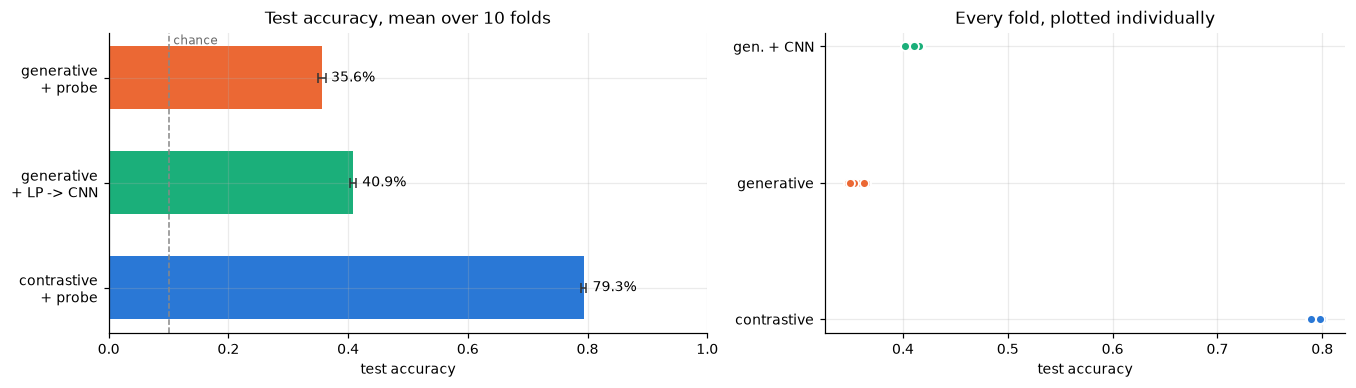

In [50]:
figure, axes = plt.subplots(1, 2, figsize=(12.4, 3.6),
                            gridspec_kw={"width_ratios": [1.15, 1]})

labels = ["contrastive\n+ probe", "generative\n+ LP -> CNN", "generative\n+ probe"]
means = [summarize(TEST_PROBE["contrastive"])["mean"], summarize(TEST_CNN)["mean"],
         summarize(TEST_PROBE["generative"])["mean"]]
errors = [summarize(TEST_PROBE["contrastive"])["std"], summarize(TEST_CNN)["std"],
          summarize(TEST_PROBE["generative"])["std"]]
colors = [COLOR_CONTRASTIVE, COLOR_CNN, COLOR_GENERATIVE]

axes[0].barh(labels, means, xerr=errors, color=colors, height=0.6,
             error_kw={"ecolor": "#333", "capsize": 3, "elinewidth": 1})
axes[0].axvline(1.0 / NUM_CLASSES, color="#888", linestyle="--", linewidth=1)
axes[0].annotate("chance", xy=(1.0 / NUM_CLASSES + 0.008, 2.32), fontsize=8, color="#666")
for position, value in enumerate(means):
    axes[0].text(value + 0.015, position, "%.1f%%" % (value * 100), va="center", fontsize=9)
axes[0].set_xlim(0, 1.0); axes[0].set_xlabel("test accuracy")
axes[0].set_title("Test accuracy, mean over 10 folds")

for name, rows, color in (("contrastive", TEST_PROBE["contrastive"], COLOR_CONTRASTIVE),
                          ("generative", TEST_PROBE["generative"], COLOR_GENERATIVE),
                          ("gen. + CNN", TEST_CNN, COLOR_CNN)):
    values = [row["accuracy"] for row in rows]
    axes[1].scatter(values, [name] * len(values), color=color, s=34, zorder=3,
                    edgecolor="white", linewidth=1.2)
axes[1].set_xlabel("test accuracy"); axes[1].set_title("Every fold, plotted individually")

figure.tight_layout(); figure.savefig(FIGURES_ROOT / "fig12_headline.png", bbox_inches="tight")
plt.show()

class       contrastive   generative     gen.+CNN      gap
------------------------------------------------------------
bird             0.7590       0.2349       0.3066    0.524
truck            0.8804       0.3827       0.3808    0.498
horse            0.7923       0.3374       0.4217    0.455
deer             0.7502       0.3028       0.3991    0.447
monkey           0.7063       0.2631       0.2863    0.443
ship             0.9538       0.5398       0.5590    0.414
cat              0.6277       0.2147       0.2006    0.413
car              0.9221       0.5129       0.5812    0.409
dog              0.6112       0.2080       0.2221    0.403
airplane         0.9296       0.5952       0.5943    0.334


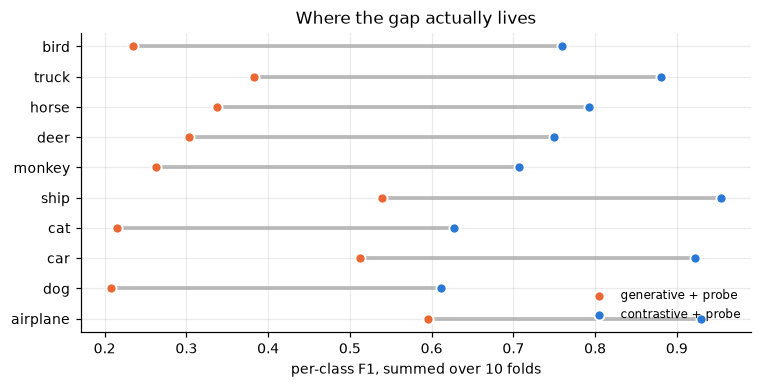

In [51]:
def summed_confusion(rows):
    return torch.as_tensor(np.sum([row["confusion"] for row in rows], axis=0))


contrastive_confusion = summed_confusion(TEST_PROBE["contrastive"])
generative_confusion = summed_confusion(TEST_PROBE["generative"])
cnn_confusion = summed_confusion(TEST_CNN)

_, _, contrastive_f1 = per_class_precision_recall_f1(contrastive_confusion)
_, _, generative_f1 = per_class_precision_recall_f1(generative_confusion)
_, _, cnn_f1 = per_class_precision_recall_f1(cnn_confusion)

order = np.argsort(-(contrastive_f1.numpy() - generative_f1.numpy()))

print("%-10s %12s %12s %12s %8s" % ("class", "contrastive", "generative", "gen.+CNN", "gap"))
print("-" * 60)
for class_id in order:
    print("%-10s %12.4f %12.4f %12.4f %8.3f"
          % (CLASS_NAMES[class_id], contrastive_f1[class_id], generative_f1[class_id],
             cnn_f1[class_id], contrastive_f1[class_id] - generative_f1[class_id]))

figure, axis = plt.subplots(figsize=(7.0, 3.6))
positions = np.arange(NUM_CLASSES)
for row, class_id in enumerate(order):
    axis.plot([generative_f1[class_id], contrastive_f1[class_id]], [row, row],
              color="#bbb", linewidth=2.5, zorder=1, solid_capstyle="round")
axis.scatter(generative_f1.numpy()[order], positions, color=COLOR_GENERATIVE, s=44,
             zorder=3, edgecolor="white", linewidth=1.2, label="generative + probe")
axis.scatter(contrastive_f1.numpy()[order], positions, color=COLOR_CONTRASTIVE, s=44,
             zorder=3, edgecolor="white", linewidth=1.2, label="contrastive + probe")
axis.set_yticks(positions); axis.set_yticklabels([CLASS_NAMES[c] for c in order])
axis.invert_yaxis(); axis.set_xlabel("per-class F1, summed over 10 folds")
axis.set_title("Where the gap actually lives")
axis.legend(frameon=False, fontsize=8, loc="lower right")
figure.tight_layout(); figure.savefig(FIGURES_ROOT / "fig13_per_class.png", bbox_inches="tight")
plt.show()

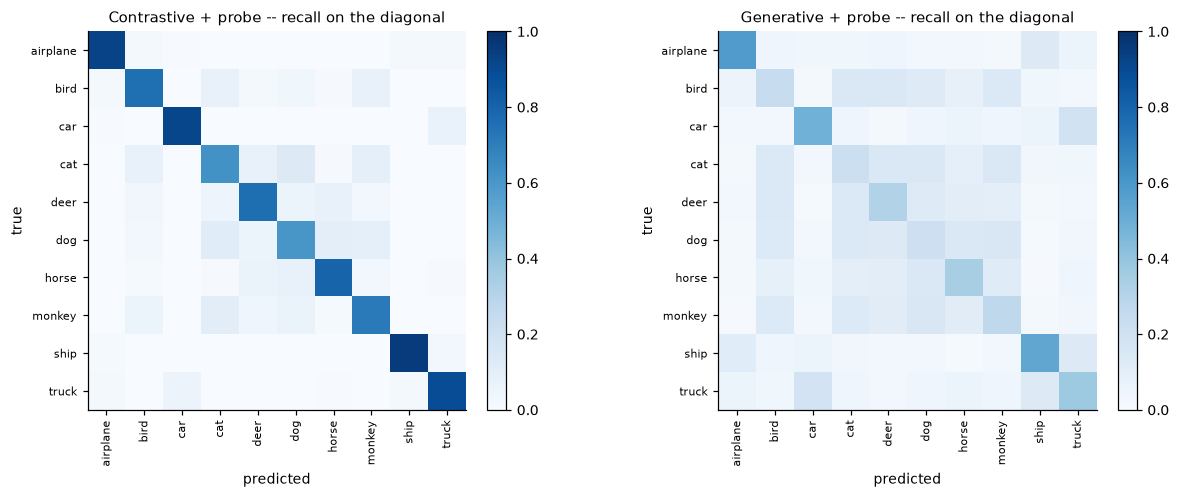

In [52]:
figure, axes = plt.subplots(1, 2, figsize=(11.6, 4.6))
for axis, confusion, title in (
    (axes[0], contrastive_confusion, "Contrastive + probe"),
    (axes[1], generative_confusion, "Generative + probe"),
):
    normalized = (confusion.double() / confusion.double().sum(dim=1, keepdim=True)).numpy()
    image = axis.imshow(normalized, cmap="Blues", vmin=0, vmax=1)
    axis.set_xticks(range(NUM_CLASSES)); axis.set_yticks(range(NUM_CLASSES))
    axis.set_xticklabels(CLASS_NAMES, rotation=90, fontsize=7.5)
    axis.set_yticklabels(CLASS_NAMES, fontsize=7.5)
    axis.set_xlabel("predicted"); axis.set_ylabel("true")
    axis.set_title("%s -- recall on the diagonal" % title, fontsize=10)
    axis.grid(False)
    figure.colorbar(image, ax=axis, fraction=0.046, pad=0.04)

figure.tight_layout(); figure.savefig(FIGURES_ROOT / "fig14_confusion.png", bbox_inches="tight")
plt.show()

In [53]:
def write_csv(path, header, rows):
    with open(path, "w", encoding="utf-8", newline="\n") as handle:
        handle.write(",".join(header) + "\n")
        for row in rows:
            handle.write(",".join(("%.8f" % v) if isinstance(v, float) else str(v)
                                  for v in row) + "\n")


TEST_ROOT = RESULTS_ROOT / "test_benchmark"
DEVELOPMENT_ROOT = RESULTS_ROOT / "development"
TEST_ROOT.mkdir(parents=True, exist_ok=True)
DEVELOPMENT_ROOT.mkdir(parents=True, exist_ok=True)

write_csv(TEST_ROOT / "fold_metrics.csv",
          ["arm", "fold", "accuracy", "f1_macro", "precision_macro", "log_loss"],
          [[name, fold_index, row["accuracy"], row["f1_macro"], row["precision_macro"],
            row["log_loss"]]
           for name, rows in (("contrastive_probe", TEST_PROBE["contrastive"]),
                              ("generative_probe", TEST_PROBE["generative"]),
                              ("generative_cnn", TEST_CNN))
           for fold_index, row in enumerate(rows)])

write_csv(TEST_ROOT / "per_class_metrics.csv",
          ["arm", "class_id", "class_name", "precision", "recall", "f1"],
          [[name, class_id, CLASS_NAMES[class_id], float(precision[class_id]),
            float(recall[class_id]), float(f1[class_id])]
           for name, confusion in (("contrastive_probe", contrastive_confusion),
                                   ("generative_probe", generative_confusion),
                                   ("generative_cnn", cnn_confusion))
           for precision, recall, f1 in [per_class_precision_recall_f1(confusion)]
           for class_id in range(NUM_CLASSES)])

write_csv(DEVELOPMENT_ROOT / "sweep_spread.csv",
          ["beta", "k", "alpha", "dev_accuracy_mean", "dev_accuracy_std", "edge_purity",
           "component_coverage", "unreachable_mean", "iterations_mean"],
          [[r["beta"], r["k"], r["alpha"], r["dev_accuracy_mean"], r["dev_accuracy_std"],
            r["edge_purity"], r["component_coverage"], r["unreachable_mean"],
            r["iterations_mean"]] for r in SPREAD_SWEEP])

write_csv(DEVELOPMENT_ROOT / "sweep_clamp.csv",
          ["beta", "k", "dev_accuracy_mean", "dev_accuracy_std", "edge_purity",
           "component_coverage", "iterations_mean"],
          [[r["beta"], r["k"], r["dev_accuracy_mean"], r["dev_accuracy_std"], r["edge_purity"],
            r["component_coverage"], r["iterations_mean"]] for r in CLAMP_SWEEP])

write_csv(DEVELOPMENT_ROOT / "policy_ablation.csv",
          ["policy", "dev_accuracy_mean", "dev_accuracy_std", "log_loss_mean", "c"],
          [[name, float(np.mean(r["accuracy"])), sample_std(r["accuracy"]),
            float(np.mean(r["log_loss"])), r["c"]] for name, r in POLICY_ABLATION.items()])

summary = {
    "seed": SEED,
    "selection": SELECTION,
    "selection_sha256": SELECTION_HASH,
    "test_images": NUM_TEST_IMAGES,
    "folds": NUM_FOLDS,
    "std_convention": "sample standard deviation, ddof = 1, over the folds",
    "rows": {
        "contrastive_probe": {k: summarize(TEST_PROBE["contrastive"], k)
                              for k in ("accuracy", "f1_macro", "precision_macro", "log_loss")},
        "generative_probe": {k: summarize(TEST_PROBE["generative"], k)
                             for k in ("accuracy", "f1_macro", "precision_macro", "log_loss")},
        "generative_cnn": {k: summarize(TEST_CNN, k)
                           for k in ("accuracy", "f1_macro", "precision_macro", "log_loss")},
    },
    "gap_like_for_like": GAP,
}
with open(TEST_ROOT / "summary.json", "w", encoding="utf-8") as handle:
    json.dump(summary, handle, indent=2, sort_keys=True)

print("written:")
for path in sorted(RESULTS_ROOT.rglob("*")):
    if path.is_file():
        print("  %-52s %7.1f KB" % (path.relative_to(PROJECT_ROOT), path.stat().st_size / 1024))

written:
  results/development/policy_ablation.csv                  0.3 KB
  results/development/policy_best_summary.csv              0.9 KB
  results/development/policy_configuration.csv             0.5 KB
  results/development/policy_delta_vs_p1.csv               1.3 KB
  results/development/policy_paired_fold_delta_vs_p1.csv     0.4 KB
  results/development/policy_per_class_delta_vs_p1.csv     7.5 KB
  results/development/policy_probe_trajectory.csv          2.1 KB
  results/development/sweep_clamp.csv                      3.4 KB
  results/development/sweep_spread.csv                    21.6 KB
  results/figures/fig01_labeled_examples.png             274.1 KB
  results/figures/fig02_unlabeled_examples.png           816.8 KB
  results/figures/fig03a_original.png                    238.8 KB
  results/figures/fig03b_vae_policy.png                  229.4 KB
  results/figures/fig03c_simclr_view1.png                142.1 KB
  results/figures/fig03d_simclr_view2.png                177.4 KB

<div dir="rtl" lang="he" style="text-align: right;">

## 13.1 האם ההשוואה הוגנת?

זהו החלק שקובע אם למספר המרכזי יש משמעות. רשימת הבדיקה נכתבה לפני ההרצה ולא אחריה.

| פריט | מצב | ראיה |
|---|---|---|
| גזע | **זהה מעצם המבנה** | שתי הזרועות יוצרות `SEResNetEncoder` מסעיף 2; אין subclass או wrapper |
| רוחב הייצוג | זהה | 512 בשני הצדדים, עם assertion בסעיף 2 |
| חלוקות | זהות | אותם אובייקטים `OFFICIAL_FOLDS` ו-`DEVELOPMENT_SPLITS`, הנבנים פעם אחת בסעיף 1 |
| נרמול | זהה | מילון `NORMALIZATION` יחיד, המחושב פעם אחת מחלוקת ה-unlabeled |
| Optimizer ולוח זמנים | זהים | `build_optimizer` יחיד ו-`learning_rate_at_step` יחיד |
| תקציב | זהה | 100 epochs, ‏batch 256, על אותן 100,000 תמונות |
| מסווג המשך | **זהה** | אותה `fit_logistic_regression`, ולא רק מוסכמה תואמת |
| רגולריזציה C | ערך גלובלי אחד לכל זרוע, עם עדיפות ל-log-loss | סעיף 11 |
| משמעת test | נקרא פעם אחת לאחר שהבחירה נחתמה ב-hash | סעיף 12 |
| Seed | ‏42 בשתי הזרועות | קבוע `SEED` יחיד |
| גורם קיבולת מערפל | שורות ה-probe מובילות; שורת ה-CNN מוצגת לצדן | סעיף 13 |

### הסטייה היחידה — נמדדת במקום להישאר טענה

שתי הזרועות לוקחות את הייצוג בנקודות מעט שונות בגזע. הזרוע הקונטרסטיבית משתמשת ישירות במאפיין בממד 512 לאחר pooling. הזרוע הגנרטיבית מעבירה את אותו וקטור דרך `to_mu`, שכבת `Linear(512, 512)`, ומשתמשת בפלט שלה.

הרוחב זהה אך השכבה שונה. Probe לינארי יכול לספוג העתקה לינארית, ולכן ההבדל כמעט אינו רלוונטי לשורות ה-probe. לעומת זאת, **דמיון קוסינוס אינו אינווריאנטי להעתקה לינארית**, ולכן הדבר כן משפיע על הגרף. התא הבא מודד את שתי האפשרויות.

</div>


In [54]:
def _tap_point_comparison(k=None, alpha=None):
    """Score the generative arm at both tap points: `mu` and the pooled feature before it."""
    k = SELECTED_K if k is None else k
    alpha = SELECTED_ALPHA if alpha is None else alpha

    pre_mu = cached(
        RUNS_ROOT / ("embeddings_vae_beta%g_premu.pt" % SELECTED_BETA),
        lambda: extract_embeddings(VAE_RUNS[SELECTED_BETA]["encoder_state"], head_state=None),
        "embeddings, generative arm at the contrastive tap point")

    results = {}
    for name, embeddings in (("mu (ours)", VAE_EMBEDDINGS[SELECTED_BETA]),
                             ("pooled, pre-mu", pre_mu)):
        probe_scores = [probe_development_accuracy(embeddings, f)["accuracy"]
                        for f in range(NUM_FOLDS)]

        propagation_matrix, _, _, _ = build_propagation_matrix(embeddings, k)
        propagation_matrix = propagation_matrix.to(DEVICE)
        lp_scores = []
        for fold_index in range(NUM_FOLDS):
            seed_nodes, seed_labels, validation_nodes, validation_labels = \
                fold_seed_indices(fold_index)
            initial_F = initial_label_matrix(NUM_GRAPH_NODES, NUM_CLASSES, seed_nodes,
                                             seed_labels, DEVICE)
            F_final, _, _ = spread(propagation_matrix, initial_F, seed_nodes,
                                   one_hot_matrix(seed_labels, NUM_CLASSES, DEVICE), alpha)
            index = torch.as_tensor(validation_nodes, dtype=torch.int64, device=DEVICE)
            predictions = F_final[index].argmax(dim=1).cpu().numpy()
            lp_scores.append(float((predictions == validation_labels).mean()))

        results[name] = {"probe": float(np.mean(probe_scores)),
                         "label_propagation": float(np.mean(lp_scores))}
        del propagation_matrix
    return results


TAP_COMPARISON = cached(RUNS_ROOT / "tap_point_comparison.pt", _tap_point_comparison,
                        "tap-point sensitivity")

print("%-18s %14s %22s" % ("tap point", "linear probe", "label spreading"))
print("-" * 56)
for name, scores in TAP_COMPARISON.items():
    print("%-18s %14.4f %22.4f" % (name, scores["probe"], scores["label_propagation"]))

probe_delta = (TAP_COMPARISON["mu (ours)"]["probe"]
               - TAP_COMPARISON["pooled, pre-mu"]["probe"])
lp_delta = (TAP_COMPARISON["mu (ours)"]["label_propagation"]
            - TAP_COMPARISON["pooled, pre-mu"]["label_propagation"])
print()
print("Tap point is worth %+.4f to the probe and %+.4f to label propagation."
      % (probe_delta, lp_delta))
print()
if lp_delta > 0:
    print("The deviation FAVOURS the generative arm: tapping the contrastive arm's exact")
    print("layer would make our propagation number worse and the gap wider. It is a real")
    print("asymmetry that runs the wrong way to explain the result.")
else:
    print("The deviation costs the generative arm, so it is reported as a caveat on that")
    print("arm's number rather than as a point in its favour.")

[cache hit ] tap-point sensitivity
tap point            linear probe        label spreading
--------------------------------------------------------
mu (ours)                  0.3415                 0.4085
pooled, pre-mu             0.3620                 0.3885

Tap point is worth -0.0205 to the probe and +0.0200 to label propagation.

The deviation FAVOURS the generative arm: tapping the contrastive arm's exact
layer would make our propagation number worse and the gap wider. It is a real
asymmetry that runs the wrong way to explain the result.


<div dir="rtl" lang="he" style="text-align: right;">

## 13.2 מה אומרים המספרים

יש לקרוא את שתי שורות ה-probe זו מול זו: אותו גזע, אותם folds, אותו מימוש מסווג, אותה מוסכמת רגולריזציה, אותו נרמול, אותו optimizer, אותו תקציב ואותו seed. **פונקציית המטרה בקדם-האימון היא המשתנה היחיד.**

### שלושה ממצאים שכדאי לומר בפשטות

**1. העברה בקיבוע קשיח נכשלת כאן מסיבה מבנית ולא מספרית.** עם 800 seeds בתוך 105,000 צמתים בגרף מחובר היטב, ההילוך מתערבב לפני הספיגה ונקודת הקבע כמעט אינה מכילה מידע על נקודת ההתחלה. סעיף 9.1 מודד בהתכנסות את החלק הממוצע של המחלקה הזוכה ביחס לרצפה האחידה. התיקון הוא איבר restart, ו-α שלו הוא hyperparameter אמיתי ולא פרט שולי.

**2. מגבלת איטרציות היא hyperparameter סמוי.** ה-accuracy מגיע לשיא מוקדם ואז דועך אל נקודת הקבע. לכן עצירה מוקדמת אינה רק קיצור החישוב; היא משנה איזה K נראה הטוב ביותר, משום ש-K קטן מפזר לאט יותר ונמצא מוקדם יותר בעקומת הדעיכה. כל K שנבחר תחת מגבלה תלוי חלקית במגבלה עצמה.

**3. הגרף תורם פחות מכפי שמורכבותו מרמזת.** סעיף 9.2 כולל baseline ללא גרף: הצבעת cosine פשוטה של 20 השכנים הקרובים ביותר מבין אותם 800 seeds. היתרון של label spreading מעל baseline זה הוא המדד הישיר למה שהגרף מוסיף.

### מגבלות

- **ה-CNN משנן את ה-pseudo-labels.** ההסכמה שלו איתם וה-cross-entropy באימון מודפסים בסעיף 12; יש להשוותם ל-cross-entropy על ה-test. ‏CNN המאומן על כ-105,000 תוויות רועשות אינו עולה על ההעברה שיצרה אותן, ולכן גורם הקיבולת המערפל פועל בכיוון ההפוך מהמצופה.
- **חלוקת ה-unlabeled רחבה מעשר המחלקות.** ההעברה מפזרת בהכרח מסה דרך צמתי out-of-distribution. התופעה מכומתת בסעיף 9 אך אינה מסוננת, משום שכל heuristic לדחייה היה מוסיף משתנה לא מבוקר בין הזרועות.
- **Seed יחיד.** כל `±` הוא הפיזור על פני עשרת ה-folds הרשמיים, שהוא השונות הרלוונטית לפרוטוקול, אך שונות קדם-האימון של אף זרוע אינה נמדדת.
- **האוגמנטציה שונה בין הזרועות** בכוונה, וזהו ההבדל המהותי היחיד שבחרנו לא לבטל. סעיף 3 מסביר מדוע כפיית זהות הייתה מעוותת את ההשוואה ולא מתקנת אותה.

</div>


<div dir="rtl" lang="he" style="text-align: right;">

---

# 14. אימות הרכיבים שמומשו מאפס

מימוש מאפס מוצדק רק אם הרכיבים נכונים. סעיף זה בודק כל רכיב שמומש ידנית מול נוסחה סגורה או מימוש ייחוס.

ספריות הייחוס מיובאות **כאן ולא בשום מקום אחר**. שום שלב קודם אינו תלוי בהן, והמחברת כולה יכולה להסתיים גם אם מדלגים על התאים האלה. לכן מדובר בבדיקה ולא בתלות של השיטה.

</div>


In [55]:
VERIFICATION = []


def check(name, passed, detail=""):
    VERIFICATION.append({"name": name, "passed": bool(passed), "detail": detail})
    print("  [%s] %-46s %s" % ("PASS" if passed else "FAIL", name, detail))


reset_seed()

small = torch.randn(400, 32)
full = l2_normalize(small, torch.device("cpu"))
similarity = full @ full.T
similarity.fill_diagonal_(float("-inf"))
reference_values, reference_indices = torch.topk(similarity, 10, dim=1)

for chunk in (1, 37, 128, 400):
    indices, values = build_knn_graph(small, 10, chunk_rows=chunk, device=torch.device("cpu"))
    check("chunked KNN indices match full topk (chunk=%d)" % chunk,
          torch.equal(indices, reference_indices))
    check("chunked KNN values match full topk (chunk=%d)" % chunk,
          torch.allclose(values, reference_values, atol=1e-6),
          "max delta %.2e" % (values - reference_values).abs().max().item())

indices, values = build_knn_graph(small, 10, device=torch.device("cpu"))
weights, _ = heat_kernel_weights(values)
P = row_normalize(symmetrize_union(indices, weights, 400))
row_sums = torch.sparse.sum(P, dim=1).to_dense()
check("P rows sum to 1", torch.allclose(row_sums, torch.ones(400), atol=1e-5),
      "max deviation %.2e" % (row_sums - 1).abs().max().item())

dense_P = symmetrize_union(indices, weights, 400).to_dense()
check("symmetrized W equals its own transpose",
      torch.allclose(dense_P, dense_P.T, atol=1e-7))

seed_positions = torch.arange(0, 400, 13)
small_labels = torch.randint(0, NUM_CLASSES, (seed_positions.numel(),))
Y = torch.zeros(400, NUM_CLASSES)
Y[seed_positions] = one_hot_matrix(small_labels, NUM_CLASSES, torch.device("cpu"))

for alpha in (0.5, 0.9, 0.99):
    iterated, iterations, _ = spread(P, Y, seed_positions, Y[seed_positions], alpha,
                                     max_iterations=20000, tolerance=1e-12)
    closed_form = (1 - alpha) * torch.linalg.solve(
        torch.eye(400) - alpha * P.to_dense(), Y)
    check("label spreading == closed form (alpha=%.2f)" % alpha,
          torch.allclose(iterated, closed_form, atol=1e-6),
          "max error %.2e in %d iterations"
          % ((iterated - closed_form).abs().max().item(), iterations))

cluster_a = torch.randn(50, 8) + 40.0
cluster_b = torch.randn(50, 8) - 40.0
disjoint_indices, _ = build_knn_graph(torch.cat([cluster_a, cluster_b]), 4,
                                      device=torch.device("cpu"))
component_ids, component_count = connected_components(disjoint_indices, 100)
check("union-find separates two far-apart clusters", component_count == 2,
      "found %d components" % component_count)

  [PASS] chunked KNN indices match full topk (chunk=1)  
  [PASS] chunked KNN values match full topk (chunk=1)   max delta 1.49e-07
  [PASS] chunked KNN indices match full topk (chunk=37) 
  [PASS] chunked KNN values match full topk (chunk=37)  max delta 1.19e-07
  [PASS] chunked KNN indices match full topk (chunk=128) 
  [PASS] chunked KNN values match full topk (chunk=128) max delta 1.79e-07
  [PASS] chunked KNN indices match full topk (chunk=400) 
  [PASS] chunked KNN values match full topk (chunk=400) max delta 0.00e+00
  [PASS] P rows sum to 1                                max deviation 1.19e-07
  [PASS] symmetrized W equals its own transpose         


/tmp/ipykernel_4090801/884564965.py:82: UserWarning: Sparse invariant checks are implicitly disabled. Memory errors (e.g. SEGFAULT) will occur when operating on a sparse tensor which violates the invariants, but checks incur performance overhead. To silence this warning, explicitly opt in or out. See `torch.sparse.check_sparse_tensor_invariants.__doc__` for guidance.  (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:760.)
  return torch.sparse_coo_tensor(torch.stack([rows, columns]), unique_weights,


  [PASS] label spreading == closed form (alpha=0.50)    max error 1.79e-07 in 20000 iterations


  [PASS] label spreading == closed form (alpha=0.90)    max error 4.47e-08 in 20000 iterations


  [PASS] label spreading == closed form (alpha=0.99)    max error 1.49e-08 in 20000 iterations
  [PASS] union-find separates two far-apart clusters    found 2 components


In [56]:
try:
    from sklearn.metrics import (accuracy_score, confusion_matrix as sk_confusion,
                                 f1_score, log_loss, precision_score)
    from sklearn.linear_model import LogisticRegression
    from sklearn.preprocessing import StandardScaler
    SKLEARN_AVAILABLE = True
except ImportError:
    SKLEARN_AVAILABLE = False
    print("scikit-learn is not installed; the reference comparisons below are skipped.")
    print("They are a check on our implementations, not a dependency of the pipeline.")

if SKLEARN_AVAILABLE:
    rng = np.random.default_rng(SEED)
    truth = rng.integers(0, NUM_CLASSES, 500)
    predicted = rng.integers(0, NUM_CLASSES, 500)
    logits = rng.normal(size=(500, NUM_CLASSES))
    probabilities = np.exp(logits) / np.exp(logits).sum(axis=1, keepdims=True)

    ours = confusion_matrix(truth, predicted).numpy()
    check("confusion matrix == sklearn", np.array_equal(ours, sk_confusion(truth, predicted)))
    check("accuracy == sklearn",
          abs(accuracy_from(confusion_matrix(truth, predicted)) - accuracy_score(truth, predicted)) < 1e-12)
    check("macro-F1 == sklearn",
          abs(macro_f1(confusion_matrix(truth, predicted))
              - f1_score(truth, predicted, average="macro", zero_division=0)) < 1e-12)
    check("macro precision == sklearn",
          abs(macro_precision(confusion_matrix(truth, predicted))
              - precision_score(truth, predicted, average="macro", zero_division=0)) < 1e-12)
    check("log loss == sklearn",
          abs(cross_entropy_loss(probabilities, truth)
              - log_loss(truth, probabilities, labels=list(range(NUM_CLASSES)))) < 1e-10)

    features = rng.normal(size=(300, 20))
    labels = rng.integers(0, NUM_CLASSES, 300)

    scaler = StandardScaler().fit(features)
    ours_scaled = Standardizer().fit(features).transform(features).numpy()
    check("Standardizer == StandardScaler",
          np.allclose(ours_scaled, scaler.transform(features), atol=1e-10),
          "max delta %.2e" % np.abs(ours_scaled - scaler.transform(features)).max())

    for c_value in (0.1, 1.0, 10.0):
        weights, bias = fit_logistic_regression(ours_scaled, labels, C=c_value)
        ours_predictions = predict_proba(ours_scaled, weights, bias).argmax(dim=1).numpy()
        reference = LogisticRegression(C=c_value, solver="lbfgs", max_iter=5000).fit(
            scaler.transform(features), labels)
        agreement = float((ours_predictions == reference.predict(scaler.transform(features))).mean())
        check("probe agrees with LogisticRegression (C=%g)" % c_value, agreement >= 0.98,
              "%.1f%% argmax agreement" % (agreement * 100))

  [PASS] confusion matrix == sklearn                    
  [PASS] accuracy == sklearn                            
  [PASS] macro-F1 == sklearn                            
  [PASS] macro precision == sklearn                     
  [PASS] log loss == sklearn                            
  [PASS] Standardizer == StandardScaler                 max delta 1.78e-15


  [PASS] probe agrees with LogisticRegression (C=0.1)   100.0% argmax agreement


  [PASS] probe agrees with LogisticRegression (C=1)     100.0% argmax agreement


  [PASS] probe agrees with LogisticRegression (C=10)    99.7% argmax agreement


In [57]:
try:
    import torchvision.transforms.v2.functional as TF
    TORCHVISION_AVAILABLE = True
except ImportError:
    TORCHVISION_AVAILABLE = False
    print("torchvision is not installed; the augmentation comparisons below are skipped.")

if TORCHVISION_AVAILABLE:
    reset_seed()
    sample = torch.rand(6, 3, 32, 32)

    check("rgb_to_grayscale == torchvision",
          torch.allclose(rgb_to_grayscale(sample), TF.rgb_to_grayscale(sample, 1), atol=2e-3),
          "max delta %.2e" % (rgb_to_grayscale(sample)
                              - TF.rgb_to_grayscale(sample, 1)).abs().max().item())

    for factor in (0.6, 1.0, 1.4):
        factors = torch.full((6,), factor)
        for name, ours, reference in (
            ("brightness", adjust_brightness(sample, factors), TF.adjust_brightness(sample, factor)),
            ("contrast", adjust_contrast(sample, factors), TF.adjust_contrast(sample, factor)),
            ("saturation", adjust_saturation(sample, factors), TF.adjust_saturation(sample, factor)),
        ):
            check("adjust_%s == torchvision (factor=%.1f)" % (name, factor),
                  torch.allclose(ours, reference, atol=3e-3),
                  "max delta %.2e" % (ours - reference).abs().max().item())

    for shift in (-0.25, 0.0, 0.1):
        ours = adjust_hue(sample, torch.full((6,), shift))
        reference = TF.adjust_hue(sample, shift)
        check("adjust_hue == torchvision (shift=%+.2f)" % shift,
              torch.allclose(ours, reference, atol=5e-3),
              "max delta %.2e" % (ours - reference).abs().max().item())

    hue, saturation, value = rgb_to_hsv(sample)
    check("RGB -> HSV -> RGB round trip is the identity",
          torch.allclose(hsv_to_rgb(hue, saturation, value), sample, atol=1e-5),
          "max delta %.2e" % (hsv_to_rgb(hue, saturation, value) - sample).abs().max().item())

print()
passed = sum(1 for row in VERIFICATION if row["passed"])
print("=" * 72)
print("%d of %d checks passed" % (passed, len(VERIFICATION)))
print("=" * 72)

failures = [row for row in VERIFICATION if not row["passed"]]
if failures:
    print()
    print("FAILED:")
    for row in failures:
        print("  -", row["name"], row["detail"])
    raise AssertionError("%d verification check(s) failed" % len(failures))

  [PASS] rgb_to_grayscale == torchvision                max delta 1.19e-07
  [PASS] adjust_brightness == torchvision (factor=0.6)  max delta 0.00e+00
  [PASS] adjust_contrast == torchvision (factor=0.6)    max delta 5.96e-08
  [PASS] adjust_saturation == torchvision (factor=0.6)  max delta 1.19e-07
  [PASS] adjust_brightness == torchvision (factor=1.0)  max delta 0.00e+00
  [PASS] adjust_contrast == torchvision (factor=1.0)    max delta 0.00e+00
  [PASS] adjust_saturation == torchvision (factor=1.0)  max delta 0.00e+00
  [PASS] adjust_brightness == torchvision (factor=1.4)  max delta 0.00e+00
  [PASS] adjust_contrast == torchvision (factor=1.4)    max delta 5.96e-08
  [PASS] adjust_saturation == torchvision (factor=1.4)  max delta 1.19e-07
  [PASS] adjust_hue == torchvision (shift=-0.25)        max delta 7.00e-07
  [PASS] adjust_hue == torchvision (shift=+0.00)        max delta 8.05e-07
  [PASS] adjust_hue == torchvision (shift=+0.10)        max delta 8.05e-07
  [PASS] RGB -> HSV -> RG

<div dir="rtl" lang="he" style="text-align: right;">

---

## שחזור והרצת המחברת

</div>

```bash
git clone https://github.com/Tomer232/stl10-ssl-comparison.git
cd stl10-ssl-comparison
bash scripts/setup.sh          # סביבה וירטואלית, PyTorch, הורדה וחילוץ של STL-10
jupyter nbconvert --to notebook --execute --inplace \
    stl10_semi_supervised_comparison.ipynb
```

<div dir="rtl" lang="he" style="text-align: right;">

הרצה קרה דורשת GPU עם CUDA ולפחות 16 GB, ונמשכת בערך יומיים. כל שלב כבד נשמר תחת `runs/`, ולכן הרצה שנקטעה מתחדשת במקום שבו נעצרה ולא מתחילה מחדש. `RUNBOOK.md` מסביר כיצד להריץ ללא השגחה במחשב מרוחק.

**מחברים.** תומר קרמזין — הזרוע הגנרטיבית, הגרף, העברת התוויות והמחברת הנוכחית; ליאור רזניק — הזרוע הקונטרסטיבית, שהמימוש המקורי שלה נשמר ללא שינוי ב-`reference/simclr_stl10_abilation_f.ipynb`.

</div>
